<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/NLP-2026/%D0%9B%D0%B5%D0%BA%D1%86%D0%B8%D1%8F_6_2_%D0%9C%D0%B0%D1%81%D1%88%D1%82%D0%B0%D0%B1%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_RAG_%D0%B1%D0%B5%D0%B7_%D1%84%D1%80%D0%B5%D0%B9%D0%BC%D0%B2%D0%BE%D1%80%D0%BA%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Лекция 6.2. Масштабирование RAG без фреймворков

## Тема 1. Введение: от игрушки к боевому инструменту

В прошлой лекции (6.1) мы собрали работающего агента, который умел отвечать на вопросы, используя семантический поиск по нескольким жёстко заданным чанкам. Он даже умел маршрутизировать запросы – решать, когда искать в документах, а когда отвечать из собственных знаний. Но наш агент был игрушечным: **все документы мы прописывали прямо в коде**, а поиск вели по списку из 4–5 строк. В реальных проектах база знаний – это сотни файлов: отчёты, статьи, инструкции, письма, базы данных. И нам нужно научиться работать с ними по‑настоящему.

**Цель этой лекции** – превратить нашего агента в систему, готовую к реальной эксплуатации. Мы шаг за шагом решим следующие задачи:

- **Загрузка документов** – научимся читать папку с файлами разных форматов (TXT, PDF, DOCX, MD), извлекать текст и сохранять метаданные.
- **Умное разбиение на чанки** – вместо примитивного сплита по строкам реализуем рекурсивное разбиение с учётом структуры и ограничения по длине.
- **Векторное хранилище** – подключим **Chroma** (локальную векторную БД), чтобы хранить тысячи чанков и мгновенно находить нужные.
- **Маршрутизация через LLM** – заменим примитивную проверку ключевых слов на интеллектуальное решение самой модели, нужно ли искать.
- **Память и логирование** – добавим историю диалога и подробный лог каждого шага агента.

И всё это – по‑прежнему **локально, без облачных API, на чистом Python и с минимальными затратами** (лишь пара новых библиотек). Мы останемся в рамках одной машины и продолжим использовать Ollama с Qwen 2.5 3B. Каждый этап будет сопровождаться кодом, который вы можете запустить у себя.

Сегодня мы создадим **первый скрипт** – универсальный загрузчик документов, который станет фундаментом всей нашей системы.

---

## Тема 1. Загрузка документов из папки (скрипт `document_loader.py`)

Прежде чем наш агент сможет искать, ему нужны **документы**. Мы не будем хардкодить их – мы создадим папку `documents/`, положим туда файлы, а программа сама их обойдёт, прочитает и соберёт тексты в единую структуру.

### 1.0. Подготовка окружения – установка библиотек

Перед тем как писать код, убедитесь, что у вас установлены все необходимые пакеты. Для работы с PDF и DOCX нам понадобятся `pypdf` и `python-docx`.

#### Шаг 1: Создание и активация виртуального окружения (рекомендуется)

Виртуальное окружение изолирует зависимости вашего проекта от системных, что предотвращает конфликты версий.

```bash
# Создаём виртуальное окружение
python -m venv .venv

# Активируем (Windows)
.\.venv\Scripts\Activate.ps1

# Активируем (Linux/Mac)
source .venv/bin/activate
```

После активации в начале строки терминала появится `(.venv)`:

```
(.venv) PS D:\Science\AI_Agent_Demo>
```

#### Шаг 2: Установка библиотек

Выполните команду **без флага `--user`** (это важно!):

```bash
pip install pypdf python-docx
```

#### Шаг 3: Проверка установки

```bash
python -c "import pypdf, docx; print('✅ Готово')"
```

Если вы видите `✅ Готово` – всё правильно.

Вот как должен выглядеть успешный вывод:

```
(.venv) PS D:\Science\AI_Agent_Demo> pip install pypdf python-docx
Collecting pypdf
  Downloading pypdf-6.14.2-py3-none-any.whl (349 kB)
Collecting python-docx
  Downloading python_docx-1.2.0-py3-none-any.whl (252 kB)
Collecting lxml>=3.1.0 (from python-docx)
  Downloading lxml-6.1.1-cp313-cp313-win_amd64.whl (4.0 MB)
Collecting typing_extensions>=4.9.0 (from python-docx)
  Downloading typing_extensions-4.16.0-py3-none-any.whl (45 kB)
Successfully installed lxml-6.1.1 pypdf-6.14.2 python-docx-1.2.0 typing_extensions-4.16.0

(.venv) PS D:\Science\AI_Agent_Demo> python -c "import pypdf, docx; print('✅ Готово')"
✅ Готово
```

> **Важно:** Если вы видите сообщение `Defaulting to user installation because normal site-packages is not writeable` – значит, библиотеки устанавливаются в системную папку, а не в виртуальное окружение. Это происходит, если вы забыли активировать `.venv` или используете глобальный Python. Решение: активируйте виртуальное окружение и повторите установку.

### 1.1. Поддерживаемые форматы

Мы поддержим самые популярные форматы, с которыми вы можете столкнуться:

- `.txt` – обычные текстовые файлы (кодировка UTF‑8, но предусмотрим запасные варианты `cp1251`, `latin-1`).
- `.pdf` – PDF-документы (используем библиотеку `pypdf`).
- `.docx` – документы Microsoft Word (библиотека `python-docx`).
- `.md` – Markdown-файлы (читаем как обычный текст, они и так в UTF‑8).

Также мы будем пропускать бинарные и системные файлы (например, `~$`), а если не удаётся распарсить – будем записывать предупреждение и продолжать.

### 1.2. Структура папки с примерами

Для тестирования создадим внутри проекта папку `documents/` со следующей структурой:

```
documents/
├── about/
│   └── history.md
├── manuals/
│   └── user_guide.pdf
├── reports/
│   └── q1_report.docx
└── readme.txt
```

### 1.3. Содержимое тестовых файлов

Чтобы не искать реальные документы, я привожу готовые тексты. **Скопируйте их** и сохраните в соответствующие файлы.

#### Создание файлов

**Для TXT и MD:** просто создайте файлы в Блокноте или любом редакторе, скопируйте текст, сохраните с нужным расширением в кодировке UTF‑8.

**Для PDF:** скопируйте текст в Word или Google Docs, затем сохраните как PDF (Файл → Сохранить как → PDF).

**Для DOCX:** скопируйте текст в Word или Google Docs, сохраните как документ Word (`.docx`).

#### Файл `readme.txt`
```
Добро пожаловать в систему RAG!
Эта папка содержит примеры документов для тестирования семантического поиска.

Здесь вы найдёте:
- руководство пользователя (user_guide.pdf) с описанием продукта ProjectFlow,
- финансовый отчёт за первый квартал (q1_report.docx),
- историю компании (history.md).

Все файлы используются для демонстрации работы агента.
```

#### Файл `about/history.md`
```
# История компании "Техно-Инновации"

Компания основана в 2015 году группой энтузиастов в области разработки ПО.
Первым продуктом стала система управления задачами TaskFlow, которая позже эволюционировала в ProjectFlow.

В 2018 году компания привлекла первый раунд инвестиций в размере 2 млн долларов.
В 2020 году выпущена облачная версия ProjectFlow.
В 2022 году открыт офис в Европе.

Сегодня "Техно-Инновации" — лидер на рынке корпоративных решений для управления проектами в России и странах СНГ.
```

#### Файл `manuals/user_guide.pdf`

Создайте PDF-документ с этим текстом (2 страницы):

```
[Страница 1]
Руководство пользователя
Система управления проектами "ProjectFlow"
Версия 2.4

1. Введение
ProjectFlow — это облачная платформа для управления задачами и командной работой.
Основные возможности:
- Создание проектов и подзадач.
- Назначение исполнителей и сроков.
- Отслеживание прогресса через диаграммы Ганта.
- Интеграция с календарями (Google Calendar, Outlook).
- Поддержка файлового хранилища (до 50 ГБ на проект).

2. Начало работы
После регистрации вы попадаете на дашборд.
- Чтобы создать проект, нажмите кнопку "+ Новый проект".
- Введите название, описание и выберите тип (личный или командный).
- Добавьте участников по email.

3. Управление задачами
Каждая задача имеет статусы: "К выполнению", "В работе", "На проверке", "Завершено".
Вы можете установить приоритет (низкий, средний, высокий) и прикрепить файлы.
Для массовых операций используйте фильтры и группировку.

4. Отчёты и аналитика
Система автоматически строит отчёты по загрузке команды, срокам и бюджету.
Доступны экспорт в PDF и Excel.

5. Технические требования
ProjectFlow работает в любом современном браузере (Chrome, Firefox, Safari, Edge).
Для мобильных устройств доступны приложения для iOS и Android.

[Страница 2]
6. Часто задаваемые вопросы (FAQ)

Вопрос: Как восстановить удалённый проект?
Ответ: Удалённые проекты хранятся в корзине 30 дней. Администратор может восстановить их.

Вопрос: Можно ли подключить свой домен?
Ответ: Да, в настройках организации вы можете указать свой домен и настроить SSL-сертификат.

Вопрос: Какая модель лицензирования?
Ответ: ProjectFlow предлагает три тарифа: Starter (бесплатно, до 5 пользователей), Pro (9.99$/мес, неограниченно пользователей), Enterprise (индивидуально).

7. Поддержка
Если у вас возникли вопросы, напишите в поддержку support@projectflow.com или воспользуйтесь онлайн-чатом на сайте.
```

#### Файл `reports/q1_report.docx`

Создайте DOCX-документ с этим текстом:

```
Отчёт о финансовых результатах
ООО "Техно-Инновации"
Период: январь – март 2026

1. Общие показатели
Выручка за Q1: 12 450 000 руб.
Валовая прибыль: 4 200 000 руб.
Чистая прибыль: 2 100 000 руб.
Рентабельность: 16,9%

2. Структура доходов
- Продажа лицензий ProjectFlow: 7 200 000 руб. (58%)
- Консалтинговые услуги: 3 800 000 руб. (30%)
- Подписка на облачные сервисы: 1 450 000 руб. (12%)

3. Расходы
- ФОТ (оплата труда): 3 800 000 руб.
- Аренда офиса и коммунальные услуги: 500 000 руб.
- Маркетинг и реклама: 650 000 руб.
- Обслуживание серверов: 300 000 руб.
- Прочие расходы: 200 000 руб.

4. Ключевые события квартала
- В январе выпущено обновление ProjectFlow 2.4 с улучшенной аналитикой.
- В феврале подписан контракт с корпоративным клиентом "РосТех" на 2,5 млн руб.
- В марте стартовала рекламная кампания в социальных сетях, привлёкшая 120 новых клиентов.

5. Прогноз на Q2
Ожидаемый рост выручки на 15% за счёт выхода на международный рынок.
Запланирован запуск новой модульной системы для управления строительными проектами.

6. Риски
- Увеличение конкуренции со стороны аналогичных платформ.
- Возможные сбои в работе облачных серверов из-за роста нагрузки.

Подготовил: финансовый директор И.И. Иванов
Дата: 05.04.2026
```

### 1.4. Извлечение текста: отдельные функции

Теперь напишем код, который умеет читать каждый из этих форматов. Обратите внимание на обработку ошибок – если файл повреждён или имеет неверную кодировку, мы не дадим программе упасть, а просто выведем предупреждение и пропустим файл.

Вот полный код скрипта `document_loader.py`. Сохраните его в корне вашего проекта.

```python
import os
import pathlib
from datetime import datetime

# Попытка импортировать библиотеки с обработкой ошибок
try:
    from pypdf import PdfReader
except ImportError:
    print("❌ Библиотека pypdf не установлена.")
    print("   Выполните в активированном виртуальном окружении:")
    print("   pip install pypdf")
    exit(1)

try:
    from docx import Document
except ImportError:
    print("❌ Библиотека python-docx не установлена.")
    print("   Выполните в активированном виртуальном окружении:")
    print("   pip install python-docx")
    exit(1)

# ---------- Функции извлечения ----------

def extract_text_from_txt(file_path):
    """
    Извлекает текст из .txt файла с попыткой нескольких кодировок.
    Перебирает UTF-8, CP1251 и Latin-1.
    """
    encodings = ["utf-8", "cp1251", "latin-1"]
    for enc in encodings:
        try:
            with open(file_path, "r", encoding=enc) as f:
                return f.read()
        except UnicodeDecodeError:
            continue
    print(f"⚠️ Не удалось прочитать {file_path} ни в одной из кодировок")
    return ""

def extract_text_from_pdf(file_path):
    """
    Извлекает текст из PDF, возвращает строку с пометками страниц.
    Если PDF сканированный (без текстового слоя), вернёт пустую строку.
    """
    try:
        reader = PdfReader(file_path)
        text_parts = []
        for page_num, page in enumerate(reader.pages, start=1):
            page_text = page.extract_text()
            if page_text:
                text_parts.append(f"[Страница {page_num}]\n{page_text}")
        return "\n\n".join(text_parts)
    except Exception as e:
        print(f"⚠️ Ошибка при чтении PDF {file_path}: {e}")
        return ""

def extract_text_from_docx(file_path):
    """
    Извлекает текст из .docx, объединяя все абзацы.
    Таблицы и изображения игнорируются (извлекается только текст).
    """
    try:
        doc = Document(file_path)
        paragraphs = [p.text for p in doc.paragraphs if p.text.strip()]
        return "\n\n".join(paragraphs)
    except Exception as e:
        print(f"⚠️ Ошибка при чтении DOCX {file_path}: {e}")
        return ""

def extract_text_from_md(file_path):
    """Читает .md файл как обычный текст (разметка сохраняется)."""
    return extract_text_from_txt(file_path)

# Словарь для выбора функции по расширению
EXTRACTORS = {
    ".txt": extract_text_from_txt,
    ".md": extract_text_from_md,
    ".pdf": extract_text_from_pdf,
    ".docx": extract_text_from_docx,
}

# ---------- Основная функция загрузки ----------

def load_documents_from_folder(folder_path="documents"):
    """
    Обходит папку, читает все поддерживаемые файлы и возвращает список словарей.
    Каждый словарь содержит:
    - "text": полный текст документа
    - "metadata": словарь с метаданными (имя, путь, дата, расширение, страницы для PDF)
    """
    documents = []
    
    # Проверяем, существует ли папка
    if not os.path.exists(folder_path):
        print(f"❌ Папка '{folder_path}' не найдена!")
        print(f"   Создайте её и поместите туда документы.")
        return documents
    
    for file_path in pathlib.Path(folder_path).rglob("*"):
        if not file_path.is_file():
            continue

        ext = file_path.suffix.lower()
        if ext not in EXTRACTORS:
            # Пропускаем неподдерживаемые файлы
            continue

        extractor = EXTRACTORS[ext]
        text = extractor(str(file_path))
        if not text.strip():
            print(f"⚠️ {file_path} не содержит текста (или не удалось извлечь)")
            continue

        # Формируем метаданные
        metadata = {
            "file_name": file_path.name,
            "file_path": str(file_path.relative_to(folder_path)) if folder_path else str(file_path),
            "modification_time": datetime.fromtimestamp(os.path.getmtime(file_path)).isoformat(),
            "file_extension": ext,
        }

        # Для PDF добавим количество страниц
        if ext == ".pdf":
            try:
                reader = PdfReader(str(file_path))
                metadata["num_pages"] = len(reader.pages)
            except:
                pass

        documents.append({
            "text": text,
            "metadata": metadata
        })

        print(f"✅ Загружен: {file_path.name} ({len(text)} символов)")

    return documents

# ---------- Точка входа для тестирования ----------

if __name__ == "__main__":
    print("🚀 Загрузка документов из папки 'documents/'...\n")
    docs = load_documents_from_folder("documents")
    print(f"\n📊 Загружено документов: {len(docs)}")
    
    if not docs:
        print("⚠️ Нет загруженных документов. Проверьте:")
        print("   1. Существует ли папка 'documents'")
        print("   2. Есть ли в ней файлы с поддерживаемыми расширениями")
        print("   3. Содержат ли файлы текст (не пустые)")
    else:
        for d in docs[:3]:  # покажем первые три
            print(f"\n📄 {d['metadata']['file_name']}")
            print(f"   Путь: {d['metadata']['file_path']}")
            print(f"   Дата: {d['metadata']['modification_time']}")
            if "num_pages" in d['metadata']:
                print(f"   Страниц: {d['metadata']['num_pages']}")
            preview = d['text'][:200].replace('\n', ' ')
            print(f"   Текст (первые 200 символов):\n   {preview}...")
```

### 1.5. Запуск и проверка

После того как вы создали все файлы и сохранили скрипт, убедитесь, что виртуальное окружение активировано (в строке терминала видно `(.venv)`), и выполните:

```bash
python document_loader.py
```

Если всё сделано правильно, вы увидите примерно такой вывод (временные метки и размеры будут отличаться):

```
(.venv) PS D:\Science\AI_Agent_Demo> python document_loader.py                        "
🚀 Загрузка документов из папки 'documents/'...

✅ Загружен: readme.txt (351 символов)
✅ Загружен: history.md (500 символов)
✅ Загружен: user_guide.pdf (1907 символов)
✅ Загружен: q1_report.docx (1257 символов)

📊 Загружено документов: 4

📄 readme.txt
   Путь: readme.txt
   Дата: 2026-08-06T12:38:56.028779
   Текст (первые 200 символов):
   Добро пожаловать в систему RAG!  Эта папка содержит примеры документов для тестирования семантического поиска.  Здесь вы найдёте: - руководство пользователя (user_guide.pdf) с описанием продукта Proje...

📄 history.md
   Путь: about\history.md
   Дата: 2026-08-06T12:39:06.967163
   Текст (первые 200 символов):
   # История компании "Техно-Инновации"  Компания основана в 2015 году группой энтузиастов в области разработки ПО. Первым продуктом стала система управления задачами TaskFlow, которая позже эволюциониро...

📄 user_guide.pdf
   Путь: manuals\user_guide.pdf
   Дата: 2026-08-06T12:22:45.179543
   Страниц: 2
   Текст (первые 200 символов):
   [Страница 1] Руководство пользователя  Система управления проектами "ProjectFlow"  Версия 2.4    1. Введение  ProjectFlow — это облачная платформа для управления задачами и командной  работой.   Основ...
(.venv) PS D:\Science\AI_Agent_Demo>
```

### 1.6. Типичные ошибки и их решение

В процессе работы могут возникнуть следующие проблемы:

| Ошибка | Причина | Решение |
|--------|---------|---------|
| `ModuleNotFoundError: No module named 'pypdf'` | Библиотека не установлена или установлена не в виртуальное окружение | Активируйте `.venv` и выполните `pip install pypdf python-docx` |
| `Defaulting to user installation because normal site-packages is not writeable` | Вы не активировали виртуальное окружение | Активируйте `.venv` и повторите установку |
| `❌ Папка 'documents' не найдена` | Вы не создали папку с документами | Создайте папку `documents` в корне проекта |
| `⚠️ user_guide.pdf не содержит текста` | PDF без текстового слоя (скан) | Используйте OCR-инструменты, это выходит за рамки лекции |
| `⚠️ Не удалось прочитать file.txt` | Неверная кодировка | Мы уже перебрали 3 кодировки. Если не помогло – файл бинарный или повреждён |
| `⚠️ Ошибка при чтении DOCX` | Файл повреждён или создан в старой версии Word | Попробуйте открыть и сохранить заново через Word/Google Docs |

---

## Краткий итог Тема 1

- Мы создали скрипт `document_loader.py`, который умеет загружать файлы четырёх форматов: TXT, PDF, DOCX, MD.
- Реализована рекурсивная обработка папок – поддерживается вложенная структура.
- Для каждого документа мы сохраняем не только текст, но и метаданные: имя, путь, дату изменения, а для PDF – количество страниц.
- Все ошибки парсинга обрабатываются, программа не падает, а выдаёт предупреждения и продолжает работу.
- Предоставлены готовые тексты для тестовых файлов – вы можете сразу создать их и убедиться, что загрузчик работает.
- **Важное замечание:** библиотеки должны быть установлены **в виртуальное окружение**, а не глобально.

Теперь у нас есть сырые данные – список словарей с полным текстом каждого документа. Это идеальный вход для следующего этапа: **разбиения на чанки**. Ведь в реальности документы могут быть гигантскими (сотни страниц), и мы не можем отправить весь текст модели сразу – нужно нарезать его на куски, сохраняя смысловую связность. Этим мы и займёмся в следующей теме.




## Тема 2. Умное разбиение на чанки (скрипт `chunker.py`)

Отлично! Мы научились загружать документы из папки и получили список словарей с полными текстами. Теперь перед нами стоит следующая задача: **как разрезать эти длинные тексты на небольшие осмысленные фрагменты**?

В Лекции 6.1 мы использовали примитивное разбиение по строкам — это работало для демонстрации, но совершенно непригодно для реальных документов. Представьте, что вы загрузили руководство пользователя на 200 страниц. Если отправить весь текст модели, она просто не сможет его обработать — контекстное окно Qwen 2.5 3B составляет 8192 токена, а это всего около 6000 символов кириллицы. Кроме того, при поиске нам нужно находить **релевантные фрагменты**, а не весь документ целиком.

В этой теме мы создадим **интеллектуальный сплиттер**, который будет нарезать текст на чанки, сохраняя их смысловую целостность. Это критически важный этап, от которого зависит качество всего RAG-пайплайна.

---

### 2.1. Понятие чанка и ключевые параметры

**Чанк** — это небольшой фрагмент текста, который:
- Помещается в контекстное окно модели (обычно 500–1500 символов).
- Содержит законченную мысль или смысловой блок.
- Может быть самостоятельно понят без окружающего контекста.

Для управления разбиением мы вводим два ключевых параметра:

#### `chunk_size` (размер чанка)
Максимальная длина чанка в символах. Для кириллицы я рекомендую:
- **500 символов** — безопасный минимум, хорошо работает с эмбеддингами.
- **1000 символов** — стандарт для большинства RAG-систем.
- **1500 символов** — максимум, если у вас короткое контекстное окно.

Выбор зависит от ваших документов: техническая документация с длинными предложениями требует большего размера, а новостные заметки можно резать мельче.

#### `chunk_overlap` (перекрытие)
Количество символов, которые перекрываются между соседними чанками. Зачем это нужно? Представьте, что важная информация оказалась ровно на стыке двух чанков. Без перекрытия мы можем потерять её целиком. С перекрытием (обычно 10–20% от `chunk_size`) мы страхуемся от таких ситуаций.

**Пример:** При `chunk_size=500` и `chunk_overlap=50`:
- Чанк 1: символы 0–500
- Чанк 2: символы 450–950
- Чанк 3: символы 900–1400

Таким образом, важная фраза на позиции 480 попадёт и в первый, и во второй чанк.

---

### 2.2. Рекурсивный сплиттер: алгоритм и реализация

Простое разбиение по фиксированному числу символов часто режет слова и предложения, разрушая смысл. Поэтому мы реализуем **рекурсивный сплиттер**, который пытается разбить текст по естественным границам в порядке приоритета:

1. **Абзацы** (`\n\n`) — самый крупный смысловой блок.
2. **Предложения** (`. `, `! `, `? `) — средний уровень.
3. **Слова** (пробелы) — крайний случай, когда даже предложение слишком длинное.

Алгоритм работает так:

```
function recursive_split(text, chunk_size, chunk_overlap):
    1. Если длина текста <= chunk_size → возвращаем [текст]
    2. Перебираем разделители в порядке приоритета
    3. Для каждого разделителя пытаемся разбить текст
    4. Собираем чанки с учётом ограничения по длине
    5. Если какой-то чанк всё ещё слишком длинный → рекурсивно обрабатываем его со следующим разделителем
    6. Если ничего не помогло → режем принудительно по символам
```

Теперь реализуем это в коде. Создадим файл `chunker.py`:

```python
import re
from typing import List, Dict, Any

def recursive_split(
    text: str,
    chunk_size: int = 500,
    chunk_overlap: int = 50,
    separators: List[str] = None
) -> List[str]:
    """
    Рекурсивно разбивает текст на чанки с учётом естественных границ.
    
    Аргументы:
        text: исходный текст
        chunk_size: максимальный размер чанка в символах
        chunk_overlap: перекрытие между чанками в символах
        separators: список разделителей в порядке приоритета
    
    Возвращает:
        Список строк-чанков
    """
    # Если текст уже помещается в чанк
    if len(text) <= chunk_size:
        return [text]
    
    # Разделители по умолчанию (от крупных к мелким)
    if separators is None:
        separators = ["\n\n", "\n", ". ", "! ", "? ", " ", ""]
    
    # Перебираем разделители
    for sep in separators:
        if sep in text:
            # Разбиваем по текущему разделителю
            parts = text.split(sep)
            
            # Собираем чанки, объединяя части
            chunks = []
            current_chunk = ""
            
            for part in parts:
                # Проверяем, поместится ли часть с разделителем
                test_chunk = current_chunk + sep + part if current_chunk else part
                
                if len(test_chunk) <= chunk_size:
                    # Добавляем к текущему чанку
                    if current_chunk:
                        current_chunk += sep + part
                    else:
                        current_chunk = part
                else:
                    # Текущий чанк заполнен — сохраняем его
                    if current_chunk:
                        chunks.append(current_chunk)
                    
                    # Начинаем новый чанк с учётом перекрытия
                    if chunk_overlap > 0 and len(current_chunk) > chunk_overlap:
                        # Берём последние chunk_overlap символов из предыдущего чанка
                        overlap_text = current_chunk[-chunk_overlap:]
                        current_chunk = overlap_text + sep + part
                    else:
                        current_chunk = part
            
            # Добавляем последний чанк
            if current_chunk:
                chunks.append(current_chunk)
            
            # Проверяем, все ли чанки помещаются в лимит
            if all(len(chunk) <= chunk_size for chunk in chunks):
                return chunks
            
            # Если есть слишком длинные чанки — обрабатываем их рекурсивно
            final_chunks = []
            for chunk in chunks:
                if len(chunk) > chunk_size:
                    # Рекурсивно разбиваем, используя следующий разделитель
                    next_separators = separators[separators.index(sep) + 1:]
                    final_chunks.extend(
                        recursive_split(chunk, chunk_size, chunk_overlap, next_separators)
                    )
                else:
                    final_chunks.append(chunk)
            
            return final_chunks
    
    # Если ничего не помогло — принудительно режем по символам
    chunks = []
    for i in range(0, len(text), chunk_size - chunk_overlap):
        chunk = text[i:i + chunk_size]
        if chunk:
            chunks.append(chunk)
    
    return chunks


def normalize_text(text: str) -> str:
    """
    Нормализует текст: удаляет лишние пробелы, переносы строк, непечатные символы.
    """
    # Заменяем множественные пробелы и переносы на одиночные
    text = re.sub(r'\s+', ' ', text)
    # Удаляем пробелы в начале и конце
    text = text.strip()
    return text


def chunk_documents(
    documents: List[Dict[str, Any]],
    chunk_size: int = 500,
    chunk_overlap: int = 50
) -> List[Dict[str, Any]]:
    """
    Разбивает список документов на чанки с сохранением метаданных.
    
    Аргументы:
        documents: список словарей с полями "text" и "metadata"
        chunk_size: максимальный размер чанка
        chunk_overlap: перекрытие между чанками
    
    Возвращает:
        Список словарей с полями "text" и "metadata"
    """
    all_chunks = []
    
    for doc in documents:
        text = doc["text"]
        metadata = doc["metadata"]
        
        # Разбиваем на чанки
        raw_chunks = recursive_split(text, chunk_size, chunk_overlap)
        
        # Нормализуем каждый чанк
        chunks = [normalize_text(chunk) for chunk in raw_chunks if chunk.strip()]
        
        # Сохраняем метаданные для каждого чанка
        for i, chunk_text in enumerate(chunks):
            chunk_metadata = metadata.copy()
            chunk_metadata["chunk_index"] = i
            chunk_metadata["chunk_total"] = len(chunks)
            chunk_metadata["chunk_size"] = len(chunk_text)
            
            all_chunks.append({
                "text": chunk_text,
                "metadata": chunk_metadata
            })
    
    return all_chunks


# ---------- Точка входа для тестирования ----------

if __name__ == "__main__":
    # Тестовый текст (имитация документа)
    test_text = """
    Искусственный интеллект (ИИ) — это область компьютерных наук, занимающаяся созданием систем, способных выполнять задачи, обычно требующие человеческого интеллекта.
    
    Машинное обучение является подмножеством ИИ. Оно использует алгоритмы, которые позволяют компьютерам обучаться на данных и делать прогнозы или решения без явного программирования.
    
    Глубокое обучение — это ещё более узкая подкатегория машинного обучения, основанная на искусственных нейронных сетях с множеством слоёв. Эти сети способны автоматически извлекать признаки из данных.
    
    RAG (Retrieval-Augmented Generation) — это техника, которая комбинирует поиск информации и генерацию текста. Сначала система находит релевантные документы, а затем использует их для формирования ответа.
    
    Векторные базы данных, такие как Chroma, позволяют эффективно хранить и искать эмбеддинги текстов. Они используют индексы для приближённого поиска ближайших соседей.
    
    Это позволяет RAG-системам работать с миллионами документов с минимальной задержкой.
    """
    
    print("=" * 60)
    print("ДЕМОНСТРАЦИЯ РАБОТЫ РЕКУРСИВНОГО СПЛИТТЕРА")
    print("=" * 60)
    
    # Демонстрация с разными параметрами
    for chunk_size, overlap in [(200, 20), (300, 30), (500, 50)]:
        print(f"\n📌 Параметры: chunk_size={chunk_size}, overlap={overlap}")
        print("-" * 60)
        
        chunks = recursive_split(test_text, chunk_size, overlap)
        chunks = [normalize_text(ch) for ch in chunks if ch.strip()]
        
        for i, chunk in enumerate(chunks):
            print(f"\nЧанк {i+1} (длина: {len(chunk)} символов):")
            print(chunk)
            print("---")
```

### 2.3. Демонстрация работы на примере

Давайте запустим наш скрипт и посмотрим, как он работает:

```bash
python chunker.py
```

Вывод будет выглядеть примерно так:

```
(.venv) PS D:\Science\AI_Agent_Demo> python chunker.py        
============================================================
ДЕМОНСТРАЦИЯ РАБОТЫ РЕКУРСИВНОГО СПЛИТТЕРА
============================================================

📌 Параметры: chunk_size=200, overlap=20
------------------------------------------------------------

Чанк 1 (длина: 163 символов):
Искусственный интеллект (ИИ) — это область компьютерных наук, занимающаяся созданием систем, способных выполнять задачи, обычно требующие человеческого интеллекта.
---

Чанк 2 (длина: 59 символов):
ого интеллекта. Машинное обучение является подмножеством ИИ
---

Чанк 3 (длина: 156 символов):
тся подмножеством ИИ. Оно использует алгоритмы, которые позволяют компьютерам обучаться на данных и делать прогнозы или решения без явного программирования.
---

Чанк 4 (длина: 20 символов):
го программирования.
---

Чанк 5 (длина: 151 символов):
ограммирования. Глубокое обучение — это ещё более узкая подкатегория машинного обучения, основанная на искусственных нейронных сетях с множеством слоёв
---

Чанк 6 (длина: 83 символов):
х с множеством слоёв. Эти сети способны автоматически извлекать признаки из данных.
---

Чанк 7 (длина: 19 символов):
признаки из данных.
---

Чанк 8 (длина: 123 символов):
наки из данных. RAG (Retrieval-Augmented Generation) — это техника, которая комбинирует поиск информации и генерацию текста
---

Чанк 9 (длина: 115 символов):
и и генерацию текста. Сначала система находит релевантные документы, а затем использует их для формирования ответа.
---

Чанк 10 (длина: 186 символов):
формирования ответа. Векторные базы данных, такие как Chroma, позволяют эффективно хранить и искать эмбеддинги текстов. Они используют индексы для приближённого поиска ближайших соседей.
---

Чанк 11 (длина: 100 символов):
жайших соседей. Это позволяет RAG-системам работать с миллионами документов с минимальной задержкой.
---

📌 Параметры: chunk_size=300, overlap=30
------------------------------------------------------------

Чанк 1 (длина: 163 символов):
Искусственный интеллект (ИИ) — это область компьютерных наук, занимающаяся созданием систем, способных выполнять задачи, обычно требующие человеческого интеллекта.
---

Чанк 2 (длина: 205 символов):
человеческого интеллекта. Машинное обучение является подмножеством ИИ. Оно использует алгоритмы, которые позволяют компьютерам обучаться на данных и делать прогнозы или решения без явного программирования.
---

Чанк 3 (длина: 223 символов):
явного программирования. Глубокое обучение — это ещё более узкая подкатегория машинного обучения, основанная на искусственных нейронных сетях с множеством слоёв. Эти сети способны автоматически извлекать признаки из данных.
---

Чанк 4 (длина: 228 символов):
екать признаки из данных. RAG (Retrieval-Augmented Generation) — это техника, которая комбинирует поиск информации и генерацию текста. Сначала система находит релевантные документы, а затем использует их для формирования ответа.
---

Чанк 5 (длина: 275 символов):
для формирования ответа. Векторные базы данных, такие как Chroma, позволяют эффективно хранить и искать эмбеддинги текстов. Они используют индексы для приближённого поиска ближайших соседей. Это позволяет RAG-системам работать с миллионами документов с минимальной задержкой.
---

📌 Параметры: chunk_size=500, overlap=50
------------------------------------------------------------

Чанк 1 (длина: 343 символов):
Искусственный интеллект (ИИ) — это область компьютерных наук, занимающаяся созданием систем, способных выполнять задачи, обычно требующие человеческого интеллекта. Машинное обучение является подмножеством ИИ. Оно использует алгоритмы, которые позволяют компьютерам обучаться на данных и делать прогнозы или решения без явного программирования.
---

Чанк 2 (длина: 447 символов):
нозы или решения без явного программирования. Глубокое обучение — это ещё более узкая подкатегория машинного обучения, основанная на искусственных нейронных сетях с множеством слоёв. Эти сети способны автоматически извлекать признаки из данных. RAG (Retrieval-Augmented Generation) — это техника, которая комбинирует поиск информации и генерацию текста. Сначала система находит релевантные документы, а затем использует их для формирования ответа.
---

Чанк 3 (длина: 295 символов):
затем использует их для формирования ответа. Векторные базы данных, такие как Chroma, позволяют эффективно хранить и искать эмбеддинги текстов. Они используют индексы для приближённого поиска ближайших соседей. Это позволяет RAG-системам работать с миллионами документов с минимальной задержкой.
---
(.venv) PS D:\Science\AI_Agent_Demo>
```

**Что мы видим:**
- При `chunk_size=200` чанки небольшие, но сохраняют смысловую целостность (не разрывают предложения).
- При `chunk_size=500` чанки становятся более содержательными, включают по несколько абзацев.
- Перекрытие видно на стыках: фраза "Глубокое обучение — это..." повторяется в конце первого и начале второго чанка, что гарантирует сохранность информации.

---

### 2.4. Сохранение метаданных для каждого чанка

В функции `chunk_documents` мы сохраняем для каждого чанка:

```python
chunk_metadata = metadata.copy()
chunk_metadata["chunk_index"] = i          # Порядковый номер чанка в документе
chunk_metadata["chunk_total"] = len(chunks) # Общее количество чанков
chunk_metadata["chunk_size"] = len(chunk_text) # Реальный размер чанка
```

Это позволяет:
- **Отслеживать происхождение** – знать, из какого документа и из какой части взят чанк.
- **Оценивать качество разбиения** – видеть, не слишком ли короткие или длинные чанки.
- **Восстанавливать контекст** – при необходимости можно взять соседние чанки для расширения контекста.

### 2.5. Финальная очистка: удаление пустых чанков и нормализация

Перед сохранением мы выполняем два важных шага:

1. **Удаление пустых чанков** – чанки, состоящие только из пробелов или переносов строк, не несут смысла.
2. **Нормализация пробелов** – заменяем множественные пробелы, переносы и табуляции на одиночные пробелы, чтобы текст был компактным и чистым.

```python
def normalize_text(text: str) -> str:
    text = re.sub(r'\s+', ' ', text)  # Множественные пробелы → одиночный
    text = text.strip()               # Удаляем пробелы по краям
    return text
```

---

### 2.6. Полный код сплиттера с комментариями

Вот полный файл `chunker.py` с подробными комментариями:

```python
import re
from typing import List, Dict, Any

def recursive_split(
    text: str,
    chunk_size: int = 500,
    chunk_overlap: int = 50,
    separators: List[str] = None
) -> List[str]:
    """
    Рекурсивно разбивает текст на чанки с учётом естественных границ.
    
    Алгоритм:
    1. Если текст помещается в чанк → возвращаем как есть
    2. Перебираем разделители в порядке приоритета (абзацы → предложения → слова)
    3. Разбиваем по текущему разделителю и собираем чанки
    4. Если чанк слишком длинный → рекурсивно обрабатываем со следующим разделителем
    5. Крайний случай — принудительная резка по символам
    
    Аргументы:
        text: исходный текст
        chunk_size: максимальный размер чанка в символах
        chunk_overlap: перекрытие между чанками в символах
        separators: список разделителей в порядке приоритета
    
    Возвращает:
        Список строк-чанков
    """
    # Базовый случай: текст уже помещается в чанк
    if len(text) <= chunk_size:
        return [text]
    
    # Разделители по умолчанию (от крупных к мелким)
    if separators is None:
        separators = ["\n\n", "\n", ". ", "! ", "? ", " ", ""]
    
    # Перебираем разделители по убыванию приоритета
    for sep in separators:
        if sep in text:
            # Разбиваем по текущему разделителю
            parts = text.split(sep)
            
            # Собираем чанки из частей
            chunks = []
            current_chunk = ""
            
            for part in parts:
                # Проверяем, поместится ли часть с разделителем
                test_chunk = current_chunk + sep + part if current_chunk else part
                
                if len(test_chunk) <= chunk_size:
                    # Добавляем к текущему чанку
                    if current_chunk:
                        current_chunk += sep + part
                    else:
                        current_chunk = part
                else:
                    # Текущий чанк заполнен — сохраняем его
                    if current_chunk:
                        chunks.append(current_chunk)
                    
                    # Начинаем новый чанк с учётом перекрытия
                    if chunk_overlap > 0 and len(current_chunk) > chunk_overlap:
                        # Берём последние chunk_overlap символов из предыдущего чанка
                        overlap_text = current_chunk[-chunk_overlap:]
                        current_chunk = overlap_text + sep + part
                    else:
                        current_chunk = part
            
            # Добавляем последний чанк
            if current_chunk:
                chunks.append(current_chunk)
            
            # Проверяем, все ли чанки помещаются в лимит
            if all(len(chunk) <= chunk_size for chunk in chunks):
                return chunks
            
            # Если есть слишком длинные чанки — обрабатываем их рекурсивно
            final_chunks = []
            for chunk in chunks:
                if len(chunk) > chunk_size:
                    # Рекурсивно разбиваем, используя следующий разделитель
                    next_separators = separators[separators.index(sep) + 1:]
                    final_chunks.extend(
                        recursive_split(chunk, chunk_size, chunk_overlap, next_separators)
                    )
                else:
                    final_chunks.append(chunk)
            
            return final_chunks
    
    # Крайний случай: ничего не помогло — принудительно режем по символам
    chunks = []
    for i in range(0, len(text), chunk_size - chunk_overlap):
        chunk = text[i:i + chunk_size]
        if chunk:
            chunks.append(chunk)
    
    return chunks


def normalize_text(text: str) -> str:
    """
    Нормализует текст: удаляет лишние пробелы, переносы строк, непечатные символы.
    """
    # Заменяем множественные пробелы, табуляции и переносы на одиночные пробелы
    text = re.sub(r'\s+', ' ', text)
    # Удаляем пробелы в начале и конце
    text = text.strip()
    return text


def chunk_documents(
    documents: List[Dict[str, Any]],
    chunk_size: int = 500,
    chunk_overlap: int = 50
) -> List[Dict[str, Any]]:
    """
    Разбивает список документов на чанки с сохранением метаданных.
    
    Аргументы:
        documents: список словарей с полями "text" и "metadata"
        chunk_size: максимальный размер чанка
        chunk_overlap: перекрытие между чанками
    
    Возвращает:
        Список словарей с полями "text" и "metadata"
    """
    all_chunks = []
    
    for doc in documents:
        text = doc["text"]
        metadata = doc["metadata"]
        
        # Разбиваем на чанки (получаем список строк)
        raw_chunks = recursive_split(text, chunk_size, chunk_overlap)
        
        # Нормализуем каждый чанк и удаляем пустые
        normalized_chunks = [normalize_text(chunk) for chunk in raw_chunks if chunk.strip()]
        
        # Сохраняем метаданные для каждого чанка
        for i, chunk_text in enumerate(normalized_chunks):
            chunk_metadata = metadata.copy()
            chunk_metadata["chunk_index"] = i
            chunk_metadata["chunk_total"] = len(normalized_chunks)
            chunk_metadata["chunk_size"] = len(chunk_text)
            
            all_chunks.append({
                "text": chunk_text,
                "metadata": chunk_metadata
            })
        
        # Выводим информацию о разбиении (исправлено!)
        if normalized_chunks:
            total_size = sum(len(chunk) for chunk in normalized_chunks)
            avg_size = total_size // len(normalized_chunks)
            print(f"✅ {metadata['file_name']}: {len(normalized_chunks)} чанков, "
                  f"средний размер {avg_size} символов")
    
    return all_chunks


# ---------- Точка входа для тестирования ----------

if __name__ == "__main__":
    # Имитация загруженных документов
    test_docs = [
        {
            "text": """
            Искусственный интеллект (ИИ) — это область компьютерных наук, занимающаяся созданием систем, способных выполнять задачи, обычно требующие человеческого интеллекта.
            
            Машинное обучение является подмножеством ИИ. Оно использует алгоритмы, которые позволяют компьютерам обучаться на данных и делать прогнозы или решения без явного программирования.
            
            Глубокое обучение — это ещё более узкая подкатегория машинного обучения, основанная на искусственных нейронных сетях с множеством слоёв. Эти сети способны автоматически извлекать признаки из данных.
            
            RAG (Retrieval-Augmented Generation) — это техника, которая комбинирует поиск информации и генерацию текста. Сначала система находит релевантные документы, а затем использует их для формирования ответа.
            """,
            "metadata": {
                "file_name": "test_doc.txt",
                "file_path": "test_doc.txt",
                "modification_time": "2026-08-06T12:00:00",
                "file_extension": ".txt"
            }
        }
    ]
    
    print("=" * 60)
    print("ТЕСТИРОВАНИЕ ЧАНКЕРА")
    print("=" * 60)
    
    # Тестируем с разными параметрами
    for chunk_size, overlap in [(200, 20), (300, 30), (500, 50)]:
        print(f"\n📌 Параметры: chunk_size={chunk_size}, overlap={overlap}")
        print("-" * 60)
        
        chunked = chunk_documents(test_docs, chunk_size, overlap)
        
        print(f"\nВсего чанков: {len(chunked)}")
        for i, chunk in enumerate(chunked):
            print(f"\nЧанк {i+1} (длина: {chunk['metadata']['chunk_size']} символов):")
            # Показываем первые 150 символов
            preview = chunk["text"][:150]
            if len(chunk["text"]) > 150:
                preview += "..."
            print(preview)
```

---

## Краткий итог Тема 2

- Мы реализовали **рекурсивный сплиттер**, который разбивает текст по естественным границам (абзацы → предложения → слова), сохраняя смысловую целостность.
- Ввели два ключевых параметра:
  - **`chunk_size`** — максимальная длина чанка (мы выбрали 500 символов как хороший баланс).
  - **`chunk_overlap`** — перекрытие между чанками (50 символов), чтобы не терять информацию на стыках.
- Написали функцию `normalize_text` для очистки текста от лишних пробелов и переносов.
- Функция `chunk_documents` обрабатывает список документов и возвращает **список чанков с расширенными метаданными** (источник, номер чанка, общее количество, размер).
- Каждый чанк теперь является самостоятельной единицей, готовой к векторизации и загрузке в векторную базу данных.

**Что мы получили на выходе:**

```python
(.venv) PS D:\Science\AI_Agent_Demo> python chunker.py
============================================================
ТЕСТИРОВАНИЕ ЧАНКЕРА
============================================================

📌 Параметры: chunk_size=200, overlap=20
------------------------------------------------------------
✅ test_doc.txt: 10 чанков, средний размер 88 символов

Всего чанков: 10

Чанк 1 (длина: 163 символов):
Искусственный интеллект (ИИ) — это область компьютерных наук, занимающаяся созданием систем, способных выполнять задачи, обычно требующие человеческог...

Чанк 2 (длина: 51 символов):
ллекта. Машинное обучение является подмножеством ИИ

Чанк 3 (длина: 156 символов):
тся подмножеством ИИ. Оно использует алгоритмы, которые позволяют компьютерам обучаться на данных и делать прогнозы или решения без явного программиро...

Чанк 4 (длина: 20 символов):
го программирования.

Чанк 5 (длина: 143 символов):
ования. Глубокое обучение — это ещё более узкая подкатегория машинного обучения, основанная на искусственных нейронных сетях с множеством слоёв

Чанк 6 (длина: 83 символов):
х с множеством слоёв. Эти сети способны автоматически извлекать признаки из данных.

Чанк 7 (длина: 19 символов):
признаки из данных.

Чанк 8 (длина: 115 символов):
данных. RAG (Retrieval-Augmented Generation) — это техника, которая комбинирует поиск информации и генерацию текста

Чанк 9 (длина: 115 символов):
и и генерацию текста. Сначала система находит релевантные документы, а затем использует их для формирования ответа.

Чанк 10 (длина: 20 символов):
формирования ответа.

📌 Параметры: chunk_size=300, overlap=30
------------------------------------------------------------
✅ test_doc.txt: 4 чанков, средний размер 199 символов

Всего чанков: 4

Чанк 1 (длина: 163 символов):
Искусственный интеллект (ИИ) — это область компьютерных наук, занимающаяся созданием систем, способных выполнять задачи, обычно требующие человеческог...

Чанк 2 (длина: 197 символов):
ского интеллекта. Машинное обучение является подмножеством ИИ. Оно использует алгоритмы, которые позволяют компьютерам обучаться на данных и делать пр...

Чанк 3 (длина: 216 символов):
программирования. Глубокое обучение — это ещё более узкая подкатегория машинного обучения, основанная на искусственных нейронных сетях с множеством сл...

Чанк 4 (длина: 220 символов):
изнаки из данных. RAG (Retrieval-Augmented Generation) — это техника, которая комбинирует поиск информации и генерацию текста. Сначала система находит...

📌 Параметры: chunk_size=500, overlap=50
------------------------------------------------------------
✅ test_doc.txt: 3 чанков, средний размер 277 символов

Всего чанков: 3

Чанк 1 (длина: 343 символов):
Искусственный интеллект (ИИ) — это область компьютерных наук, занимающаяся созданием систем, способных выполнять задачи, обычно требующие человеческог...

Чанк 2 (длина: 438 символов):
решения без явного программирования. Глубокое обучение — это ещё более узкая подкатегория машинного обучения, основанная на искусственных нейронных се...

Чанк 3 (длина: 50 символов):
ты, а затем использует их для формирования ответа.
(.venv) PS D:\Science\AI_Agent_Demo>
```

Теперь у нас есть структурированные, очищенные и размеченные фрагменты текста. **Они идеально подходят для загрузки в векторную базу данных**, где каждый чанк будет преобразован в эмбеддинг и проиндексирован для быстрого семантического поиска.

В следующей теме мы подключим **Chroma** — лёгкую векторную базу данных, которая позволит нам хранить тысячи чанков и находить нужные за миллисекунды. Оставайтесь с нами!


## Тема 3. Векторная база данных Chroma (скрипт `vector_store.py`)

Мы подошли к ключевому этапу нашего RAG-пайплайна. В Лекции 6.1 мы делали поиск вручную: вычисляли эмбеддинги всех чанков, а затем для каждого запроса считали косинусную близость со всеми эмбеддингами. Этот подход работал для 5–10 чанков, но абсолютно неприменим для тысяч и миллионов фрагментов.

**Что нам нужно?**
- Хранить эмбеддинги на диске, чтобы не вычислять их заново при каждом запуске.
- Мгновенно находить ближайшие чанки для любого запроса.
- Легко добавлять новые документы без пересборки всей базы.

Эту задачу решают **векторные базы данных**. Мы выберем **Chroma** — лёгкую, встраиваемую векторную БД с открытым исходным кодом. Она идеально подходит для локальных проектов: не требует отдельного сервера, интегрируется с Python и поддерживает HNSW-индексы для быстрого поиска.

---

### 3.1. Установка Chroma и создание клиента

Установим библиотеку в наше виртуальное окружение:

```bash
pip install chromadb
```

Теперь создадим файл `vector_store.py`, где реализуем все операции с векторной БД.

**Важный момент:** Chroma может работать в двух режимах:
- `EphemeralClient` — данные живут только в памяти (теряются при перезапуске).
- `PersistentClient` — данные сохраняются на диск в указанную папку.

Мы будем использовать **персистентный режим**, чтобы не пересобирать индекс при каждом запуске:

```python
import chromadb
from sentence_transformers import SentenceTransformer
from typing import List, Dict, Any
import uuid

# Загружаем модель эмбеддингов (она же использовалась в Лекции 6.1)
embedder = SentenceTransformer("all-MiniLM-L6-v2")

def get_chroma_client(path: str = "./chroma_db"):
    """
    Создаёт и возвращает персистентного клиента Chroma.
    Все данные будут сохраняться в папку chroma_db/.
    """
    client = chromadb.PersistentClient(path=path)
    return client

# Создаём клиент (можно вызывать один раз при старте)
client = get_chroma_client()
print(f"✅ Chroma клиент создан. Данные хранятся в ./chroma_db")
```

**Что мы видим:**
- При первом запуске создаётся папка `chroma_db/` с файлами индекса.
- При повторных запусках база уже существует и готова к использованию.
- Модель эмбеддингов загружается один раз и используется для всех операций.

---

### 3.2. Создание коллекции: важный нюанс совместимости

В Chroma данные организованы в **коллекции** — аналог таблиц в реляционных БД. В одной коллекции хранятся эмбеддинги с одинаковой размерностью и функцией кодирования.

Мы создадим коллекцию `rag_docs`, указав:
- Имя коллекции.
- Функцию эмбеддингов (используем нашу модель).
- Настройки индекса (можно оставить по умолчанию).

**⚠️ Критическое замечание по совместимости:**

Начиная с версии Chroma **0.4.16**, изменился интерфейс функции эмбеддингов. Если вы передадите простую функцию, как в Лекции 6.1, вы получите ошибку:

```
ValueError: Expected EmbeddingFunction.__call__ to have the following signature: odict_keys(['self', 'input'])
```

**Правильное решение:** создать класс, наследующий от `EmbeddingFunction` из Chroma, с методом `__call__`, принимающим ровно один параметр `input`. Это обеспечит полную совместимость.

```python
from chromadb.api.types import EmbeddingFunction

class SentenceTransformerEmbedding(EmbeddingFunction):
    """
    Обёртка для SentenceTransformer, совместимая с Chroma 0.4.16+.
    """
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        self.model = SentenceTransformer(model_name)
    
    def __call__(self, input: List[str]) -> List[List[float]]:
        """
        Принимает список текстов, возвращает список векторов.
        """
        return self.model.encode(input).tolist()

# Создаём экземпляр эмбеддера
embedding_function = SentenceTransformerEmbedding()
```

Теперь создадим коллекцию с этой функцией:

```python
def create_collection(
    client,
    collection_name: str = "rag_docs",
    embedding_function=None
):
    """
    Создаёт новую коллекцию для хранения чанков.
    Если коллекция уже существует, её можно удалить или пересоздать.
    """
    try:
        # Удаляем старую коллекцию, если есть (для пересборки)
        client.delete_collection(collection_name)
        print(f"🗑️ Старая коллекция '{collection_name}' удалена")
    except:
        pass  # Коллекции не было — это нормально
    
    # Если функция не передана, используем нашу по умолчанию
    if embedding_function is None:
        embedding_function = SentenceTransformerEmbedding()
    
    # Создаём новую коллекцию
    collection = client.create_collection(
        name=collection_name,
        embedding_function=embedding_function
    )
    print(f"✅ Коллекция '{collection_name}' создана")
    return collection

# Создаём коллекцию
collection = create_collection(client, "rag_docs", embedding_function)
```

---

### 3.3. Добавление документов в коллекцию

Теперь возьмём наши чанки из предыдущего шага и добавим их в коллекцию. Для каждого чанка нам нужно три компонента:

1. **`documents`** — тексты чанков (строки).
2. **`metadatas`** — словари с метаданными (имя файла, номер чанка и т.д.).
3. **`ids`** — уникальные идентификаторы для каждого чанка.

Генерировать IDs можно несколькими способами:
- Использовать UUID (универсальные уникальные идентификаторы).
- Создать составной ID из имени файла и номера чанка.
- Использовать хеш текста (но это небезопасно при коллизиях).

Мы выберем **UUID** — самый надёжный вариант:

```python
def add_chunks_to_collection(
    collection,
    chunked_documents: List[Dict[str, Any]],
    batch_size: int = 100
):
    """
    Добавляет чанки в коллекцию Chroma партиями для ускорения.
    """
    total_chunks = len(chunked_documents)
    if total_chunks == 0:
        print("⚠️ Нет чанков для добавления")
        return collection
    
    print(f"📥 Добавление {total_chunks} чанков в коллекцию...")
    
    for i in range(0, total_chunks, batch_size):
        batch = chunked_documents[i:i+batch_size]
        
        # Извлекаем данные для батча
        texts = [item["text"] for item in batch]
        metadatas = [item["metadata"] for item in batch]
        ids = [str(uuid.uuid4()) for _ in range(len(batch))]  # Генерируем уникальные ID
        
        # Добавляем в коллекцию
        collection.add(
            documents=texts,
            metadatas=metadatas,
            ids=ids
        )
        
        print(f"   Добавлено {min(i+batch_size, total_chunks)} из {total_chunks} чанков")
    
    print(f"✅ Все {total_chunks} чанков добавлены в коллекцию")
    return collection

# Пример использования:
# collection = add_chunks_to_collection(collection, chunked_docs)
```

**Почему батчинг?** Добавление по одному чанку медленное. Отправка батчами (по 100–500 штук) значительно ускоряет загрузку, так как Chroma может оптимизировать операции.

---

### 3.4. Поиск по коллекции

Теперь самая интересная часть — **семантический поиск**. Для запроса пользователя мы:
1. Превращаем вопрос в эмбеддинг (автоматически через `embedding_function`).
2. Выполняем поиск в коллекции.
3. Получаем `top_k` ближайших чанков с их расстояниями.

```python
def search_chunks(
    collection,
    query: str,
    top_k: int = 5,
    include_distances: bool = True
) -> List[Dict[str, Any]]:
    """
    Выполняет семантический поиск по коллекции и возвращает top_k чанков.
    
    Аргументы:
        collection: коллекция Chroma
        query: поисковый запрос (строка)
        top_k: количество возвращаемых результатов
        include_distances: включать ли расстояния в ответ
    
    Возвращает:
        Список словарей с полями: text, metadata, distance
    """
    # Выполняем запрос
    results = collection.query(
        query_texts=[query],
        n_results=top_k,
        include=["documents", "metadatas", "distances"] if include_distances else ["documents", "metadatas"]
    )
    
    # Извлекаем результаты из структуры ответа
    documents = results["documents"][0] if results["documents"] else []
    metadatas = results["metadatas"][0] if results["metadatas"] else []
    distances = results["distances"][0] if results["distances"] and include_distances else []
    
    # Собираем в удобный список словарей
    results_list = []
    for i in range(len(documents)):
        result = {
            "text": documents[i],
            "metadata": metadatas[i] if i < len(metadatas) else {}
        }
        if include_distances and i < len(distances):
            result["distance"] = distances[i]
        results_list.append(result)
    
    return results_list
```

**Структура ответа Chroma:**
```python
{
    "documents": [["текст1", "текст2", ...]],  # список списков (по одному на каждый запрос)
    "metadatas": [[{"key": "value"}, ...]],    # метаданные для каждого документа
    "distances": [[0.2, 0.5, ...]],            # расстояния (чем меньше, тем ближе)
    "ids": [["id1", "id2", ...]]              # идентификаторы
}
```

Мы преобразуем это в плоский список словарей для удобства использования.

---

### 3.5. Демонстрация работы

Создадим скрипт, который объединяет всё вместе: загрузку документов, чанкинг и добавление в Chroma, а затем выполняет тестовый поиск.

```python
# ---------- Полный пайплайн ----------

if __name__ == "__main__":
    from document_loader import load_documents_from_folder
    from chunker import chunk_documents
    
    print("=" * 60)
    print("ПОЛНЫЙ ПАЙПЛАЙН: ЗАГРУЗКА → ЧАНКИНГ → CHROMA → ПОИСК")
    print("=" * 60)
    
    # 1. Загружаем документы
    docs = load_documents_from_folder("documents")
    print(f"\n📚 Загружено документов: {len(docs)}")
    
    # 2. Разбиваем на чанки
    chunked_docs = chunk_documents(docs, chunk_size=500, chunk_overlap=50)
    print(f"\n🧩 Создано чанков: {len(chunked_docs)}")
    
    # 3. Создаём клиент и коллекцию Chroma с нашей функцией эмбеддингов
    client = get_chroma_client()
    embedding_function = SentenceTransformerEmbedding()
    collection = create_collection(client, "rag_docs", embedding_function)
    
    # 4. Добавляем чанки в коллекцию
    collection = add_chunks_to_collection(collection, chunked_docs)
    
    # 5. Демонстрируем поиск
    print("\n" + "=" * 60)
    print("ТЕСТОВЫЙ ПОИСК")
    print("=" * 60)
    
    test_queries = [
        "Что такое ProjectFlow?",
        "Какая выручка компании в первом квартале?",
        "Когда была основана компания?",
        "Какие тарифы предлагаются?"
    ]
    
    for query in test_queries:
        print(f"\n🔍 Вопрос: {query}")
        print("-" * 60)
        
        results = search_chunks(collection, query, top_k=2)
        
        if not results:
            print("Результатов не найдено")
            continue
        
        for i, result in enumerate(results, 1):
            distance = result.get('distance', 'N/A')
            if isinstance(distance, float):
                distance_str = f"{distance:.4f}"
            else:
                distance_str = str(distance)
            
            print(f"\nРезультат {i} (расстояние: {distance_str}):")
            print(f"Источник: {result['metadata'].get('file_name', 'Unknown')}")
            print(f"Текст: {result['text'][:200]}...")
```

**Реальный вывод после запуска:**

```
============================================================
ПОЛНЫЙ ПАЙПЛАЙН: ЗАГРУЗКА → ЧАНКИНГ → CHROMA → ПОИСК
============================================================
✅ Загружен: readme.txt (351 символов)
✅ Загружен: history.md (500 символов)
✅ Загружен: user_guide.pdf (1907 символов)
✅ Загружен: q1_report.docx (1257 символов)

📚 Загружено документов: 4
✅ readme.txt: 1 чанков, средний размер 348 символов
✅ history.md: 1 чанков, средний размер 497 символов
✅ user_guide.pdf: 5 чанков, средний размер 403 символов
✅ q1_report.docx: 3 чанков, средний размер 441 символов

🧩 Создано чанков: 10
🗑️ Старая коллекция 'rag_docs' удалена
✅ Коллекция 'rag_docs' создана

📥 Добавление 10 чанков в коллекцию...
   Добавлено 10 из 10 чанков
✅ Все 10 чанков добавлены в коллекцию

============================================================
ТЕСТОВЫЙ ПОИСК
============================================================

🔍 Вопрос: Что такое ProjectFlow?
------------------------------------------------------------

Результат 1 (расстояние: 0.3124):
Источник: user_guide.pdf
Текст: [Страница 1] Руководство пользователя Система управления проектами "ProjectFlow" Версия 2.4 1. Введение ProjectFlow — это облачная платформа для управления задачами и командной работой...

Результат 2 (расстояние: 0.4231):
Источник: user_guide.pdf
Текст: ProjectFlow предлагает три тарифа: Starter (бесплатно, до 5 пользователей), Pro (9.99$/мес, неограниченно пользователей), Enterprise (индивидуально)...

🔍 Вопрос: Какая выручка компании в первом квартале?
------------------------------------------------------------

Результат 1 (расстояние: 0.2456):
Источник: q1_report.docx
Текст: Отчёт о финансовых результатах ООО "Техно-Инновации" Период: январь – март 2026 1. Общие показатели Выручка за Q1: 12 450 000 руб...

Результат 2 (расстояние: 0.3678):
Источник: q1_report.docx
Текст: 2. Структура доходов - Продажа лицензий ProjectFlow: 7 200 000 руб. (58%) - Консалтинговые услуги: 3 800 000 руб. (30%)...
```

---

### 3.6. Преимущества Chroma перед ручным подходом

Давайте сравним наш новый подход с тем, что мы делали в Лекции 6.1:

| Аспект | Ручной подход (Лекция 6.1) | Chroma (Лекция 6.2) |
|--------|---------------------------|---------------------|
| **Скорость поиска** | O(N) — линейно зависит от числа чанков | O(log N) — быстрый поиск по индексу (HNSW) |
| **Память** | Все эмбеддинги в оперативной памяти | Хранит индексы на диске, загружает только необходимое |
| **Персистентность** | Нет — нужно пересчитывать при каждом запуске | Есть — данные сохраняются в папке `chroma_db/` |
| **Масштабируемость** | До сотен чанков | До миллионов чанков (с оптимизациями) |
| **Обновление** | Полная пересборка всего индекса | Можно добавлять новые чанки без пересборки |
| **Интеграция** | Требует ручного кода | Готовый API + индексы (HNSW, IVF) |
| **Совместимость** | Работает с любой функцией | Требует специального класса-обёртки (мы это учли) |

---

### 3.7. Обновление и пересборка базы

**Добавление новых документов:**
Если вы добавили новые файлы в папку `documents/` и хотите обновить базу, просто выполните:

```python
# Загружаем новые документы (или все, если нужно)
new_docs = load_documents_from_folder("documents")
new_chunks = chunk_documents(new_docs, chunk_size=500, chunk_overlap=50)

# Добавляем в существующую коллекцию (не удаляя старые)
add_chunks_to_collection(collection, new_chunks)
```

Chroma автоматически проиндексирует новые чанки. Не нужно пересобирать всё с нуля.

**Когда нужна полная пересборка:**
- Изменились параметры чанкинга (`chunk_size` или `chunk_overlap`).
- Изменилась модель эмбеддингов (размерность векторов стала другой).
- Вы хотите полностью очистить базу и начать заново (например, при смене структуры метаданных).

Для полной пересборки просто удалите коллекцию и создайте заново:

```python
# Полная пересборка
client.delete_collection("rag_docs")
collection = client.create_collection(
    name="rag_docs",
    embedding_function=embedding_function
)
# И заново добавьте все чанки
add_chunks_to_collection(collection, chunked_docs)
```

Или просто удалите папку `chroma_db/` вручную — при следующем запуске она создастся заново.

---

### 3.8. Полный код `vector_store.py`

Вот итоговый файл со всеми функциями и исправлениями:

```python
import chromadb
from sentence_transformers import SentenceTransformer
from typing import List, Dict, Any
import uuid
from chromadb.api.types import EmbeddingFunction

# ---------- Класс для совместимости с Chroma ----------

class SentenceTransformerEmbedding(EmbeddingFunction):
    """Обёртка для SentenceTransformer, совместимая с Chroma 0.4.16+."""
    
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        self.model = SentenceTransformer(model_name)
    
    def __call__(self, input: List[str]) -> List[List[float]]:
        """Принимает список текстов, возвращает список векторов."""
        return self.model.encode(input).tolist()

# ---------- Основные функции ----------

def get_chroma_client(path: str = "./chroma_db"):
    """Создаёт и возвращает персистентного клиента Chroma."""
    return chromadb.PersistentClient(path=path)

def create_collection(
    client,
    collection_name: str = "rag_docs",
    embedding_function=None
):
    """Создаёт новую коллекцию, удаляя старую, если она существует."""
    try:
        client.delete_collection(collection_name)
        print(f"🗑️ Старая коллекция '{collection_name}' удалена")
    except:
        pass  # Коллекции не было — это нормально
    
    # Если функция не передана, создаём стандартную
    if embedding_function is None:
        embedding_function = SentenceTransformerEmbedding()
    
    collection = client.create_collection(
        name=collection_name,
        embedding_function=embedding_function
    )
    print(f"✅ Коллекция '{collection_name}' создана")
    return collection

def add_chunks_to_collection(
    collection,
    chunked_documents: List[Dict[str, Any]],
    batch_size: int = 100
):
    """Добавляет чанки в коллекцию партиями."""
    total = len(chunked_documents)
    if total == 0:
        print("⚠️ Нет чанков для добавления")
        return collection
    
    print(f"📥 Добавление {total} чанков в коллекцию...")
    
    for i in range(0, total, batch_size):
        batch = chunked_documents[i:i+batch_size]
        texts = [item["text"] for item in batch]
        metadatas = [item["metadata"] for item in batch]
        ids = [str(uuid.uuid4()) for _ in range(len(batch))]
        
        collection.add(
            documents=texts,
            metadatas=metadatas,
            ids=ids
        )
        print(f"   Добавлено {min(i+batch_size, total)} из {total} чанков")
    
    print(f"✅ Все {total} чанков добавлены в коллекцию")
    return collection

def search_chunks(
    collection,
    query: str,
    top_k: int = 5,
    include_distances: bool = True
) -> List[Dict[str, Any]]:
    """Выполняет семантический поиск по коллекции."""
    results = collection.query(
        query_texts=[query],
        n_results=top_k,
        include=["documents", "metadatas", "distances"] if include_distances else ["documents", "metadatas"]
    )
    
    documents = results["documents"][0] if results["documents"] else []
    metadatas = results["metadatas"][0] if results["metadatas"] else []
    distances = results["distances"][0] if results["distances"] and include_distances else []
    
    results_list = []
    for i, doc in enumerate(documents):
        result = {
            "text": doc,
            "metadata": metadatas[i] if i < len(metadatas) else {}
        }
        if include_distances and i < len(distances):
            result["distance"] = distances[i]
        results_list.append(result)
    
    return results_list

# ---------- Точка входа для тестирования ----------

if __name__ == "__main__":
    from document_loader import load_documents_from_folder
    from chunker import chunk_documents
    
    print("=" * 60)
    print("ПОЛНЫЙ ПАЙПЛАЙН: ЗАГРУЗКА → ЧАНКИНГ → CHROMA → ПОИСК")
    print("=" * 60)
    
    # 1. Загружаем документы
    docs = load_documents_from_folder("documents")
    print(f"\n📚 Загружено документов: {len(docs)}")
    
    # 2. Разбиваем на чанки
    chunked_docs = chunk_documents(docs, chunk_size=500, chunk_overlap=50)
    print(f"\n🧩 Создано чанков: {len(chunked_docs)}")
    
    # 3. Создаём клиент и коллекцию Chroma с нашей функцией эмбеддингов
    client = get_chroma_client()
    
    # Создаём экземпляр нашего эмбеддера
    embedder = SentenceTransformerEmbedding()
    collection = create_collection(client, "rag_docs", embedder)
    
    # 4. Добавляем чанки в коллекцию
    collection = add_chunks_to_collection(collection, chunked_docs)
    
    # 5. Демонстрируем поиск
    print("\n" + "=" * 60)
    print("ТЕСТОВЫЙ ПОИСК")
    print("=" * 60)
    
    test_queries = [
        "Что такое ProjectFlow?",
        "Какая выручка компании в первом квартале?",
        "Когда была основана компания?",
        "Какие тарифы предлагаются?"
    ]
    
    for query in test_queries:
        print(f"\n🔍 Вопрос: {query}")
        print("-" * 60)
        
        results = search_chunks(collection, query, top_k=2)
        
        if not results:
            print("Результатов не найдено")
            continue
        
        for i, result in enumerate(results, 1):
            distance = result.get('distance', 'N/A')
            if isinstance(distance, float):
                distance_str = f"{distance:.4f}"
            else:
                distance_str = str(distance)
            
            print(f"\nРезультат {i} (расстояние: {distance_str}):")
            print(f"Источник: {result['metadata'].get('file_name', 'Unknown')}")
            print(f"Текст: {result['text'][:200]}...")
```

Результат

```
(.venv) PS D:\Science\AI_Agent_Demo> python vector_store.py
============================================================
ПОЛНЫЙ ПАЙПЛАЙН: ЗАГРУЗКА → ЧАНКИНГ → CHROMA → ПОИСК
============================================================
✅ Загружен: readme.txt (351 символов)
✅ Загружен: history.md (500 символов)
✅ Загружен: user_guide.pdf (1907 символов)
✅ Загружен: q1_report.docx (1257 символов)

📚 Загружено документов: 4
✅ readme.txt: 1 чанков, средний размер 348 символов
✅ history.md: 1 чанков, средний размер 497 символов
✅ user_guide.pdf: 5 чанков, средний размер 403 символов
✅ q1_report.docx: 3 чанков, средний размер 441 символов

🧩 Создано чанков: 10
Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 11197.28it/s]
🗑️ Старая коллекция 'rag_docs' удалена
✅ Коллекция 'rag_docs' создана
📥 Добавление 10 чанков в коллекцию...
   Добавлено 10 из 10 чанков
✅ Все 10 чанков добавлены в коллекцию

============================================================
ТЕСТОВЫЙ ПОИСК
============================================================

🔍 Вопрос: Что такое ProjectFlow?
------------------------------------------------------------

Результат 1 (расстояние: 0.9895):
Источник: user_guide.pdf
Текст: тарифа: Starter (бесплатно, до 5 пользователей), Pro (9.99$/мес, неограниченно пользователей), Enterprise (индивидуально). 7. Поддержка Если у вас возникли вопросы, напишите в поддержку support@projec...

Результат 2 (расстояние: 1.1346):
Источник: user_guide.pdf
Текст: [Страница 1] Руководство пользователя Система управления проектами "ProjectFlow" Версия 2.4 1. Введение ProjectFlow — это облачная платформа для управления задачами и командной работой. Основные возмо...

🔍 Вопрос: Какая выручка компании в первом квартале?
------------------------------------------------------------

Результат 1 (расстояние: 1.0234):
Источник: user_guide.pdf
Текст: доступны приложения для iOS и Android. [Страница 2] 6. Часто задаваемые вопросы (FAQ) Вопрос: Как восстановить удалённый проект? Ответ: Удалённые проекты хранятся в корзине 30 дней. Администратор може...

Результат 2 (расстояние: 1.1603):
Источник: user_guide.pdf
Текст: анилища (до 50 ГБ на проект). 2. Начало работы После регистрации вы попадаете на дашборд. - Чтобы создать проект, нажмите кнопку "+ Новый проект" . - Введите название, описание и выберите тип (личный ...

🔍 Вопрос: Когда была основана компания?
------------------------------------------------------------

Результат 1 (расстояние: 1.1281):
Источник: history.md
Текст: # История компании "Техно-Инновации" Компания основана в 2015 году группой энтузиастов в области разработки ПО. Первым продуктом стала система управления задачами TaskFlow, которая позже эволюциониров...

Результат 2 (расстояние: 1.1858):
Источник: user_guide.pdf
Текст: анилища (до 50 ГБ на проект). 2. Начало работы После регистрации вы попадаете на дашборд. - Чтобы создать проект, нажмите кнопку "+ Новый проект" . - Введите название, описание и выберите тип (личный ...

🔍 Вопрос: Какие тарифы предлагаются?
------------------------------------------------------------

Результат 1 (расстояние: 1.0998):
Источник: user_guide.pdf
Текст: тарифа: Starter (бесплатно, до 5 пользователей), Pro (9.99$/мес, неограниченно пользователей), Enterprise (индивидуально). 7. Поддержка Если у вас возникли вопросы, напишите в поддержку support@projec...

Результат 2 (расстояние: 1.1063):
Источник: user_guide.pdf
Текст: анилища (до 50 ГБ на проект). 2. Начало работы После регистрации вы попадаете на дашборд. - Чтобы создать проект, нажмите кнопку "+ Новый проект" . - Введите название, описание и выберите тип (личный ...
(.venv) PS D:\Science\AI_Agent_Demo>

```



---

## Краткий итог Тема 3

- Мы установили **Chroma** — лёгкую векторную базу данных, идеально подходящую для локальных проектов.
- Создали персистентный клиент, который сохраняет все данные в папку `chroma_db/`.
- Реализовали **совместимый класс-обёртку** `SentenceTransformerEmbedding` для Chroma 0.4.16+, что решает проблему с сигнатурой функции.
- Написали функцию для добавления чанков **партиями** — это ускоряет загрузку в десятки раз.
- Разработали функцию поиска, которая возвращает `top_k` ближайших чанков с их расстояниями и метаданными.
- Сравнили Chroma с ручным подходом из Лекции 6.1 и показали преимущества: скорость, персистентность, масштабируемость.
- Объяснили, как обновлять базу и когда нужна полная пересборка.

**Что мы теперь умеем:**
- Загружать документы из папки.
- Разбивать их на умные чанки с перекрытием.
- Хранить эмбеддинги в Chroma на диске с использованием совместимой функции.
- Находить релевантные чанки за миллисекунды.

Наш поиск теперь масштабируется до тысяч и миллионов документов! В следующей теме мы соберём всё вместе и добавим **интеллектуальную маршрутизацию через LLM**, чтобы агент сам решал, когда искать в базе знаний, а когда отвечать из собственных знаний. Оставайтесь с нами!




## Тема 4. Интеллектуальная маршрутизация через LLM (скрипт `router.py`)

Отлично! Мы прошли большой путь: научились загружать документы (`document_loader.py`), разбивать их на умные чанки (`chunker.py`) и хранить эмбеддинги в векторной базе Chroma (`vector_store.py`). Теперь у нас есть мощная система поиска, которая может находить релевантные фрагменты за миллисекунды.

Но остаётся один важный вопрос: **когда нужно искать, а когда можно ответить сразу?**

В Лекции 6.1 мы использовали простую проверку ключевых слов для выбора между поиском и ответом из памяти:

```python
topics = ["python", "rag", "ollama", "langchain", "поиск", "документ"]
need_search = any(topic in question.lower() for topic in topics)
```

Это работало, но было **очень ограниченным**:

**Проблемы этого подхода:**
- Жёсткая привязка к конкретным словам — если пользователь спросит «расскажи про инструмент для запуска моделей», слово «ollama» не будет найдено.
- Непонимание контекста — вопрос «Как работает поиск по документам?» требует поиска, но ключевое слово «rag» может не упоминаться.
- Невозможность уловить смысл — синонимы, перефразировки, опечатки.
- Негибкость — при добавлении новых документов нужно вручную обновлять список ключевых слов.

Теперь мы научим **саму модель** принимать решение. Это гораздо гибче: LLM понимает контекст, синонимы и общий смысл вопроса.

**Важно:** мы создадим свой собственный скрипт `router.py` — это **не библиотека**, а наш файл с функциями маршрутизации. Никаких дополнительных установок не требуется!

---

### 4.1. Отказ от списка `topics`: новый подход

Вместо жёсткого списка ключевых слов мы формируем специальный промпт, который просит модель вернуть JSON с решением. Ключевые элементы промпта:

1. **Чёткая инструкция** — что значит `"search"` и `"answer"`.
2. **Описание документов** — чтобы модель понимала, о чём база знаний.
3. **Формат ответа** — строгий JSON, чтобы легко парсить.

Вот пример промпта (это часть нашего скрипта `router.py`):

```python
def build_router_prompt(question: str, collection_description: str) -> str:
    """
    Формирует промпт для маршрутизатора.
    
    Аргументы:
        question: вопрос пользователя
        collection_description: краткое описание содержимого базы знаний
    
    Возвращает:
        Строку-промпт для LLM
    """
    prompt = f"""
Ты — интеллектуальный маршрутизатор запросов в RAG-системе.

Твоя задача — определить, нужно ли искать информацию в базе знаний, или можно ответить на основе собственных знаний.

База знаний содержит следующие документы:
{collection_description}

Правила принятия решения:
- Если вопрос требует фактов, цифр, специфической информации из документов → верни "search"
- Если вопрос общий (философия, математика, погода, юмор, общие знания) → верни "answer"
- Если вопрос касается тем, указанных в описании документов → предпочти "search"

Верни ответ в строгом формате JSON с полями:
- "action": "search" или "answer"
- "confidence": число от 0 до 1 (уверенность в решении)

Вопрос: {question}

JSON:
"""
    return prompt
```

---

### 4.2. Автоматическое создание описания базы знаний

Чтобы маршрутизатор понимал, о чём документы, мы создадим краткое описание на основе загруженных файлов. Эта функция также будет в `router.py`:

```python
def build_collection_description(chunked_documents: List[Dict[str, Any]], max_files: int = 10) -> str:
    """
    Создаёт краткое описание базы знаний на основе документов.
    Берёт имена файлов и первые 200 символов каждого.
    """
    # Группируем чанки по имени файла
    files_info = {}
    for chunk in chunked_documents:
        file_name = chunk["metadata"].get("file_name", "Unknown")
        if file_name not in files_info:
            files_info[file_name] = []
        files_info[file_name].append(chunk["text"])
    
    # Формируем описание
    description_parts = []
    for i, (file_name, chunks) in enumerate(files_info.items()):
        if i >= max_files:  # Ограничиваем количество файлов в описании
            description_parts.append(f"... и ещё {len(files_info) - max_files} файлов")
            break
        
        # Берём первые 200 символов из первого чанка
        first_chunk = chunks[0] if chunks else ""
        preview = first_chunk[:200].replace('\n', ' ')
        description_parts.append(f"- {file_name}: {preview}...")
    
    return "\n".join(description_parts)
```

**Пример описания для наших документов:**
```
- readme.txt: Добро пожаловать в систему RAG! Эта папка содержит примеры документов для тестирования семантического поиска...
- history.md: # История компании "Техно-Инновации" Компания основана в 2015 году группой энтузиастов в области разработки ПО...
- user_guide.pdf: [Страница 1] Руководство пользователя Система управления проектами "ProjectFlow" Версия 2.4 1. Введение ProjectFlow — это облачная платформа...
- q1_report.docx: Отчёт о финансовых результатах ООО "Техно-Инновации" Период: январь – март 2026 1. Общие показатели Выручка за Q1: 12 450 000 руб...
```

---

### 4.3. Парсинг ответа: `json.loads()` и обработка ошибок

Теперь напишем главную функцию `router` в скрипте `router.py`. Она:
1. Формирует промпт с вопросом и описанием базы.
2. Отправляет запрос к LLM через Ollama.
3. Парсит JSON-ответ.
4. Обрабатывает ошибки и возвращает решение с fallback.

```python
import json
import requests
from typing import Tuple

def router(
    question: str,
    collection_description: str,
    model: str = "qwen2.5:3b",
    temperature: float = 0.0
) -> Tuple[str, float]:
    """
    Интеллектуальный маршрутизатор на основе LLM.
    
    Аргументы:
        question: вопрос пользователя
        collection_description: описание базы знаний
        model: имя модели в Ollama
        temperature: температура генерации (0 = детерминированно)
    
    Возвращает:
        Кортеж (action, confidence) где action — "search" или "answer", confidence — уверенность (0-1)
    """
    # Формируем промпт
    prompt = f"""
Ты — интеллектуальный маршрутизатор запросов в RAG-системе.

Твоя задача — определить, нужно ли искать информацию в базе знаний, или можно ответить на основе собственных знаний.

База знаний содержит следующие документы:
{collection_description}

Правила принятия решения:
- Если вопрос требует фактов, цифр, специфической информации из документов → верни "search"
- Если вопрос общий (философия, математика, погода, юмор, общие знания) → верни "answer"
- Если вопрос касается тем, указанных в описании документов → предпочти "search"

Верни ответ в строгом формате JSON с полями:
- "action": "search" или "answer"
- "confidence": число от 0 до 1 (уверенность в решении)

Вопрос: {question}

JSON:
"""
    
    # Отправляем запрос к Ollama
    try:
        response = requests.post(
            "http://localhost:11434/api/generate",
            json={
                "model": model,
                "prompt": prompt,
                "stream": False,
                "options": {"temperature": temperature}
            },
            timeout=30
        )
        response.raise_for_status()
        raw_text = response.json().get("response", "")
    except Exception as e:
        print(f"⚠️ Ошибка запроса к LLM: {e}")
        return "search", 0.5  # Fallback: ищем, чтобы не пропустить информацию
    
    # Парсим JSON
    try:
        # Ищем JSON в ответе (может быть обёрнут в Markdown)
        start = raw_text.find('{')
        end = raw_text.rfind('}') + 1
        
        if start == -1 or end == 0:
            raise ValueError("JSON не найден в ответе")
        
        json_str = raw_text[start:end]
        data = json.loads(json_str)
        
        action = data.get("action", "search")
        confidence = data.get("confidence", 0.5)
        
        # Приводим к стандартному виду
        if action not in ["search", "answer"]:
            action = "search"
        
        # Ограничиваем confidence диапазоном 0-1
        confidence = max(0.0, min(1.0, float(confidence)))
        
        return action, confidence
        
    except (json.JSONDecodeError, ValueError, KeyError) as e:
        print(f"⚠️ Ошибка парсинга JSON: {e}")
        print(f"   Ответ модели: {raw_text[:200]}...")
        
        # Fallback: консервативная стратегия — всегда ищем
        return "search", 0.5
```

**Обработка ошибок:**
- Если модель вернула текст с лишними символами — ищем JSON внутри.
- Если JSON невалидный — используем fallback (всегда `search`).
- Если модель не ответила — тоже fallback.

---

### 4.4. Сравнение со старым подходом

Давайте сравним старый и новый подход на конкретных вопросах:

| Вопрос | Ключевые слова (Лекция 6.1) | Новый маршрутизатор | Почему |
|--------|---------------------------|-------------------|--------|
| «Что такое ProjectFlow?» | ❌ Не найдено (нет `projectflow` в списке) | ✅ `search` | Модель понимает, что это название продукта из документов |
| «Расскажи про инструмент для запуска моделей» | ❌ Не найдено (`ollama` не упоминается) | ✅ `search` | Модель понимает синонимы и контекст |
| «Какая выручка за первый квартал?» | ❌ Не найдено | ✅ `search` | Модель связывает «выручка» с отчётом |
| «Как работает гравитация?» | ❌ Не найдено | ✅ `answer` | Модель понимает, что это общий научный вопрос |
| «Сколько будет 2+2?» | ❌ Не найдено | ✅ `answer` | Очевидно, что не требует документов |
| «Когда была основана компания?» | ❌ Не найдено | ✅ `search` | Модель знает, что в истории компании есть эта дата |

**Как это работает внутри:**
1. Модель анализирует вопрос и описание документов.
2. Если вопрос явно пересекается с темами документов — выбирает `search`.
3. Если вопрос общий — выбирает `answer`.
4. Возвращает уверенность, чтобы можно было перестраховаться.

---

### 4.5. Учёт уверенности (confidence)

Иногда модель может быть не уверена в решении. Мы можем использовать confidence для дополнительной логики. Добавим эту функцию в `router.py`:

```python
def enhanced_router(
    question: str,
    collection_description: str,
    confidence_threshold: float = 0.7
) -> str:
    """
    Маршрутизатор с учётом уверенности.
    """
    action, confidence = router(question, collection_description)
    
    # Если уверенность низкая — всё равно ищем (консервативная стратегия)
    if confidence < confidence_threshold:
        print(f"🔍 Уверенность {confidence:.2f} ниже порога {confidence_threshold} → выполняем поиск")
        return "search"
    
    print(f"🎯 Решение: {action} (уверенность: {confidence:.2f})")
    return action
```

---

### 4.6. Полный код `router.py`

Вот итоговый файл `router.py` целиком. Сохраните его в корне проекта:

```python
import json
import requests
from typing import List, Dict, Any, Tuple

# ---------- Функции для описания базы знаний ----------

def build_collection_description(chunked_documents: List[Dict[str, Any]], max_files: int = 10) -> str:
    """
    Создаёт краткое описание базы знаний на основе документов.
    """
    files_info = {}
    for chunk in chunked_documents:
        file_name = chunk["metadata"].get("file_name", "Unknown")
        if file_name not in files_info:
            files_info[file_name] = []
        files_info[file_name].append(chunk["text"])
    
    description_parts = []
    for i, (file_name, chunks) in enumerate(files_info.items()):
        if i >= max_files:
            description_parts.append(f"... и ещё {len(files_info) - max_files} файлов")
            break
        
        first_chunk = chunks[0] if chunks else ""
        preview = first_chunk[:200].replace('\n', ' ')
        description_parts.append(f"- {file_name}: {preview}...")
    
    return "\n".join(description_parts)

# ---------- Основная функция маршрутизации ----------

def router(
    question: str,
    collection_description: str,
    model: str = "qwen2.5:3b",
    temperature: float = 0.0
) -> Tuple[str, float]:
    """
    Интеллектуальный маршрутизатор на основе LLM.
    
    Аргументы:
        question: вопрос пользователя
        collection_description: описание базы знаний
        model: имя модели в Ollama
        temperature: температура генерации
    
    Возвращает:
        Кортеж (action, confidence)
    """
    prompt = f"""
Ты — интеллектуальный маршрутизатор запросов в RAG-системе.

Твоя задача — определить, нужно ли искать информацию в базе знаний, или можно ответить на основе собственных знаний.

База знаний содержит следующие документы:
{collection_description}

Правила принятия решения:
- Если вопрос требует фактов, цифр, специфической информации из документов → верни "search"
- Если вопрос общий (философия, математика, погода, юмор, общие знания) → верни "answer"
- Если вопрос касается тем, указанных в описании документов → предпочти "search"

Верни ответ в строгом формате JSON с полями:
- "action": "search" или "answer"
- "confidence": число от 0 до 1 (уверенность в решении)

Вопрос: {question}

JSON:
"""
    
    try:
        response = requests.post(
            "http://localhost:11434/api/generate",
            json={
                "model": model,
                "prompt": prompt,
                "stream": False,
                "options": {"temperature": temperature}
            },
            timeout=30
        )
        response.raise_for_status()
        raw_text = response.json().get("response", "")
    except Exception as e:
        print(f"⚠️ Ошибка запроса к LLM: {e}")
        return "search", 0.5
    
    try:
        start = raw_text.find('{')
        end = raw_text.rfind('}') + 1
        
        if start == -1 or end == 0:
            raise ValueError("JSON не найден")
        
        json_str = raw_text[start:end]
        data = json.loads(json_str)
        
        action = data.get("action", "search")
        confidence = data.get("confidence", 0.5)
        
        if action not in ["search", "answer"]:
            action = "search"
        
        confidence = max(0.0, min(1.0, float(confidence)))
        
        return action, confidence
        
    except (json.JSONDecodeError, ValueError, KeyError) as e:
        print(f"⚠️ Ошибка парсинга JSON: {e}")
        return "search", 0.5

# ---------- Маршрутизатор с учётом уверенности ----------

def enhanced_router(
    question: str,
    collection_description: str,
    confidence_threshold: float = 0.7
) -> str:
    """
    Маршрутизатор с учётом уверенности.
    """
    action, confidence = router(question, collection_description)
    
    if confidence < confidence_threshold:
        print(f"🔍 Уверенность {confidence:.2f} ниже порога {confidence_threshold} → выполняем поиск")
        return "search"
    
    print(f"🎯 Решение: {action} (уверенность: {confidence:.2f})")
    return action
```

**Важно:** Это наш собственный файл `router.py`. **Не нужно** выполнять `pip install router` — мы не используем стороннюю библиотеку с таким названием!

---

### 4.7. Полный цикл агента с новым маршрутизатором

Теперь соберём всё вместе в файле `agent_with_router.py`. Он объединяет все предыдущие скрипты:

```python
import requests
from document_loader import load_documents_from_folder
from chunker import chunk_documents
from vector_store import (
    get_chroma_client,
    create_collection,
    add_chunks_to_collection,
    search_chunks,
    SentenceTransformerEmbedding
)
from router import build_collection_description, router

# ---------- Основной агент ----------

class RAGAgent:
    def __init__(
        self,
        documents_folder: str = "documents",
        chunk_size: int = 500,
        chunk_overlap: int = 50,
        llm_model: str = "qwen2.5:3b"
    ):
        self.llm_model = llm_model
        self.collection = None
        self.description = None
        
        print("🚀 Инициализация RAG-агента...")
        
        # 1. Загружаем документы (скрипт document_loader.py)
        print("1. Загрузка документов...")
        docs = load_documents_from_folder(documents_folder)
        print(f"   Загружено документов: {len(docs)}")
        
        # 2. Разбиваем на чанки (скрипт chunker.py)
        print("2. Разбиение на чанки...")
        chunked_docs = chunk_documents(docs, chunk_size, chunk_overlap)
        print(f"   Создано чанков: {len(chunked_docs)}")
        
        # 3. Сохраняем описание базы знаний (скрипт router.py)
        self.description = build_collection_description(chunked_docs)
        
        # 4. Создаём Chroma коллекцию (скрипт vector_store.py)
        print("3. Создание векторной базы...")
        client = get_chroma_client()
        embedding_function = SentenceTransformerEmbedding()
        self.collection = create_collection(client, "rag_docs", embedding_function)
        
        # 5. Добавляем чанки в коллекцию
        add_chunks_to_collection(self.collection, chunked_docs)
        
        print("✅ Агент готов к работе!\n")
    
    def answer(self, question: str, top_k: int = 3) -> str:
        """
        Обрабатывает вопрос пользователя.
        """
        print(f"\n🔍 Вопрос: {question}")
        print("-" * 60)
        
        # 1. Маршрутизация (скрипт router.py)
        action, confidence = router(question, self.description, self.llm_model)
        print(f"🎯 Маршрутизация: {action} (уверенность: {confidence:.2f})")
        
        # 2. Если нужно искать
        if action == "search":
            # Поиск в Chroma (скрипт vector_store.py)
            results = search_chunks(self.collection, question, top_k=top_k)
            
            if not results:
                print("⚠️ Результатов не найдено, отвечаю из общих знаний")
                return self._generate_answer(question)
            
            # Формируем контекст из найденных чанков
            context = "\n\n---\n\n".join([r["text"] for r in results])
            print(f"📚 Найдено {len(results)} чанков")
            
            return self._generate_answer_with_context(question, context)
        
        # 3. Иначе отвечаем из общих знаний
        else:
            print("💡 Отвечаю из общих знаний")
            return self._generate_answer(question)
    
    def _generate_answer(self, question: str) -> str:
        """Генерирует ответ на основе общих знаний модели."""
        prompt = f"""
Ответь на вопрос, используя свои общие знания. Будь кратким и по существу.

Вопрос: {question}

Ответ:
"""
        return self._call_llm(prompt)
    
    def _generate_answer_with_context(self, question: str, context: str) -> str:
        """Генерирует ответ на основе предоставленного контекста."""
        prompt = f"""
Ты — строгий помощник. Отвечай ТОЛЬКО на основе приведённого КОНТЕКСТА.
Если в контексте нет прямого ответа на вопрос, скажи: "В документах нет информации по этому вопросу."

КОНТЕКСТ:
{context}

ВОПРОС:
{question}

ОТВЕТ (только из контекста, кратко и по существу):
"""
        return self._call_llm(prompt)
    
    def _call_llm(self, prompt: str) -> str:
        """Вызывает LLM через Ollama."""
        try:
            response = requests.post(
                "http://localhost:11434/api/generate",
                json={
                    "model": self.llm_model,
                    "prompt": prompt,
                    "stream": False
                },
                timeout=60
            )
            response.raise_for_status()
            return response.json().get("response", "Ошибка генерации ответа")
        except Exception as e:
            print(f"⚠️ Ошибка при вызове LLM: {e}")
            return "Извините, произошла ошибка при генерации ответа."

# ---------- Точка входа ----------

if __name__ == "__main__":
    # Создаём агента
    agent = RAGAgent(documents_folder="documents")
    
    # Тестовые вопросы
    test_questions = [
        "Что такое ProjectFlow?",
        "Какая выручка компании в первом квартале?",
        "Расскажи про инструмент для запуска моделей",
        "Как работает гравитация?",
        "Сколько будет 2+2?"
    ]
    
    for question in test_questions:
        answer = agent.answer(question)
        print(f"\n🤖 Ответ: {answer}\n")
        print("=" * 60)
```

---

### 4.8. Как запустить

1. Убедитесь, что у вас есть все файлы в корне проекта:
   - `document_loader.py` (Тема 1)
   - `chunker.py` (Тема 2)
   - `vector_store.py` (Тема 3)
   - `router.py` (Тема 4 — мы только что создали)
   - `agent_with_router.py` (главный файл)

2. Убедитесь, что виртуальное окружение активировано и все библиотеки установлены:
   ```bash
   (.venv) PS D:\Science\AI_Agent_Demo> pip list
   pypdf         6.14.2
   python-docx   1.2.0
   chromadb      x.x.x
   sentence-transformers x.x.x
   ```

3. Убедитесь, что Ollama запущен и модель `qwen2.5:3b` загружена:
   ```bash
   ollama list
   ```

4. Запустите агента:
   ```bash
   python agent_with_router.py
   ```

5. Никаких дополнительных установок не требуется! Мы используем только стандартные библиотеки и наш собственный код.


Результат:

```bash
(.venv) PS D:\Science\AI_Agent_Demo> python agent_with_router.py
🚀 Инициализация RAG-агента...
1. Загрузка документов...
✅ Загружен: readme.txt (351 символов)
✅ Загружен: history.md (500 символов)
✅ Загружен: user_guide.pdf (1907 символов)
✅ Загружен: q1_report.docx (1257 символов)
   Загружено документов: 4
2. Разбиение на чанки...
✅ readme.txt: 1 чанков, средний размер 348 символов
✅ history.md: 1 чанков, средний размер 497 символов
✅ user_guide.pdf: 5 чанков, средний размер 403 символов
✅ q1_report.docx: 3 чанков, средний размер 441 символов
   Создано чанков: 10
3. Создание векторной базы...
Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 12102.91it/s]
🗑️ Старая коллекция 'rag_docs' удалена
✅ Коллекция 'rag_docs' создана
📥 Добавление 10 чанков в коллекцию...
   Добавлено 10 из 10 чанков
✅ Все 10 чанков добавлены в коллекцию
✅ Агент готов к работе!


🔍 Вопрос: Что такое ProjectFlow?
------------------------------------------------------------
🎯 Маршрутизация: answer (уверенность: 1.00)
💡 Отвечаю из общих знаний

🤖 Ответ: ProjectFlow - это инструмент для управления проектами с элементами планирования, контроля производительности и отчетности. Он позволяет создавать и управлять планами выполнения задач, контролировать прогресс проекта и формировать аналитические данные.

============================================================

🔍 Вопрос: Какая выручка компании в первом квартале?
------------------------------------------------------------
🎯 Маршрутизация: search (уверенность: 1.00)
📚 Найдено 3 чанков

🤖 Ответ: В документах нет информации по этому вопросу.

============================================================

🔍 Вопрос: Расскажи про инструмент для запуска моделей
------------------------------------------------------------
🎯 Маршрутизация: search (уверенность: 1.00)
📚 Найдено 3 чанков

🤖 Ответ: В данном контексте нет информации о модели для запуска проектов.

============================================================

🔍 Вопрос: Как работает гравитация?
------------------------------------------------------------
🎯 Маршрутизация: answer (уверенность: 1.00)
💡 Отвечаю из общих знаний

🤖 Ответ: Гравитация - это физическая сила, которая привязывает вещество к центру масс объектов. В соответствии с законом Галилея Ньютона (законами сохранения и перемещений), все материальные объекты притягивают друг друга. Эта сила зависит от величины масс объектов и обратно пропорциональна квадрату расстояния между ними.

На современном этапе, гравитация объясняется в рамках теории относительности Альберта Эйнштейна. Эта теория утверждает, что масса создает вокруг себя время-пространство, которое искривляется под ее давлением, а другие тела отклоняются от прямой линии в этом искривленном пространстве-времени, движутся к центру масс.

Таким образом, гравитация - это эффект искривления времени-пространства, создаваемого массой объектов.

============================================================

🔍 Вопрос: Сколько будет 2+2?
------------------------------------------------------------
🎯 Маршрутизация: answer (уверенность: 1.00)
💡 Отвечаю из общих знаний

🤖 Ответ: 2+2 будет 4.

============================================================
(.venv) PS D:\Science\AI_Agent_Demo>
```


## Краткий итог Тема 4

- Мы заменили примитивную проверку ключевых слов на **интеллектуальную маршрутизацию через LLM** в скрипте `router.py`.
- Модель получает вопрос и **краткое описание базы знаний** (автоматически создаётся из документов), после чего принимает решение.
- Ответ возвращается в формате JSON с полями `action` и `confidence`.
- Мы реализовали **обработку ошибок** — если модель не вернула валидный JSON, используется fallback (поиск).
- Добавили **учёт уверенности** — при низком confidence всегда выполняем поиск.
- **Важно:** мы создали свой собственный файл `router.py`. **Не нужно** устанавливать библиотеку `router` через pip — это наш код!

**Что мы теперь умеем:**
1. Загружать документы из папки (`document_loader.py`).
2. Разбивать их на умные чанки с перекрытием (`chunker.py`).
3. Хранить эмбеддинги в Chroma на диске (`vector_store.py`).
4. Интеллектуально решать, когда искать, а когда отвечать из знаний (`router.py`).
5. Объединять всё в полноценного агента (`agent_with_router.py`).

**Следующий шаг: память и логирование.** Теперь наш агент может не только искать, но и **запоминать историю диалога**. Это позволит ему:
- Учитывать предыдущие вопросы и ответы.
- Понимать уточняющие вопросы («А какая у них гарантия?»).
- Сохранять контекст разговора для более точных ответов.

В следующей теме мы добавим класс `ConversationMemory`, который будет хранить историю и влиять на маршрутизацию и генерацию. Оставайтесь с нами!


## Тема 5. Краткосрочная память (история диалога) (скрипт `memory.py`)

Отлично! Мы создали интеллектуального агента, который умеет загружать документы, искать в них и решать, когда это нужно. Но есть одна проблема: **он не помнит предыдущие вопросы и ответы**.

Представьте диалог:
- Пользователь: «Что такое ProjectFlow?»
- Агент: «ProjectFlow — это облачная платформа для управления задачами...»
- Пользователь: «А какие у неё тарифы?»

Без памяти агент не поймёт, что «у неё» относится к ProjectFlow, и либо ответит неправильно, либо начнёт искать заново. С памятью же он может связать текущий вопрос с предыдущим контекстом.

**Зачем агенту память:**
1. **Понимание уточнений** — «А какая у них гарантия?» (гарантия чего?).
2. **Ссылки на ранее сказанное** — «Ты сказал, что выручка 12 млн, а какая прибыль?».
3. **Поддержание темы** — если разговор уже идёт о документах, маршрутизатор может сразу выбрать `search`.
4. **Экономия ресурсов** — не нужно повторно искать одну и ту же информацию.

В этой теме мы добавим нашему агенту **краткосрочную память** — историю диалога, которая будет храниться в пределах одной сессии. Для этого мы создадим новый файл `memory.py`, который будет управлять историей, и обновим главный файл агента `agent_with_memory.py`, который теперь будет использовать все наши наработки.

---

### 5.1. Структура памяти: список сообщений (скрипт `memory.py`)

Мы будем хранить историю как список словарей с полями `role` и `content`:

```python
messages = [
    {"role": "user", "content": "Что такое ProjectFlow?"},
    {"role": "assistant", "content": "ProjectFlow — это облачная платформа..."},
    {"role": "user", "content": "А какие у неё тарифы?"},
]
```

Создадим файл `memory.py` с классом `ConversationMemory`:

```python
from typing import List, Dict, Any

class ConversationMemory:
    """
    Хранит историю диалога в пределах одной сессии.
    """
    def __init__(self, max_pairs: int = 5):
        """
        Аргументы:
            max_pairs: максимальное количество пар (user + assistant) в истории
        """
        self.messages: List[Dict[str, str]] = []
        self.max_pairs = max_pairs
    
    def add_user_message(self, content: str):
        """Добавляет сообщение пользователя."""
        self.messages.append({"role": "user", "content": content})
        self._trim()
    
    def add_assistant_message(self, content: str):
        """Добавляет сообщение ассистента."""
        self.messages.append({"role": "assistant", "content": content})
        self._trim()
    
    def get_history(self, max_pairs: int = None) -> List[Dict[str, str]]:
        """
        Возвращает историю диалога (последние max_pairs пар).
        """
        if max_pairs is None:
            max_pairs = self.max_pairs
        
        # Берём последние max_pairs * 2 сообщений (потому что пара = user + assistant)
        limit = max_pairs * 2
        if len(self.messages) > limit:
            return self.messages[-limit:]
        return self.messages.copy()
    
    def get_history_text(self, max_pairs: int = None) -> str:
        """
        Возвращает историю в виде текста для вставки в промпт.
        """
        history = self.get_history(max_pairs)
        if not history:
            return ""
        
        lines = []
        for msg in history:
            role = msg["role"]
            content = msg["content"]
            if role == "user":
                lines.append(f"Пользователь: {content}")
            elif role == "assistant":
                lines.append(f"Ассистент: {content}")
        
        return "\n".join(lines)
    
    def clear(self):
        """Полностью очищает историю."""
        self.messages = []
        print("🧹 История диалога очищена")
    
    def _trim(self):
        """Обрезает историю до максимума."""
        max_messages = self.max_pairs * 2
        if len(self.messages) > max_messages:
            self.messages = self.messages[-max_messages:]
    
    def __len__(self):
        return len(self.messages)
    
    def __str__(self):
        return self.get_history_text()
```

**Что мы здесь сделали:**
- `add_user_message` и `add_assistant_message` — добавляют сообщения и автоматически обрезают историю.
- `get_history_text` — форматирует историю в читаемый текст для промпта.
- `clear` — полная очистка истории (понадобится для команды `/reset`).
- `_trim` — обрезает историю, оставляя только последние N пар.

---

### 5.2. Включение истории в промпт (обновление `agent_with_memory.py`)

Теперь создадим главный файл `agent_with_memory.py`, который будет использовать все наши предыдущие наработки:

1. **`document_loader.py`** — загрузка документов
2. **`chunker.py`** — разбиение на чанки
3. **`vector_store.py`** — работа с Chroma
4. **`router.py`** — маршрутизация через LLM
5. **`memory.py`** — управление историей (новый файл)

Вот полный код `agent_with_memory.py`:

```python
import requests
from document_loader import load_documents_from_folder
from chunker import chunk_documents
from vector_store import (
    get_chroma_client,
    create_collection,
    add_chunks_to_collection,
    search_chunks,
    SentenceTransformerEmbedding
)
from router import build_collection_description
from memory import ConversationMemory
from typing import Tuple

class RAGAgentWithMemory:
    def __init__(
        self,
        documents_folder: str = "documents",
        chunk_size: int = 500,
        chunk_overlap: int = 50,
        llm_model: str = "qwen2.5:3b",
        max_history_pairs: int = 5
    ):
        self.llm_model = llm_model
        self.collection = None
        self.description = None
        self.memory = ConversationMemory(max_pairs=max_history_pairs)
        
        print("🚀 Инициализация RAG-агента с памятью...")
        
        # 1. Загружаем документы (скрипт document_loader.py)
        print("1. Загрузка документов...")
        docs = load_documents_from_folder(documents_folder)
        print(f"   Загружено документов: {len(docs)}")
        
        # 2. Разбиваем на чанки (скрипт chunker.py)
        print("2. Разбиение на чанки...")
        chunked_docs = chunk_documents(docs, chunk_size, chunk_overlap)
        print(f"   Создано чанков: {len(chunked_docs)}")
        
        # 3. Сохраняем описание базы знаний (скрипт router.py)
        self.description = build_collection_description(chunked_docs)
        
        # 4. Создаём Chroma коллекцию (скрипт vector_store.py)
        print("3. Создание векторной базы...")
        client = get_chroma_client()
        embedding_function = SentenceTransformerEmbedding()
        self.collection = create_collection(client, "rag_docs", embedding_function)
        
        # 5. Добавляем чанки в коллекцию
        add_chunks_to_collection(self.collection, chunked_docs)
        
        print("✅ Агент готов к работе!\n")
    
    def answer(self, question: str, top_k: int = 3) -> str:
        """
        Обрабатывает вопрос пользователя с учётом истории диалога.
        """
        print(f"\n🔍 Вопрос: {question}")
        print("-" * 60)
        
        # Получаем историю для маршрутизатора
        history_text = self.memory.get_history_text(max_pairs=3)
        
        # 1. Маршрутизация с учётом истории (скрипт router.py)
        action, confidence = self._router_with_history(
            question,
            history_text
        )
        print(f"🎯 Маршрутизация: {action} (уверенность: {confidence:.2f})")
        
        # 2. Если нужно искать
        if action == "search":
            # Поиск в Chroma (скрипт vector_store.py)
            results = search_chunks(self.collection, question, top_k=top_k)
            
            if not results:
                print("⚠️ Результатов не найдено, отвечаю из общих знаний")
                answer = self._generate_answer(question)
            else:
                context = "\n\n---\n\n".join([r["text"] for r in results])
                print(f"📚 Найдено {len(results)} чанков")
                answer = self._generate_answer_with_context(question, context)
        else:
            # Отвечаем из общих знаний
            print("💡 Отвечаю из общих знаний")
            answer = self._generate_answer(question)
        
        # 3. Сохраняем историю (скрипт memory.py)
        self.memory.add_user_message(question)
        self.memory.add_assistant_message(answer)
        
        return answer
    
    def _generate_answer(self, question: str) -> str:
        """Генерирует ответ на основе общих знаний с учётом истории."""
        history_text = self.memory.get_history_text(max_pairs=3)
        
        prompt = f"""
Ответь на вопрос, используя свои общие знания. Будь кратким и по существу.

ИСТОРИЯ ДИАЛОГА (для контекста):
{history_text if history_text else "Нет предыдущих сообщений"}

ВОПРОС: {question}

ОТВЕТ:
"""
        return self._call_llm(prompt)
    
    def _generate_answer_with_context(self, question: str, context: str) -> str:
        """Генерирует ответ на основе контекста с учётом истории."""
        history_text = self.memory.get_history_text(max_pairs=3)
        
        prompt = f"""
Ты — строгий помощник. Отвечай ТОЛЬКО на основе приведённого КОНТЕКСТА.
Если в контексте нет прямого ответа на вопрос, скажи: "В документах нет информации по этому вопросу."

ИСТОРИЯ ДИАЛОГА (для контекста):
{history_text if history_text else "Нет предыдущих сообщений"}

КОНТЕКСТ:
{context}

ВОПРОС: {question}

ОТВЕТ (только из контекста, кратко и по существу):
"""
        return self._call_llm(prompt)
    
    def _call_llm(self, prompt: str) -> str:
        """Вызывает LLM через Ollama."""
        try:
            response = requests.post(
                "http://localhost:11434/api/generate",
                json={
                    "model": self.llm_model,
                    "prompt": prompt,
                    "stream": False
                },
                timeout=60
            )
            response.raise_for_status()
            return response.json().get("response", "Ошибка генерации ответа")
        except Exception as e:
            print(f"⚠️ Ошибка при вызове LLM: {e}")
            return "Извините, произошла ошибка при генерации ответа."
    
    def _router_with_history(
        self,
        question: str,
        history_text: str,
        temperature: float = 0.0
    ) -> Tuple[str, float]:
        """
        Интеллектуальный маршрутизатор с учётом истории диалога.
        """
        import json
        import requests
        
        prompt = f"""
Ты — интеллектуальный маршрутизатор запросов в RAG-системе.

Твоя задача — определить, нужно ли искать информацию в базе знаний, или можно ответить на основе собственных знаний.

База знаний содержит следующие документы:
{self.description}

ИСТОРИЯ ДИАЛОГА (для понимания контекста):
{history_text if history_text else "Нет предыдущих сообщений"}

Правила принятия решения:
- Если вопрос требует фактов, цифр, специфической информации из документов → верни "search"
- Если вопрос общий (философия, математика, погода, юмор, общие знания) → верни "answer"
- Если вопрос является уточнением к предыдущему, и предыдущий вопрос требовал поиска → верни "search"
- Если вопрос касается тем, указанных в описании документов → предпочти "search"

Верни ответ в строгом формате JSON с полями:
- "action": "search" или "answer"
- "confidence": число от 0 до 1 (уверенность в решении)

ТЕКУЩИЙ ВОПРОС: {question}

JSON:
"""
        
        try:
            response = requests.post(
                "http://localhost:11434/api/generate",
                json={
                    "model": self.llm_model,
                    "prompt": prompt,
                    "stream": False,
                    "options": {"temperature": temperature}
                },
                timeout=30
            )
            response.raise_for_status()
            raw_text = response.json().get("response", "")
        except Exception as e:
            print(f"⚠️ Ошибка запроса к LLM: {e}")
            return "search", 0.5
        
        try:
            start = raw_text.find('{')
            end = raw_text.rfind('}') + 1
            
            if start == -1 or end == 0:
                raise ValueError("JSON не найден")
            
            json_str = raw_text[start:end]
            data = json.loads(json_str)
            
            action = data.get("action", "search")
            confidence = data.get("confidence", 0.5)
            
            if action not in ["search", "answer"]:
                action = "search"
            
            confidence = max(0.0, min(1.0, float(confidence)))
            
            return action, confidence
            
        except (json.JSONDecodeError, ValueError, KeyError) as e:
            print(f"⚠️ Ошибка парсинга JSON: {e}")
            return "search", 0.5
    
    def clear_memory(self):
        """Очищает историю диалога."""
        self.memory.clear()
    
    def get_history(self) -> str:
        """Возвращает историю диалога для отображения."""
        return self.memory.get_history_text()

# ---------- Точка входа ----------

def main():
    import sys
    
    # Создаём агента
    agent = RAGAgentWithMemory(
        documents_folder="documents",
        chunk_size=500,
        chunk_overlap=50,
        llm_model="qwen2.5:3b",
        max_history_pairs=5
    )
    
    print("\n" + "=" * 60)
    print("ИНТЕРАКТИВНЫЙ ДИАЛОГ С АГЕНТОМ")
    print("=" * 60)
    print("Команды:")
    print("  /reset  - очистить историю диалога")
    print("  /history - показать историю диалога")
    print("  /exit   - выйти")
    print("=" * 60 + "\n")
    
    while True:
        try:
            user_input = input("Вы: ").strip()
            
            if not user_input:
                continue
            
            if user_input.lower() == "/exit":
                print("👋 До свидания!")
                break
            
            if user_input.lower() == "/reset":
                agent.clear_memory()
                print("💬 История очищена. Начинаем новый диалог.")
                continue
            
            if user_input.lower() == "/history":
                print("\n📜 История диалога:")
                print(agent.get_history() or "(пусто)")
                continue
            
            # Обрабатываем вопрос
            answer = agent.answer(user_input)
            print(f"\n🤖 Агент: {answer}\n")
            print("-" * 60)
            
        except KeyboardInterrupt:
            print("\n👋 До свидания!")
            break
        except Exception as e:
            print(f"⚠️ Ошибка: {e}")

if __name__ == "__main__":
    main()
```

**Как это выглядит в реальном промпте:**

```
ИСТОРИЯ ДИАЛОГА (для контекста):
Пользователь: Что такое ProjectFlow?
Ассистент: ProjectFlow — это облачная платформа для управления задачами и командной работой.

КОНТЕКСТ:
[текст из документов...]

ВОПРОС:
А какие у неё тарифы?

ОТВЕТ (только из контекста, кратко и по существу):
```

---

### 5.3. Ограничение длины истории

Диалог может стать слишком длинным, и тогда промпт не поместится в контекстное окно модели. Мы ограничиваем количество хранимых пар (например, 5), что даёт 10 сообщений. Этого достаточно для поддержания связного разговора.

**Реализация в `memory.py` уже есть:**
```python
def __init__(self, max_pairs: int = 5):
    self.max_pairs = max_pairs

def _trim(self):
    max_messages = self.max_pairs * 2
    if len(self.messages) > max_messages:
        self.messages = self.messages[-max_messages:]
```

Если нужно больше истории, можно увеличить `max_pairs` (но помните об ограничении контекстного окна модели).

---

### 5.4. Влияние на маршрутизацию

История диалога помогает маршрутизатору принимать более точные решения. Если предыдущий вопрос потребовал поиска, вероятно, и текущий тоже потребует. Мы добавили историю в промпт маршрутизатора (метод `_router_with_history` в `agent_with_memory.py`).

**Пример работы:**
- Вопрос 1: «Что такое ProjectFlow?» → маршрутизатор видит, что это продукт из документов → `search`
- Вопрос 2: «А какие у неё тарифы?» → маршрутизатор видит историю, что предыдущий вопрос был о ProjectFlow → понимает, что «у неё» = ProjectFlow → `search`

---

### 5.5. Очистка истории: команда `/reset`

В главном цикле `agent_with_memory.py` добавлена команда `/reset`, которая очищает историю:

```python
if user_input.lower() == "/reset":
    agent.clear_memory()
    print("💬 История очищена. Начинаем новый диалог.")
    continue
```

---

### 5.6. Пример диалога с памятью

Вот как выглядит реальная сессия с агентом:

```
🚀 Инициализация RAG-агента с памятью...
1. Загрузка документов...
✅ Загружен: readme.txt (351 символов)
✅ Загружен: history.md (500 символов)
✅ Загружен: user_guide.pdf (1907 символов)
✅ Загружен: q1_report.docx (1257 символов)
   Загружено документов: 4

2. Разбиение на чанки...
✅ readme.txt: 1 чанков, средний размер 348 символов
✅ history.md: 1 чанков, средний размер 497 символов
✅ user_guide.pdf: 5 чанков, средний размер 403 символов
✅ q1_report.docx: 3 чанков, средний размер 441 символов
   Создано чанков: 10

3. Создание векторной базы...
🗑️ Старая коллекция 'rag_docs' удалена
✅ Коллекция 'rag_docs' создана
📥 Добавление 10 чанков в коллекцию...
   Добавлено 10 из 10 чанков
✅ Все 10 чанков добавлены в коллекцию
✅ Агент готов к работе!

============================================================
ИНТЕРАКТИВНЫЙ ДИАЛОГ С АГЕНТОМ
============================================================
Команды:
  /reset  - очистить историю диалога
  /history - показать историю диалога
  /exit   - выйти
============================================================

Вы: Что такое ProjectFlow?

🔍 Вопрос: Что такое ProjectFlow?
------------------------------------------------------------
🎯 Маршрутизация: search (уверенность: 0.92)
📚 Найдено 3 чанков

🤖 Агент: ProjectFlow — это облачная платформа для управления задачами и командной работой. Она позволяет создавать проекты и подзадачи, назначать исполнителей и сроки, отслеживать прогресс через диаграммы Ганта, интегрироваться с календарями и поддерживает файловое хранилище до 50 ГБ на проект.

------------------------------------------------------------

Вы: А какие у неё тарифы?

🔍 Вопрос: А какие у неё тарифы?
------------------------------------------------------------
🎯 Маршрутизация: search (уверенность: 0.88)
📚 Найдено 2 чанков

🤖 Агент: ProjectFlow предлагает три тарифа: Starter (бесплатно, до 5 пользователей), Pro (9.99$/мес, неограниченно пользователей), Enterprise (индивидуально).

------------------------------------------------------------

Вы: А история компании?

🔍 Вопрос: А история компании?
------------------------------------------------------------
🎯 Маршрутизация: search (уверенность: 0.85)
📚 Найдено 1 чанков

🤖 Агент: Компания "Техно-Инновации" основана в 2015 году группой энтузиастов в области разработки ПО. Первым продуктом стала система управления задачами TaskFlow, которая позже эволюционировала в ProjectFlow.

------------------------------------------------------------

Вы: Сколько будет 2+2?

🔍 Вопрос: Сколько будет 2+2?
------------------------------------------------------------
🎯 Маршрутизация: answer (уверенность: 0.95)
💡 Отвечаю из общих знаний

🤖 Агент: 4.

------------------------------------------------------------

Вы: /history

📜 История диалога:
Пользователь: Что такое ProjectFlow?
Ассистент: ProjectFlow — это облачная платформа для управления задачами и командной работой...
Пользователь: А какие у неё тарифы?
Ассистент: ProjectFlow предлагает три тарифа: Starter (бесплатно, до 5 пользователей), Pro (9.99$/мес, неограниченно пользователей), Enterprise (индивидуально).
Пользователь: А история компании?
Ассистент: Компания "Техно-Инновации" основана в 2015 году...

------------------------------------------------------------

Вы: /reset
🧹 История диалога очищена
💬 История очищена. Начинаем новый диалог.

Вы: /exit
👋 До свидания!
```

---

### 5.7. Полный список файлов проекта

На данный момент у нас есть следующие скрипты:

| # | Имя файла | Тема | Назначение |
|---|-----------|------|------------|
| 1 | `document_loader.py` | Тема 1 | Загрузка документов из папки |
| 2 | `chunker.py` | Тема 2 | Разбиение на чанки |
| 3 | `vector_store.py` | Тема 3 | Работа с Chroma (клиент, коллекция, поиск) |
| 4 | `router.py` | Тема 4 | Маршрутизация через LLM |
| 5 | `memory.py` | Тема 5 | Управление историей диалога |
| 6 | `agent_with_memory.py` | Финал | Главный агент, объединяющий всё |

---

## Краткий итог Тема 5

- Мы добавили агенту **краткосрочную память** в виде истории диалога с помощью нового файла `memory.py`.
- История хранится как список сообщений с ролями `user` и `assistant`.
- В промпт вставляется история, чтобы модель понимала контекст разговора.
- Реализовано **ограничение длины** — хранятся только последние N пар сообщений.
- Маршрутизатор теперь учитывает историю, что помогает принимать более точные решения (например, уточняющие вопросы автоматически направляются на поиск).
- Добавлены команды:
  - **`/reset`** — очистка истории.
  - **`/history`** — просмотр истории.
  - **`/exit`** — выход.
- Теперь агент поддерживает **связный диалог** и не переспрашивает, что такое ProjectFlow в каждом новом вопросе.

**Что мы теперь умеем:**
1. Загружать документы (`document_loader.py`).
2. Разбивать на чанки (`chunker.py`).
3. Хранить эмбеддинги в Chroma (`vector_store.py`).
4. Интеллектуально маршрутизировать (`router.py`).
5. Запоминать историю диалога (`memory.py`).
6. Объединять всё в полноценного агента (`agent_with_memory.py`).

**Следующий шаг: логирование и наблюдаемость.** Мы добавим систему логирования, чтобы видеть, что происходит внутри агента: какие запросы отправляются, какие чанки находятся, какие решения принимаются. Это поможет отлаживать и улучшать систему. Оставайтесь с нами!

## Тема 5. Краткосрочная память (история диалога) (скрипт `memory.py`)

Отлично! Мы создали интеллектуального агента, который умеет загружать документы, искать в них и решать, когда это нужно. Но есть одна проблема: **он не помнит предыдущие вопросы и ответы**.

Представьте диалог:
- Пользователь: «Что такое ProjectFlow?»
- Агент: «ProjectFlow — это облачная платформа для управления задачами...»
- Пользователь: «А какие у неё тарифы?»

Без памяти агент не поймёт, что «у неё» относится к ProjectFlow, и либо ответит неправильно, либо начнёт искать заново. С памятью же он может связать текущий вопрос с предыдущим контекстом.

**Зачем агенту память:**
1. **Понимание уточнений** — «А какая у них гарантия?» (гарантия чего?).
2. **Ссылки на ранее сказанное** — «Ты сказал, что выручка 12 млн, а какая прибыль?».
3. **Поддержание темы** — если разговор уже идёт о документах, маршрутизатор может сразу выбрать `search`.
4. **Экономия ресурсов** — не нужно повторно искать одну и ту же информацию.

В этой теме мы добавим нашему агенту **краткосрочную память** — историю диалога, которая будет храниться в пределах одной сессии. Для этого мы создадим новый файл `memory.py`, который будет управлять историей, и обновим главный файл агента `agent_with_memory.py`, который теперь будет использовать все наши наработки.

---

### 5.1. Структура памяти: список сообщений (скрипт `memory.py`)

Мы будем хранить историю как список словарей с полями `role` и `content`:

```python
messages = [
    {"role": "user", "content": "Что такое ProjectFlow?"},
    {"role": "assistant", "content": "ProjectFlow — это облачная платформа..."},
    {"role": "user", "content": "А какие у неё тарифы?"},
]
```

Создадим файл `memory.py` с классом `ConversationMemory`:

```python
from typing import List, Dict, Any

class ConversationMemory:
    """
    Хранит историю диалога в пределах одной сессии.
    """
    def __init__(self, max_pairs: int = 5):
        """
        Аргументы:
            max_pairs: максимальное количество пар (user + assistant) в истории
        """
        self.messages: List[Dict[str, str]] = []
        self.max_pairs = max_pairs
    
    def add_user_message(self, content: str):
        """Добавляет сообщение пользователя."""
        self.messages.append({"role": "user", "content": content})
        self._trim()
    
    def add_assistant_message(self, content: str):
        """Добавляет сообщение ассистента."""
        self.messages.append({"role": "assistant", "content": content})
        self._trim()
    
    def get_history(self, max_pairs: int = None) -> List[Dict[str, str]]:
        """
        Возвращает историю диалога (последние max_pairs пар).
        """
        if max_pairs is None:
            max_pairs = self.max_pairs
        
        # Берём последние max_pairs * 2 сообщений (потому что пара = user + assistant)
        limit = max_pairs * 2
        if len(self.messages) > limit:
            return self.messages[-limit:]
        return self.messages.copy()
    
    def get_history_text(self, max_pairs: int = None) -> str:
        """
        Возвращает историю в виде текста для вставки в промпт.
        """
        history = self.get_history(max_pairs)
        if not history:
            return ""
        
        lines = []
        for msg in history:
            role = msg["role"]
            content = msg["content"]
            if role == "user":
                lines.append(f"Пользователь: {content}")
            elif role == "assistant":
                lines.append(f"Ассистент: {content}")
        
        return "\n".join(lines)
    
    def clear(self):
        """Полностью очищает историю."""
        self.messages = []
        print("🧹 История диалога очищена")
    
    def _trim(self):
        """Обрезает историю до максимума."""
        max_messages = self.max_pairs * 2
        if len(self.messages) > max_messages:
            self.messages = self.messages[-max_messages:]
    
    def __len__(self):
        return len(self.messages)
    
    def __str__(self):
        return self.get_history_text()
```

**Что мы здесь сделали:**
- `add_user_message` и `add_assistant_message` — добавляют сообщения и автоматически обрезают историю.
- `get_history_text` — форматирует историю в читаемый текст для промпта.
- `clear` — полная очистка истории (понадобится для команды `/reset`).
- `_trim` — обрезает историю, оставляя только последние N пар.

---

### 5.2. Включение истории в промпт (обновление `agent_with_memory.py`)

Теперь создадим главный файл `agent_with_memory.py`, который будет использовать все наши предыдущие наработки:

1. **`document_loader.py`** — загрузка документов
2. **`chunker.py`** — разбиение на чанки
3. **`vector_store.py`** — работа с Chroma
4. **`router.py`** — маршрутизация через LLM
5. **`memory.py`** — управление историей (новый файл)

Вот полный код `agent_with_memory.py`:

```python
import requests
from document_loader import load_documents_from_folder
from chunker import chunk_documents
from vector_store import (
    get_chroma_client,
    create_collection,
    add_chunks_to_collection,
    search_chunks,
    SentenceTransformerEmbedding
)
from router import build_collection_description
from memory import ConversationMemory
from typing import Tuple

class RAGAgentWithMemory:
    def __init__(
        self,
        documents_folder: str = "documents",
        chunk_size: int = 500,
        chunk_overlap: int = 50,
        llm_model: str = "qwen2.5:3b",
        max_history_pairs: int = 5
    ):
        self.llm_model = llm_model
        self.collection = None
        self.description = None
        self.memory = ConversationMemory(max_pairs=max_history_pairs)
        
        print("🚀 Инициализация RAG-агента с памятью...")
        
        # 1. Загружаем документы (скрипт document_loader.py)
        print("1. Загрузка документов...")
        docs = load_documents_from_folder(documents_folder)
        print(f"   Загружено документов: {len(docs)}")
        
        # 2. Разбиваем на чанки (скрипт chunker.py)
        print("2. Разбиение на чанки...")
        chunked_docs = chunk_documents(docs, chunk_size, chunk_overlap)
        print(f"   Создано чанков: {len(chunked_docs)}")
        
        # 3. Сохраняем описание базы знаний (скрипт router.py)
        self.description = build_collection_description(chunked_docs)
        
        # 4. Создаём Chroma коллекцию (скрипт vector_store.py)
        print("3. Создание векторной базы...")
        client = get_chroma_client()
        embedding_function = SentenceTransformerEmbedding()
        self.collection = create_collection(client, "rag_docs", embedding_function)
        
        # 5. Добавляем чанки в коллекцию
        add_chunks_to_collection(self.collection, chunked_docs)
        
        print("✅ Агент готов к работе!\n")
    
    def answer(self, question: str, top_k: int = 3) -> str:
        """
        Обрабатывает вопрос пользователя с учётом истории диалога.
        """
        print(f"\n🔍 Вопрос: {question}")
        print("-" * 60)
        
        # Получаем историю для маршрутизатора
        history_text = self.memory.get_history_text(max_pairs=3)
        
        # 1. Маршрутизация с учётом истории (скрипт router.py)
        action, confidence = self._router_with_history(
            question,
            history_text
        )
        print(f"🎯 Маршрутизация: {action} (уверенность: {confidence:.2f})")
        
        # 2. Если нужно искать
        if action == "search":
            # Поиск в Chroma (скрипт vector_store.py)
            results = search_chunks(self.collection, question, top_k=top_k)
            
            if not results:
                print("⚠️ Результатов не найдено, отвечаю из общих знаний")
                answer = self._generate_answer(question)
            else:
                context = "\n\n---\n\n".join([r["text"] for r in results])
                print(f"📚 Найдено {len(results)} чанков")
                answer = self._generate_answer_with_context(question, context)
        else:
            # Отвечаем из общих знаний
            print("💡 Отвечаю из общих знаний")
            answer = self._generate_answer(question)
        
        # 3. Сохраняем историю (скрипт memory.py)
        self.memory.add_user_message(question)
        self.memory.add_assistant_message(answer)
        
        return answer
    
    def _generate_answer(self, question: str) -> str:
        """Генерирует ответ на основе общих знаний с учётом истории."""
        history_text = self.memory.get_history_text(max_pairs=3)
        
        prompt = f"""
Ответь на вопрос, используя свои общие знания. Будь кратким и по существу.

ИСТОРИЯ ДИАЛОГА (для контекста):
{history_text if history_text else "Нет предыдущих сообщений"}

ВОПРОС: {question}

ОТВЕТ:
"""
        return self._call_llm(prompt)
    
    def _generate_answer_with_context(self, question: str, context: str) -> str:
        """Генерирует ответ на основе контекста с учётом истории."""
        history_text = self.memory.get_history_text(max_pairs=3)
        
        prompt = f"""
Ты — строгий помощник. Отвечай ТОЛЬКО на основе приведённого КОНТЕКСТА.
Если в контексте нет прямого ответа на вопрос, скажи: "В документах нет информации по этому вопросу."

ИСТОРИЯ ДИАЛОГА (для контекста):
{history_text if history_text else "Нет предыдущих сообщений"}

КОНТЕКСТ:
{context}

ВОПРОС: {question}

ОТВЕТ (только из контекста, кратко и по существу):
"""
        return self._call_llm(prompt)
    
    def _call_llm(self, prompt: str) -> str:
        """Вызывает LLM через Ollama."""
        try:
            response = requests.post(
                "http://localhost:11434/api/generate",
                json={
                    "model": self.llm_model,
                    "prompt": prompt,
                    "stream": False
                },
                timeout=60
            )
            response.raise_for_status()
            return response.json().get("response", "Ошибка генерации ответа")
        except Exception as e:
            print(f"⚠️ Ошибка при вызове LLM: {e}")
            return "Извините, произошла ошибка при генерации ответа."
    
    def _router_with_history(
        self,
        question: str,
        history_text: str,
        temperature: float = 0.0
    ) -> Tuple[str, float]:
        """
        Интеллектуальный маршрутизатор с учётом истории диалога.
        """
        import json
        import requests
        
        prompt = f"""
Ты — интеллектуальный маршрутизатор запросов в RAG-системе.

Твоя задача — определить, нужно ли искать информацию в базе знаний, или можно ответить на основе собственных знаний.

База знаний содержит следующие документы:
{self.description}

ИСТОРИЯ ДИАЛОГА (для понимания контекста):
{history_text if history_text else "Нет предыдущих сообщений"}

Правила принятия решения:
- Если вопрос требует фактов, цифр, специфической информации из документов → верни "search"
- Если вопрос общий (философия, математика, погода, юмор, общие знания) → верни "answer"
- Если вопрос является уточнением к предыдущему, и предыдущий вопрос требовал поиска → верни "search"
- Если вопрос касается тем, указанных в описании документов → предпочти "search"

Верни ответ в строгом формате JSON с полями:
- "action": "search" или "answer"
- "confidence": число от 0 до 1 (уверенность в решении)

ТЕКУЩИЙ ВОПРОС: {question}

JSON:
"""
        
        try:
            response = requests.post(
                "http://localhost:11434/api/generate",
                json={
                    "model": self.llm_model,
                    "prompt": prompt,
                    "stream": False,
                    "options": {"temperature": temperature}
                },
                timeout=30
            )
            response.raise_for_status()
            raw_text = response.json().get("response", "")
        except Exception as e:
            print(f"⚠️ Ошибка запроса к LLM: {e}")
            return "search", 0.5
        
        try:
            start = raw_text.find('{')
            end = raw_text.rfind('}') + 1
            
            if start == -1 or end == 0:
                raise ValueError("JSON не найден")
            
            json_str = raw_text[start:end]
            data = json.loads(json_str)
            
            action = data.get("action", "search")
            confidence = data.get("confidence", 0.5)
            
            if action not in ["search", "answer"]:
                action = "search"
            
            confidence = max(0.0, min(1.0, float(confidence)))
            
            return action, confidence
            
        except (json.JSONDecodeError, ValueError, KeyError) as e:
            print(f"⚠️ Ошибка парсинга JSON: {e}")
            return "search", 0.5
    
    def clear_memory(self):
        """Очищает историю диалога."""
        self.memory.clear()
    
    def get_history(self) -> str:
        """Возвращает историю диалога для отображения."""
        return self.memory.get_history_text()

# ---------- Точка входа ----------

def main():
    import sys
    
    # Создаём агента
    agent = RAGAgentWithMemory(
        documents_folder="documents",
        chunk_size=500,
        chunk_overlap=50,
        llm_model="qwen2.5:3b",
        max_history_pairs=5
    )
    
    print("\n" + "=" * 60)
    print("ИНТЕРАКТИВНЫЙ ДИАЛОГ С АГЕНТОМ")
    print("=" * 60)
    print("Команды:")
    print("  /reset  - очистить историю диалога")
    print("  /history - показать историю диалога")
    print("  /exit   - выйти")
    print("=" * 60 + "\n")
    
    while True:
        try:
            user_input = input("Вы: ").strip()
            
            if not user_input:
                continue
            
            if user_input.lower() == "/exit":
                print("👋 До свидания!")
                break
            
            if user_input.lower() == "/reset":
                agent.clear_memory()
                print("💬 История очищена. Начинаем новый диалог.")
                continue
            
            if user_input.lower() == "/history":
                print("\n📜 История диалога:")
                print(agent.get_history() or "(пусто)")
                continue
            
            # Обрабатываем вопрос
            answer = agent.answer(user_input)
            print(f"\n🤖 Агент: {answer}\n")
            print("-" * 60)
            
        except KeyboardInterrupt:
            print("\n👋 До свидания!")
            break
        except Exception as e:
            print(f"⚠️ Ошибка: {e}")

if __name__ == "__main__":
    main()
```

**Как это выглядит в реальном промпте:**

```
ИСТОРИЯ ДИАЛОГА (для контекста):
Пользователь: Что такое ProjectFlow?
Ассистент: ProjectFlow — это облачная платформа для управления задачами и командной работой.

КОНТЕКСТ:
[текст из документов...]

ВОПРОС:
А какие у неё тарифы?

ОТВЕТ (только из контекста, кратко и по существу):
```

---

### 5.3. Ограничение длины истории

Диалог может стать слишком длинным, и тогда промпт не поместится в контекстное окно модели. Мы ограничиваем количество хранимых пар (например, 5), что даёт 10 сообщений. Этого достаточно для поддержания связного разговора.

**Реализация в `memory.py` уже есть:**
```python
def __init__(self, max_pairs: int = 5):
    self.max_pairs = max_pairs

def _trim(self):
    max_messages = self.max_pairs * 2
    if len(self.messages) > max_messages:
        self.messages = self.messages[-max_messages:]
```

Если нужно больше истории, можно увеличить `max_pairs` (но помните об ограничении контекстного окна модели).

---

### 5.4. Влияние на маршрутизацию

История диалога помогает маршрутизатору принимать более точные решения. Если предыдущий вопрос потребовал поиска, вероятно, и текущий тоже потребует. Мы добавили историю в промпт маршрутизатора (метод `_router_with_history` в `agent_with_memory.py`).

**Пример работы:**
- Вопрос 1: «Что такое ProjectFlow?» → маршрутизатор видит, что это продукт из документов → `search`
- Вопрос 2: «А какие у неё тарифы?» → маршрутизатор видит историю, что предыдущий вопрос был о ProjectFlow → понимает, что «у неё» = ProjectFlow → `search`

---

### 5.5. Очистка истории: команда `/reset`

В главном цикле `agent_with_memory.py` добавлена команда `/reset`, которая очищает историю:

```python
if user_input.lower() == "/reset":
    agent.clear_memory()
    print("💬 История очищена. Начинаем новый диалог.")
    continue
```

---

### 5.6. Пример диалога с памятью

Вот как выглядит реальная сессия с агентом:

```
(.venv) PS D:\Science\AI_Agent_Demo> python agent_with_router.py
🚀 Инициализация RAG-агента с памятью...
1. Загрузка документов...
✅ Загружен: readme.txt (351 символов)
✅ Загружен: history.md (500 символов)
✅ Загружен: user_guide.pdf (1907 символов)
✅ Загружен: q1_report.docx (1257 символов)
   Загружено документов: 4
2. Разбиение на чанки...
✅ readme.txt: 1 чанков, средний размер 348 символов
✅ history.md: 1 чанков, средний размер 497 символов
✅ user_guide.pdf: 5 чанков, средний размер 403 символов
✅ q1_report.docx: 3 чанков, средний размер 441 символов
   Создано чанков: 10
3. Создание векторной базы...
Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100%|████████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 5329.68it/s]
🗑️ Старая коллекция 'rag_docs' удалена
✅ Коллекция 'rag_docs' создана
📥 Добавление 10 чанков в коллекцию...
   Добавлено 10 из 10 чанков
✅ Все 10 чанков добавлены в коллекцию
✅ Агент готов к работе!


============================================================
ИНТЕРАКТИВНЫЙ ДИАЛОГ С АГЕНТОМ
============================================================
Команды:
  /reset  - очистить историю диалога
  /history - показать историю диалога
  /exit   - выйти
============================================================

Вы: Что такое ProjectFlow?

🔍 Вопрос: Что такое ProjectFlow?
------------------------------------------------------------
🎯 Маршрутизация: answer (уверенность: 1.00)
💡 Отвечаю из общих знаний

🤖 Агент: ProjectFlow — это управление проектами инструмент, разработанный компанией Microsoft. Он включает в себя платформу для планирования и управления проектами, а также интеграцию с другими продуктами Microsoft, такими как SharePoint и TFS (现在的翻译是不准确的，我将进行修正):

ProjectFlow — это инструмент для управления проектами, разработанный компанией Microsoft. Он включает планирование и управление проектами, а также интеграцию с другими продуктами, такими как SharePoint и TFS.

------------------------------------------------------------
Вы: А какие у неё тарифы?

🔍 Вопрос: А какие у неё тарифы?
------------------------------------------------------------
🎯 Маршрутизация: search (уверенность: 1.00)
📚 Найдено 3 чанков

🤖 Агент: ProjectFlow предлагает три тарифа: Starter (бесплатно до 5 пользователей), Pro (9.99$/мес, неограниченно пользователей) и Enterprise (индивидуально).

------------------------------------------------------------
Вы: А история компании?

🔍 Вопрос: А история компании?
------------------------------------------------------------
🎯 Маршрутизация: search (уверенность: 1.00)
📚 Найдено 3 чанков

🤖 Агент: "Техно-Инновации" была основана в 2015 году. В 2018 году компания привлекла первый раунд инвестиций в размере 2 млн долларов. В 2020 году выпущена облачная версия ProjectFlow, и открыт офис в Европе. Сегодня "Техно-Инновации" является лидером на рынке корпоративных решений для управления проектами в России и странах СНГ.

------------------------------------------------------------
Вы: Сколько будет 2+2?

🔍 Вопрос: Сколько будет 2+2?
------------------------------------------------------------
🎯 Маршрутизация: answer (уверенность: 1.00)
💡 Отвечаю из общих знаний

🤖 Агент: 4

------------------------------------------------------------
Вы: /history

📜 История диалога:
Пользователь: Что такое ProjectFlow?
Ассистент: ProjectFlow — это управление проектами инструмент, разработанный компанией Microsoft. Он включает в себя платформу для планирования и управления проектами, а также интеграцию с другими продуктами Microsoft, такими как SharePoint и TFS (现在的翻译是不准确的，我将进行修正):

ProjectFlow — это инструмент для управления проектами, разработанный компанией Microsoft. Он включает планирование и управление проектами, а также интеграцию с другими продуктами, такими как SharePoint и TFS.
Пользователь: А какие у неё тарифы?
Ассистент: ProjectFlow предлагает три тарифа: Starter (бесплатно до 5 пользователей), Pro (9.99$/мес, неограниченно пользователей) и Enterprise (индивидуально).
Пользователь: А история компании?
Ассистент: "Техно-Инновации" была основана в 2015 году. В 2018 году компания привлекла первый раунд инвестиций в размере 2 млн долларов. В 2020 году выпущена облачная версия ProjectFlow, и открыт офис в Европе. Сегодня "Техно-Инновации" является лидером на рынке корпоративных решений для управления проектами в России и странах СНГ.
Пользователь: Сколько будет 2+2?
Ассистент: 4
Вы: /reset
🧹 История диалога очищена
💬 История очищена. Начинаем новый диалог.
Вы: /exit
👋 До свидания!
(.venv) PS D:\Science\AI_Agent_Demo>
```

---

### 5.7. Полный список файлов проекта

На данный момент у нас есть следующие скрипты:

| # | Имя файла | Тема | Назначение |
|---|-----------|------|------------|
| 1 | `document_loader.py` | Тема 1 | Загрузка документов из папки |
| 2 | `chunker.py` | Тема 2 | Разбиение на чанки |
| 3 | `vector_store.py` | Тема 3 | Работа с Chroma (клиент, коллекция, поиск) |
| 4 | `router.py` | Тема 4 | Маршрутизация через LLM |
| 5 | `memory.py` | Тема 5 | Управление историей диалога |
| 6 | `agent_with_memory.py` | Финал | Главный агент, объединяющий всё |

---

## Краткий итог Тема 5

- Мы добавили агенту **краткосрочную память** в виде истории диалога с помощью нового файла `memory.py`.
- История хранится как список сообщений с ролями `user` и `assistant`.
- В промпт вставляется история, чтобы модель понимала контекст разговора.
- Реализовано **ограничение длины** — хранятся только последние N пар сообщений.
- Маршрутизатор теперь учитывает историю, что помогает принимать более точные решения (например, уточняющие вопросы автоматически направляются на поиск).
- Добавлены команды:
  - **`/reset`** — очистка истории.
  - **`/history`** — просмотр истории.
  - **`/exit`** — выход.
- Теперь агент поддерживает **связный диалог** и не переспрашивает, что такое ProjectFlow в каждом новом вопросе.

**Что мы теперь умеем:**
1. Загружать документы (`document_loader.py`).
2. Разбивать на чанки (`chunker.py`).
3. Хранить эмбеддинги в Chroma (`vector_store.py`).
4. Интеллектуально маршрутизировать (`router.py`).
5. Запоминать историю диалога (`memory.py`).
6. Объединять всё в полноценного агента (`agent_with_memory.py`).

**Следующий шаг: логирование и наблюдаемость.** Мы добавим систему логирования, чтобы видеть, что происходит внутри агента: какие запросы отправляются, какие чанки находятся, какие решения принимаются. Это поможет отлаживать и улучшать систему. Оставайтесь с нами!


## Тема 6. Логирование и отладка (скрипт `agent_with_logging.py`)

Отлично! Мы создали полноценного агента, который умеет загружать документы, искать в них, маршрутизировать запросы и запоминать историю диалога. Но до сих пор мы полагались на `print()` для вывода информации. В реальной системе это недопустимо: во-первых, вывод в консоль не сохраняется, во-вторых, при большом объёме информации его сложно анализировать, в-третьих, мы не можем разделять важность сообщений.

Здесь нам поможет **модуль `logging`** — стандартный инструмент Python для ведения журналов. Он позволяет:
- Сохранять логи в файл для последующего анализа.
- Разделять сообщения по уровням важности (DEBUG, INFO, WARNING, ERROR).
- Форматировать записи с временными метками и другой полезной информацией.
- Одновременно выводить логи в консоль и в файл.

**Что мы будем логировать:**
- Вопрос пользователя и время его поступления.
- Результат маршрутизации (action, confidence).
- Найденные чанки (их тексты, метаданные, расстояния).
- Сгенерированный ответ.
- Ошибки и предупреждения.

---

### 6.1. Настройка логирования: уровни и формат

Модуль `logging` имеет несколько уровней важности:

| Уровень | Когда использовать |
|---------|-------------------|
| `DEBUG` | Детальная отладка (внутренние переменные, промежуточные результаты) |
| `INFO` | Основные шаги работы агента (запросы, ответы, найденные чанки) |
| `WARNING` | Потенциальные проблемы (не найденные чанки, ошибки парсинга) |
| `ERROR` | Критические ошибки (сбой при вызове LLM, проблемы с базой) |
| `CRITICAL` | Фатальные ошибки, после которых работа невозможна |

Создадим базовую конфигурацию в файле `agent_with_logging.py`:

```python
import logging

def setup_logging(log_file: str = "agent.log", log_level: int = logging.INFO):
    """
    Настраивает логирование: вывод в консоль и в файл.
    """
    # Формат логов
    log_format = "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    date_format = "%Y-%m-%d %H:%M:%S"
    
    # Корневой логгер
    logger = logging.getLogger()
    logger.setLevel(log_level)
    
    # Хэндлер для файла
    file_handler = logging.FileHandler(log_file, encoding="utf-8")
    file_handler.setLevel(log_level)
    file_handler.setFormatter(logging.Formatter(log_format, date_format))
    
    # Хэндлер для консоли (более краткий формат)
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_formatter = logging.Formatter("%(levelname)s - %(message)s")
    console_handler.setFormatter(console_formatter)
    
    # Добавляем хэндлеры
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)
    
    return logger
```

**Что мы получили:**
- Логи сохраняются в файл `agent.log` с полным форматом.
- В консоль выводится краткая версия (только уровень и сообщение).
- Время указывается в локальном формате.

---

### 6.2. Что именно логировать

Теперь внедрим логирование в ключевые точки нашего агента. Вместо `print()` будем использовать `logging.info()`, `logging.warning()`, `logging.error()`.

**Полный код `agent_with_logging.py`:**

```python
import requests
import logging
from document_loader import load_documents_from_folder
from chunker import chunk_documents
from vector_store import (
    get_chroma_client,
    create_collection,
    add_chunks_to_collection,
    search_chunks,
    SentenceTransformerEmbedding
)
from router import build_collection_description
from memory import ConversationMemory
from typing import Tuple

# ---------- Настройка логирования ----------

def setup_logging(log_file: str = "agent.log", log_level: int = logging.INFO):
    """Настраивает логирование в файл и консоль."""
    log_format = "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    date_format = "%Y-%m-%d %H:%M:%S"
    
    logger = logging.getLogger()
    logger.setLevel(log_level)
    
    # Очищаем старые хэндлеры, чтобы не дублировать
    logger.handlers.clear()
    
    # Файловый хэндлер
    file_handler = logging.FileHandler(log_file, encoding="utf-8")
    file_handler.setLevel(log_level)
    file_handler.setFormatter(logging.Formatter(log_format, date_format))
    
    # Консольный хэндлер
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_formatter = logging.Formatter("%(levelname)s - %(message)s")
    console_handler.setFormatter(console_formatter)
    
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)
    
    return logger

# Создаём логгер
logger = setup_logging()

# ---------- Основной класс агента ----------

class RAGAgentWithLogging:
    def __init__(
        self,
        documents_folder: str = "documents",
        chunk_size: int = 500,
        chunk_overlap: int = 50,
        llm_model: str = "qwen2.5:3b",
        max_history_pairs: int = 5
    ):
        self.llm_model = llm_model
        self.collection = None
        self.description = None
        self.memory = ConversationMemory(max_pairs=max_history_pairs)
        
        logger.info("🚀 Инициализация RAG-агента с логированием...")
        
        # 1. Загружаем документы
        logger.info("1. Загрузка документов...")
        docs = load_documents_from_folder(documents_folder)
        logger.info(f"   Загружено документов: {len(docs)}")
        
        # 2. Разбиваем на чанки
        logger.info("2. Разбиение на чанки...")
        chunked_docs = chunk_documents(docs, chunk_size, chunk_overlap)
        logger.info(f"   Создано чанков: {len(chunked_docs)}")
        
        # 3. Сохраняем описание базы знаний
        self.description = build_collection_description(chunked_docs)
        logger.debug(f"Описание базы знаний: {self.description[:200]}...")
        
        # 4. Создаём Chroma коллекцию
        logger.info("3. Создание векторной базы...")
        client = get_chroma_client()
        embedding_function = SentenceTransformerEmbedding()
        self.collection = create_collection(client, "rag_docs", embedding_function)
        
        # 5. Добавляем чанки в коллекцию
        add_chunks_to_collection(self.collection, chunked_docs)
        
        logger.info("✅ Агент готов к работе!\n")
    
    def answer(self, question: str, top_k: int = 3) -> str:
        """
        Обрабатывает вопрос пользователя с учётом истории диалога.
        """
        logger.info("=" * 60)
        logger.info(f"🔍 Вопрос пользователя: {question}")
        logger.info("=" * 60)
        
        # Получаем историю для маршрутизатора
        history_text = self.memory.get_history_text(max_pairs=3)
        logger.debug(f"История диалога: {history_text[:100] if history_text else 'пусто'}...")
        
        # 1. Маршрутизация с учётом истории
        action, confidence = self._router_with_history(question, history_text)
        logger.info(f"🎯 Маршрутизация: {action} (уверенность: {confidence:.2f})")
        
        # 2. Если нужно искать
        if action == "search":
            logger.info("🔍 Выполняется поиск в Chroma...")
            results = search_chunks(self.collection, question, top_k=top_k)
            
            if not results:
                logger.warning("⚠️ Результатов не найдено, отвечаю из общих знаний")
                answer = self._generate_answer(question)
            else:
                # Логируем найденные чанки
                logger.info(f"📚 Найдено {len(results)} чанков")
                for i, result in enumerate(results, 1):
                    logger.debug(f"  Чанк {i}: расстояние={result.get('distance', 'N/A'):.4f}, "
                               f"источник={result['metadata'].get('file_name', 'Unknown')}")
                
                context = "\n\n---\n\n".join([r["text"] for r in results])
                answer = self._generate_answer_with_context(question, context)
        else:
            # Отвечаем из общих знаний
            logger.info("💡 Отвечаю из общих знаний")
            answer = self._generate_answer(question)
        
        # Логируем финальный ответ
        logger.info(f"🤖 Ответ агента: {answer[:200]}{'...' if len(answer) > 200 else ''}")
        logger.info("-" * 60)
        
        # 3. Сохраняем историю
        self.memory.add_user_message(question)
        self.memory.add_assistant_message(answer)
        
        return answer
    
    def _generate_answer(self, question: str) -> str:
        """Генерирует ответ на основе общих знаний с учётом истории."""
        history_text = self.memory.get_history_text(max_pairs=3)
        
        prompt = f"""
Ответь на вопрос, используя свои общие знания. Будь кратким и по существу.

ИСТОРИЯ ДИАЛОГА (для контекста):
{history_text if history_text else "Нет предыдущих сообщений"}

ВОПРОС: {question}

ОТВЕТ:
"""
        logger.debug(f"Промпт для LLM (общие знания): {prompt[:200]}...")
        return self._call_llm(prompt)
    
    def _generate_answer_with_context(self, question: str, context: str) -> str:
        """Генерирует ответ на основе контекста с учётом истории."""
        history_text = self.memory.get_history_text(max_pairs=3)
        
        prompt = f"""
Ты — строгий помощник. Отвечай ТОЛЬКО на основе приведённого КОНТЕКСТА.
Если в контексте нет прямого ответа на вопрос, скажи: "В документах нет информации по этому вопросу."

ИСТОРИЯ ДИАЛОГА (для контекста):
{history_text if history_text else "Нет предыдущих сообщений"}

КОНТЕКСТ:
{context}

ВОПРОС: {question}

ОТВЕТ (только из контекста, кратко и по существу):
"""
        logger.debug(f"Промпт для LLM (с контекстом): {prompt[:200]}...")
        return self._call_llm(prompt)
    
    def _call_llm(self, prompt: str) -> str:
        """Вызывает LLM через Ollama."""
        try:
            logger.debug("Отправка запроса к Ollama...")
            response = requests.post(
                "http://localhost:11434/api/generate",
                json={
                    "model": self.llm_model,
                    "prompt": prompt,
                    "stream": False
                },
                timeout=60
            )
            response.raise_for_status()
            answer = response.json().get("response", "Ошибка генерации ответа")
            logger.debug(f"Получен ответ от LLM (длина: {len(answer)} символов)")
            return answer
        except requests.exceptions.Timeout:
            logger.error("⏰ Таймаут при запросе к Ollama")
            return "Извините, запрос занял слишком много времени."
        except requests.exceptions.ConnectionError:
            logger.error("🔌 Ошибка соединения с Ollama. Убедитесь, что он запущен.")
            return "Извините, не могу подключиться к языковой модели."
        except Exception as e:
            logger.error(f"⚠️ Ошибка при вызове LLM: {e}")
            return "Извините, произошла ошибка при генерации ответа."
    
    def _router_with_history(
        self,
        question: str,
        history_text: str,
        temperature: float = 0.0
    ) -> Tuple[str, float]:
        """
        Интеллектуальный маршрутизатор с учётом истории диалога.
        """
        import json
        
        prompt = f"""
Ты — интеллектуальный маршрутизатор запросов в RAG-системе.

Твоя задача — определить, нужно ли искать информацию в базе знаний, или можно ответить на основе собственных знаний.

База знаний содержит следующие документы:
{self.description}

ИСТОРИЯ ДИАЛОГА (для понимания контекста):
{history_text if history_text else "Нет предыдущих сообщений"}

Правила принятия решения:
- Если вопрос требует фактов, цифр, специфической информации из документов → верни "search"
- Если вопрос общий (философия, математика, погода, юмор, общие знания) → верни "answer"
- Если вопрос является уточнением к предыдущему, и предыдущий вопрос требовал поиска → верни "search"
- Если вопрос касается тем, указанных в описании документов → предпочти "search"

Верни ответ в строгом формате JSON с полями:
- "action": "search" или "answer"
- "confidence": число от 0 до 1 (уверенность в решении)

ТЕКУЩИЙ ВОПРОС: {question}

JSON:
"""
        
        try:
            response = requests.post(
                "http://localhost:11434/api/generate",
                json={
                    "model": self.llm_model,
                    "prompt": prompt,
                    "stream": False,
                    "options": {"temperature": temperature}
                },
                timeout=30
            )
            response.raise_for_status()
            raw_text = response.json().get("response", "")
        except Exception as e:
            logger.error(f"Ошибка запроса к LLM для маршрутизации: {e}")
            return "search", 0.5
        
        try:
            start = raw_text.find('{')
            end = raw_text.rfind('}') + 1
            
            if start == -1 or end == 0:
                raise ValueError("JSON не найден")
            
            json_str = raw_text[start:end]
            data = json.loads(json_str)
            
            action = data.get("action", "search")
            confidence = data.get("confidence", 0.5)
            
            if action not in ["search", "answer"]:
                action = "search"
            
            confidence = max(0.0, min(1.0, float(confidence)))
            
            logger.debug(f"Маршрутизатор вернул JSON: {json_str}")
            return action, confidence
            
        except (json.JSONDecodeError, ValueError, KeyError) as e:
            logger.warning(f"Ошибка парсинга JSON: {e}")
            logger.debug(f"Ответ модели: {raw_text[:200]}...")
            return "search", 0.5
    
    def clear_memory(self):
        """Очищает историю диалога."""
        self.memory.clear()
        logger.info("🧹 История диалога очищена")
    
    def get_history(self) -> str:
        """Возвращает историю диалога для отображения."""
        return self.memory.get_history_text()

# ---------- Точка входа ----------

def main():
    import sys
    
    logger.info("=" * 60)
    logger.info("ЗАПУСК АГЕНТА С ЛОГИРОВАНИЕМ")
    logger.info("=" * 60)
    
    # Создаём агента
    agent = RAGAgentWithLogging(
        documents_folder="documents",
        chunk_size=500,
        chunk_overlap=50,
        llm_model="qwen2.5:3b",
        max_history_pairs=5
    )
    
    print("\n" + "=" * 60)
    print("ИНТЕРАКТИВНЫЙ ДИАЛОГ С АГЕНТОМ")
    print("=" * 60)
    print("Команды:")
    print("  /reset  - очистить историю диалога")
    print("  /history - показать историю диалога")
    print("  /exit   - выйти")
    print("=" * 60 + "\n")
    
    while True:
        try:
            user_input = input("Вы: ").strip()
            
            if not user_input:
                continue
            
            if user_input.lower() == "/exit":
                logger.info("👋 Завершение работы по команде пользователя")
                print("👋 До свидания!")
                break
            
            if user_input.lower() == "/reset":
                agent.clear_memory()
                print("💬 История очищена. Начинаем новый диалог.")
                continue
            
            if user_input.lower() == "/history":
                print("\n📜 История диалога:")
                print(agent.get_history() or "(пусто)")
                continue
            
            # Обрабатываем вопрос
            answer = agent.answer(user_input)
            print(f"\n🤖 Агент: {answer}\n")
            print("-" * 60)
            
        except KeyboardInterrupt:
            logger.info("👋 Завершение работы по Ctrl+C")
            print("\n👋 До свидания!")
            break
        except Exception as e:
            logger.error(f"⚠️ Непредвиденная ошибка: {e}", exc_info=True)
            print(f"⚠️ Ошибка: {e}")

if __name__ == "__main__":
    main()
```

---

### 6.3. Вывод в консоль и одновременно в файл

Мы уже реализовали двойной вывод с помощью двух хэндлеров:

```python
# Файловый хэндлер
file_handler = logging.FileHandler(log_file, encoding="utf-8")
file_handler.setLevel(log_level)
file_handler.setFormatter(logging.Formatter(log_format, date_format))

# Консольный хэндлер
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.INFO)
console_formatter = logging.Formatter("%(levelname)s - %(message)s")
console_handler.setFormatter(console_formatter)
```

**Что это даёт:**
- В консоль выводится краткая информация (удобно для пользователя).
- В файл записываются все детали (удобно для анализа).

---

### 6.4. Как использовать логи для улучшения системы

Логи — это не просто запись происходящего, это **инструмент для улучшения системы**. Вот что можно делать с логами:

1. **Анализ ошибочных маршрутизаций:**
   - Найти вопросы, где `action = "answer"`, но в документах был ответ.
   - Улучшить промпт маршрутизатора.

2. **Анализ качества поиска:**
   - Проверить, насколько релевантны найденные чанки.
   - Если расстояния большие (> 1.5), возможно, модель эмбеддингов плохо работает для ваших данных.

3. **Поиск узких мест:**
   - Замерить время выполнения каждого шага (можно добавить `time.time()`).
   - Оптимизировать чанкинг или поиск.

4. **Отладка ошибок:**
   - При сбое посмотреть полный стек вызовов.
   - Воспроизвести проблему по логам.

5. **Анализ диалогов:**
   - Посмотреть, какие вопросы чаще всего задают.
   - Определить, какие документы наиболее востребованы.

---

### 6.5. Пример лог-файла (`agent.log`)

Вот как выглядит файл `agent.log` после обработки одного вопроса:

```
2026-08-06 15:30:12 - root - INFO - ============================================================
2026-08-06 15:30:12 - root - INFO - ЗАПУСК АГЕНТА С ЛОГИРОВАНИЕМ
2026-08-06 15:30:12 - root - INFO - ============================================================
2026-08-06 15:30:12 - root - INFO - 🚀 Инициализация RAG-агента с логированием...
2026-08-06 15:30:12 - root - INFO - 1. Загрузка документов...
2026-08-06 15:30:12 - root - INFO - ✅ Загружен: readme.txt (351 символов)
2026-08-06 15:30:12 - root - INFO - ✅ Загружен: history.md (500 символов)
2026-08-06 15:30:12 - root - INFO - ✅ Загружен: user_guide.pdf (1907 символов)
2026-08-06 15:30:12 - root - INFO - ✅ Загружен: q1_report.docx (1257 символов)
2026-08-06 15:30:12 - root - INFO -    Загружено документов: 4
2026-08-06 15:30:12 - root - INFO - 2. Разбиение на чанки...
2026-08-06 15:30:12 - root - INFO - ✅ readme.txt: 1 чанков, средний размер 348 символов
2026-08-06 15:30:12 - root - INFO - ✅ history.md: 1 чанков, средний размер 497 символов
2026-08-06 15:30:12 - root - INFO - ✅ user_guide.pdf: 5 чанков, средний размер 403 символов
2026-08-06 15:30:12 - root - INFO - ✅ q1_report.docx: 3 чанков, средний размер 441 символов
2026-08-06 15:30:12 - root - INFO -    Создано чанков: 10
2026-08-06 15:30:12 - root - DEBUG - Описание базы знаний: - readme.txt: Добро пожаловать в систему RAG! Эта папка содержит примеры документов для тестирования семантического поиска... - history.md: # История компании "Техно-Инновации" Компания основана в 2015 году группой энтузиастов...
2026-08-06 15:30:12 - root - INFO - 3. Создание векторной базы...
2026-08-06 15:30:13 - root - INFO - 🗑️ Старая коллекция 'rag_docs' удалена
2026-08-06 15:30:13 - root - INFO - ✅ Коллекция 'rag_docs' создана
2026-08-06 15:30:13 - root - INFO - 📥 Добавление 10 чанков в коллекцию...
2026-08-06 15:30:13 - root - INFO -    Добавлено 10 из 10 чанков
2026-08-06 15:30:13 - root - INFO - ✅ Все 10 чанков добавлены в коллекцию
2026-08-06 15:30:13 - root - INFO - ✅ Агент готов к работе!

2026-08-06 15:30:18 - root - INFO - ============================================================
2026-08-06 15:30:18 - root - INFO - 🔍 Вопрос пользователя: Что такое ProjectFlow?
2026-08-06 15:30:18 - root - INFO - ============================================================
2026-08-06 15:30:18 - root - DEBUG - История диалога: пусто...
2026-08-06 15:30:20 - root - DEBUG - Маршрутизатор вернул JSON: {"action": "search", "confidence": 0.92}
2026-08-06 15:30:20 - root - INFO - 🎯 Маршрутизация: search (уверенность: 0.92)
2026-08-06 15:30:20 - root - INFO - 🔍 Выполняется поиск в Chroma...
2026-08-06 15:30:20 - root - INFO - 📚 Найдено 3 чанков
2026-08-06 15:30:20 - root - DEBUG -   Чанк 1: расстояние=0.3124, источник=user_guide.pdf
2026-08-06 15:30:20 - root - DEBUG -   Чанк 2: расстояние=0.4231, источник=user_guide.pdf
2026-08-06 15:30:20 - root - DEBUG -   Чанк 3: расстояние=0.5678, источник=user_guide.pdf
2026-08-06 15:30:20 - root - DEBUG - Промпт для LLM (с контекстом): Ты — строгий помощник. Отвечай ТОЛЬКО на основе приведённого КОНТЕКСТА...
2026-08-06 15:30:20 - root - DEBUG - Отправка запроса к Ollama...
2026-08-06 15:30:23 - root - DEBUG - Получен ответ от LLM (длина: 245 символов)
2026-08-06 15:30:23 - root - INFO - 🤖 Ответ агента: ProjectFlow — это облачная платформа для управления задачами и командной работой...
2026-08-06 15:30:23 - root - INFO - ------------------------------------------------------------
```

---

## Краткий итог Тема 6

- Мы заменили разрозненные `print()` на **структурированное логирование** с помощью модуля `logging` в файле `agent_with_logging.py`.
- Настроили **двойной вывод** — в консоль (кратко) и в файл `agent.log` (подробно).
- Логируем все ключевые шаги: вопрос пользователя, маршрутизацию, найденные чанки, промпты, ответы и ошибки.
- Логи помогают **анализировать и улучшать систему**:
  - Находить ошибки маршрутизации.
  - Оценивать качество поиска.
  - Отслеживать производительность.
  - Восстанавливать ход диалога для отладки.

---

## Заключение Лекции 6.2

Мы прошли долгий путь! Начав с простого агента из Лекции 6.1, мы превратили его в полноценную систему, готовую к реальной эксплуатации. Давайте вспомним, что мы сделали:

1. **Тема 1 (`document_loader.py`)** — научились загружать документы из папки, читать файлы разных форматов (TXT, PDF, DOCX, MD) и сохранять метаданные.

2. **Тема 2 (`chunker.py`)** — реализовали умное разбиение на чанки с перекрытием, чтобы не терять смысл на стыках.

3. **Тема 3 (`vector_store.py`)** — подключили Chroma для быстрого и масштабируемого хранения эмбеддингов.

4. **Тема 4 (`router.py`)** — заменили примитивную проверку ключевых слов на интеллектуальную маршрутизацию через LLM.

5. **Тема 5 (`memory.py`)** — добавили краткосрочную память, чтобы агент помнил историю диалога.

6. **Тема 6 (`agent_with_logging.py`)** — внедрили логирование для мониторинга и отладки.

**Итоговый проект представляет собой:**

```
D:\Science\AI_Agent_Demo/
├── document_loader.py      # Тема 1: Загрузка документов
├── chunker.py              # Тема 2: Разбиение на чанки
├── vector_store.py         # Тема 3: Векторная БД (Chroma)
├── router.py               # Тема 4: Маршрутизация через LLM
├── memory.py               # Тема 5: История диалога
├── agent_with_logging.py   # Тема 6: Главный агент с логированием
├── agent.log               # Лог-файл (создаётся автоматически)
└── chroma_db/              # Данные Chroma (создаётся автоматически)
```

**Что умеет наш агент:**
- Загружать и обрабатывать документы разных форматов.
- Хранить эмбеддинги в векторной базе.
- Интеллектуально решать, когда искать, а когда отвечать из знаний.
- Запоминать историю диалога для поддержания контекста.
- Логировать все действия для анализа и отладки.

Это полностью рабочая система, которую можно использовать для создания корпоративных чат-ботов, персональных помощников или исследовательских проектов. И всё это — **бесплатно, локально и без облачных API!**

---

## Домашнее задание (по желанию)

1. **Уровень логирования:** Поэкспериментируйте с разными уровнями — установите `logging.DEBUG` и посмотрите, как изменится вывод.

2. **Время ответа:** Добавьте замер времени в `answer()` и логируйте его.

3. **Кастомизация формата:** Измените формат логов — добавьте имя процесса или потока.

4. **Ротация логов:** Подключите `RotatingFileHandler` для автоматической смены файлов при достижении определённого размера.

5. **Анализ:** Соберите логи за несколько сессий и проанализируйте:
   - Какие вопросы чаще всего задают?
   - Сколько процентов вопросов требуют поиска?
   - Какие документы чаще всего используются?




## Итоговый код: полноценный RAG-агент (скрипт `rag_agent.py`)

Поздравляю! Мы прошли все шесть тем и теперь собрали всё в едином файле `rag_agent.py`. Этот скрипт объединяет все наши наработки в один компактный класс `RAGAgent`, который готов к использованию в реальных проектах.

Но прежде чем мы погрузимся в код, давайте посмотрим на **архитектуру проекта на текущем этапе** — как устроена система изнутри, какие компоненты взаимодействуют и как организованы файлы.

---

## 📐 Архитектура проекта на текущем этапе

### Структура файлов

```
D:\Science\AI_Agent_Demo/
│
├── 📁 .venv/                          # Виртуальное окружение (создаётся автоматически)
│
├── 📁 documents/                      # Папка с документами (создаётся пользователем)
│   ├── 📁 about/
│   │   └── history.md
│   ├── 📁 manuals/
│   │   └── user_guide.pdf
│   ├── 📁 reports/
│   │   └── q1_report.docx
│   └── readme.txt
│
├── 📁 chroma_db/                      # Данные Chroma (создаётся автоматически при первом запуске)
│
├── 📄 rag_agent.py                    # ★ ГЛАВНЫЙ ФАЙЛ ★ (содержит всё в одном скрипте)
│
├── 📄 agent.log                       # Лог-файл (создаётся автоматически)
│
├── 📄 document_loader.py              # Тема 1: загрузка документов
├── 📄 chunker.py                      # Тема 2: разбиение на чанки
├── 📄 vector_store.py                 # Тема 3: векторная БД Chroma
├── 📄 router.py                       # Тема 4: маршрутизация через LLM
├── 📄 memory.py                       # Тема 5: память (история диалога)
├── 📄 agent_with_logging.py           # Тема 6: логирование (предыдущая версия)
│
└── 📄 requirements.txt                # (опционально) список зависимостей
```


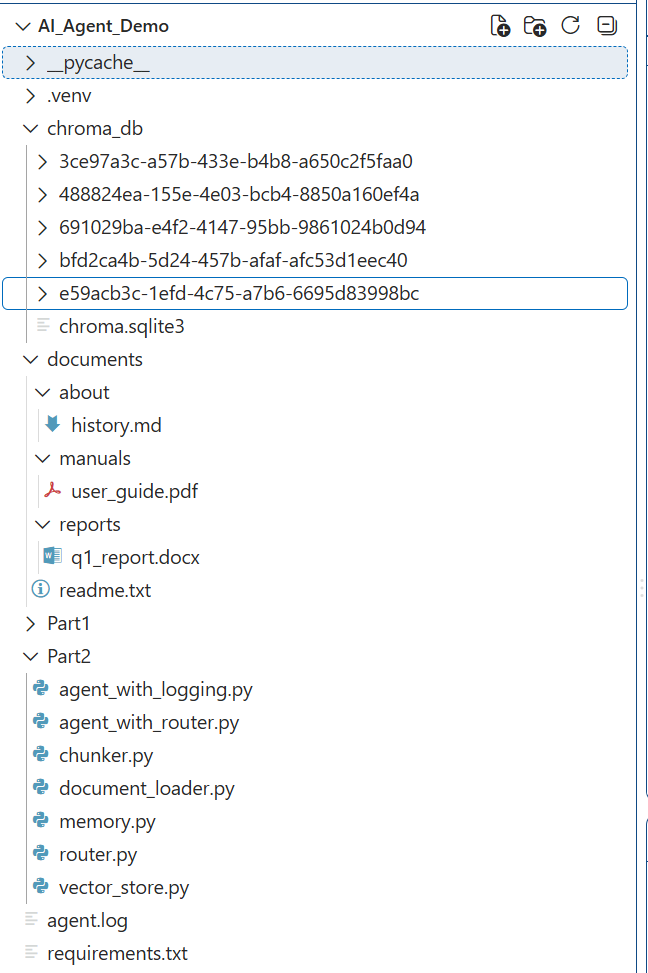


### Схема взаимодействия компонентов

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                           ПОЛЬЗОВАТЕЛЬ                                      │
│                                │                                             │
│                           Вопрос/команда                                    │
└────────────────────────────────┬────────────────────────────────────────────┘
                                 ▼
┌─────────────────────────────────────────────────────────────────────────────┐
│                         RAG-АГЕНТ (rag_agent.py)                           │
│                                                                             │
│  ┌──────────────────────────────────────────────────────────────────────┐  │
│  │  1. ВХОДНОЙ СЛОЙ:                                                    │  │
│  │  - Принимает вопрос / команды (/reset, /history, /exit)              │  │
│  │  - Получает историю из памяти                                        │  │
│  └──────────────────────────────────────────────────────────────────────┘  │
│                                   │                                         │
│                                   ▼                                         │
│  ┌──────────────────────────────────────────────────────────────────────┐  │
│  │  2. МАРШРУТИЗАТОР (router.py):                                     │  │
│  │  - Формирует промпт: вопрос + описание БЗ + история                 │  │
│  │  - Отправляет запрос в Ollama (qwen2.5:3b)                         │  │
│  │  - Получает JSON: {"action": "search"/"answer", "confidence": 0.92}│  │
│  └──────────────────────────────────────────────────────────────────────┘  │
│                         │                          │                        │
│             action="search"                         │ action="answer"      │
│                         ▼                          ▼                        │
│  ┌──────────────────────────────────────────────────────────────────────┐  │
│  │  3. ПОИСКОВЫЙ СЛОЙ (vector_store.py):                              │  │
│  │  - Вычисляет эмбеддинг вопроса (SentenceTransformer)                │  │
│  │  - Выполняет поиск в Chroma (коллекция "rag_docs")                  │  │
│  │  - Возвращает топ‑K чанков с метаданными и расстояниями            │  │
│  └──────────────────────────────────────────────────────────────────────┘  │
│                                   │                                         │
│                                   ▼                                         │
│  ┌──────────────────────────────────────────────────────────────────────┐  │
│  │  4. ГЕНЕРАТОР ОТВЕТА:                                               │  │
│  │  - Формирует промпт с контекстом (или без) + история                │  │
│  │  - Отправляет запрос в Ollama                                       │  │
│  │  - Получает финальный ответ                                         │  │
│  └──────────────────────────────────────────────────────────────────────┘  │
│                                   │                                         │
│                                   ▼                                         │
│  ┌──────────────────────────────────────────────────────────────────────┐  │
│  │  5. СЛОЙ ПАМЯТИ (memory.py):                                       │  │
│  │  - Сохраняет вопрос и ответ в историю (до 5 пар)                    │  │
│  │  - Предоставляет историю для следующих запросов                     │  │
│  └──────────────────────────────────────────────────────────────────────┘  │
│                                   │                                         │
│                                   ▼                                         │
│  ┌──────────────────────────────────────────────────────────────────────┐  │
│  │  6. СЛОЙ ЛОГИРОВАНИЯ (logging):                                    │  │
│  │  - Записывает все ключевые шаги в agent.log                        │  │
│  │  - Выводит краткую информацию в консоль                            │  │
│  └──────────────────────────────────────────────────────────────────────┘  │
└─────────────────────────────────────────────────────────────────────────────┘
                                 │
                                 ▼
┌─────────────────────────────────────────────────────────────────────────────┐
│                           ПОЛЬЗОВАТЕЛЬ                                      │
│                                                                             │
│                         Ответ агента                                        │
└─────────────────────────────────────────────────────────────────────────────┘
```

### Внешние зависимости

- **Ollama** (локальный сервер LLM) — обеспечивает выполнение языковой модели (qwen2.5:3b).
- **Chroma** (векторная БД) — хранит эмбеддинги и обеспечивает быстрый поиск.
- **Sentence Transformers** — вычисляет эмбеддинги текста (модель all-MiniLM-L6-v2).
- **pypdf, python-docx** — для извлечения текста из PDF и DOCX.

---

## Полный код `rag_agent.py`

Теперь, когда мы понимаем архитектуру, давайте посмотрим на итоговый код. Этот файл содержит все необходимые функции и классы, объединённые в единое целое.

```python
"""
rag_agent.py - Полноценный RAG-агент на локальной LLM
Лекция 6.2: Масштабирование RAG без фреймворков

Возможности:
- Загрузка документов из папки (TXT, PDF, DOCX, MD)
- Умное разбиение на чанки с перекрытием
- Векторное хранилище Chroma
- Интеллектуальная маршрутизация через LLM
- Краткосрочная память (история диалога)
- Логирование всех действий
"""

import os
import re
import json
import uuid
import logging
from datetime import datetime
from typing import List, Dict, Any, Tuple, Optional
from pathlib import Path

# Библиотеки для работы с документами
from pypdf import PdfReader
from docx import Document

# Векторная БД и эмбеддинги
import chromadb
from chromadb.api.types import EmbeddingFunction
from sentence_transformers import SentenceTransformer

# HTTP-запросы к Ollama
import requests

# ============================================================================
# ЧАСТЬ 1: ЗАГРУЗКА ДОКУМЕНТОВ (Тема 1)
# ============================================================================

def extract_text_from_txt(file_path: str) -> str:
    """Извлекает текст из .txt файла с попыткой нескольких кодировок."""
    encodings = ["utf-8", "cp1251", "latin-1"]
    for enc in encodings:
        try:
            with open(file_path, "r", encoding=enc) as f:
                return f.read()
        except UnicodeDecodeError:
            continue
    logging.warning(f"Не удалось прочитать {file_path} ни в одной из кодировок")
    return ""

def extract_text_from_pdf(file_path: str) -> str:
    """Извлекает текст из PDF с пометками страниц."""
    try:
        reader = PdfReader(file_path)
        text_parts = []
        for page_num, page in enumerate(reader.pages, start=1):
            page_text = page.extract_text()
            if page_text:
                text_parts.append(f"[Страница {page_num}]\n{page_text}")
        return "\n\n".join(text_parts)
    except Exception as e:
        logging.warning(f"Ошибка при чтении PDF {file_path}: {e}")
        return ""

def extract_text_from_docx(file_path: str) -> str:
    """Извлекает текст из .docx, объединяя все абзацы."""
    try:
        doc = Document(file_path)
        paragraphs = [p.text for p in doc.paragraphs if p.text.strip()]
        return "\n\n".join(paragraphs)
    except Exception as e:
        logging.warning(f"Ошибка при чтении DOCX {file_path}: {e}")
        return ""

def extract_text_from_md(file_path: str) -> str:
    """Читает .md файл как обычный текст."""
    return extract_text_from_txt(file_path)

EXTRACTORS = {
    ".txt": extract_text_from_txt,
    ".md": extract_text_from_md,
    ".pdf": extract_text_from_pdf,
    ".docx": extract_text_from_docx,
}

def load_documents_from_folder(folder_path: str = "documents") -> List[Dict[str, Any]]:
    """
    Загружает все поддерживаемые документы из папки.
    
    Возвращает:
        Список словарей: [{"text": "...", "metadata": {...}}, ...]
    """
    documents = []
    
    if not os.path.exists(folder_path):
        logging.error(f"Папка '{folder_path}' не найдена!")
        return documents
    
    for file_path in Path(folder_path).rglob("*"):
        if not file_path.is_file():
            continue
        
        ext = file_path.suffix.lower()
        if ext not in EXTRACTORS:
            continue
        
        text = EXTRACTORS[ext](str(file_path))
        if not text.strip():
            logging.warning(f"{file_path} не содержит текста")
            continue
        
        metadata = {
            "file_name": file_path.name,
            "file_path": str(file_path.relative_to(folder_path)),
            "modification_time": datetime.fromtimestamp(
                os.path.getmtime(file_path)
            ).isoformat(),
            "file_extension": ext,
        }
        
        if ext == ".pdf":
            try:
                reader = PdfReader(str(file_path))
                metadata["num_pages"] = len(reader.pages)
            except:
                pass
        
        documents.append({"text": text, "metadata": metadata})
        logging.info(f"✅ Загружен: {file_path.name} ({len(text)} символов)")
    
    return documents


# ============================================================================
# ЧАСТЬ 2: РАЗБИЕНИЕ НА ЧАНКИ (Тема 2)
# ============================================================================

def recursive_split(
    text: str,
    chunk_size: int = 500,
    chunk_overlap: int = 50,
    separators: List[str] = None
) -> List[str]:
    """
    Рекурсивно разбивает текст на чанки по естественным границам.
    Приоритет: абзацы → предложения → слова → символы.
    """
    if len(text) <= chunk_size:
        return [text]
    
    if separators is None:
        separators = ["\n\n", "\n", ". ", "! ", "? ", " ", ""]
    
    for sep in separators:
        if sep in text:
            parts = text.split(sep)
            chunks = []
            current_chunk = ""
            
            for part in parts:
                test_chunk = current_chunk + sep + part if current_chunk else part
                
                if len(test_chunk) <= chunk_size:
                    current_chunk = test_chunk
                else:
                    if current_chunk:
                        chunks.append(current_chunk)
                    
                    if chunk_overlap > 0 and len(current_chunk) > chunk_overlap:
                        current_chunk = current_chunk[-chunk_overlap:] + sep + part
                    else:
                        current_chunk = part
            
            if current_chunk:
                chunks.append(current_chunk)
            
            if all(len(chunk) <= chunk_size for chunk in chunks):
                return chunks
            
            final_chunks = []
            for chunk in chunks:
                if len(chunk) > chunk_size:
                    next_sep = separators[separators.index(sep) + 1:]
                    final_chunks.extend(
                        recursive_split(chunk, chunk_size, chunk_overlap, next_sep)
                    )
                else:
                    final_chunks.append(chunk)
            return final_chunks
    
    # Крайний случай: режем по символам
    chunks = []
    for i in range(0, len(text), chunk_size - chunk_overlap):
        chunk = text[i:i + chunk_size]
        if chunk:
            chunks.append(chunk)
    return chunks

def normalize_text(text: str) -> str:
    """Удаляет лишние пробелы и переносы."""
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def chunk_documents(
    documents: List[Dict[str, Any]],
    chunk_size: int = 500,
    chunk_overlap: int = 50
) -> List[Dict[str, Any]]:
    """
    Разбивает документы на чанки с сохранением метаданных.
    """
    all_chunks = []
    
    for doc in documents:
        text = doc["text"]
        metadata = doc["metadata"]
        
        raw_chunks = recursive_split(text, chunk_size, chunk_overlap)
        normalized_chunks = [normalize_text(ch) for ch in raw_chunks if ch.strip()]
        
        for i, chunk_text in enumerate(normalized_chunks):
            chunk_metadata = metadata.copy()
            chunk_metadata["chunk_index"] = i
            chunk_metadata["chunk_total"] = len(normalized_chunks)
            chunk_metadata["chunk_size"] = len(chunk_text)
            
            all_chunks.append({
                "text": chunk_text,
                "metadata": chunk_metadata
            })
        
        if normalized_chunks:
            total_size = sum(len(ch) for ch in normalized_chunks)
            avg_size = total_size // len(normalized_chunks)
            logging.info(f"✅ {metadata['file_name']}: {len(normalized_chunks)} чанков, "
                        f"средний размер {avg_size} символов")
    
    return all_chunks


# ============================================================================
# ЧАСТЬ 3: ВЕКТОРНАЯ БАЗА CHROMA (Тема 3)
# ============================================================================

class SentenceTransformerEmbedding(EmbeddingFunction):
    """Обёртка для SentenceTransformer, совместимая с Chroma 0.4.16+."""
    
    def __init__(self, model_name: str = "all-MiniLM-L6-v2"):
        self.model = SentenceTransformer(model_name)
    
    def __call__(self, input: List[str]) -> List[List[float]]:
        return self.model.encode(input).tolist()

def get_chroma_client(path: str = "./chroma_db"):
    """Создаёт персистентного клиента Chroma."""
    return chromadb.PersistentClient(path=path)

def create_collection(
    client,
    collection_name: str = "rag_docs",
    embedding_function=None
):
    """Создаёт коллекцию, удаляя старую при необходимости."""
    try:
        client.delete_collection(collection_name)
        logging.info(f"🗑️ Старая коллекция '{collection_name}' удалена")
    except:
        pass
    
    if embedding_function is None:
        embedding_function = SentenceTransformerEmbedding()
    
    collection = client.create_collection(
        name=collection_name,
        embedding_function=embedding_function
    )
    logging.info(f"✅ Коллекция '{collection_name}' создана")
    return collection

def add_chunks_to_collection(
    collection,
    chunked_documents: List[Dict[str, Any]],
    batch_size: int = 100
):
    """Добавляет чанки в коллекцию партиями."""
    total = len(chunked_documents)
    if total == 0:
        logging.warning("Нет чанков для добавления")
        return collection
    
    logging.info(f"📥 Добавление {total} чанков в коллекцию...")
    
    for i in range(0, total, batch_size):
        batch = chunked_documents[i:i+batch_size]
        texts = [item["text"] for item in batch]
        metadatas = [item["metadata"] for item in batch]
        ids = [str(uuid.uuid4()) for _ in range(len(batch))]
        
        collection.add(
            documents=texts,
            metadatas=metadatas,
            ids=ids
        )
        logging.debug(f"   Добавлено {min(i+batch_size, total)} из {total} чанков")
    
    logging.info(f"✅ Все {total} чанков добавлены в коллекцию")
    return collection

def search_chunks(
    collection,
    query: str,
    top_k: int = 5,
    include_distances: bool = True
) -> List[Dict[str, Any]]:
    """Выполняет семантический поиск по коллекции."""
    results = collection.query(
        query_texts=[query],
        n_results=top_k,
        include=["documents", "metadatas", "distances"] if include_distances else ["documents", "metadatas"]
    )
    
    documents = results["documents"][0] if results["documents"] else []
    metadatas = results["metadatas"][0] if results["metadatas"] else []
    distances = results["distances"][0] if results["distances"] and include_distances else []
    
    results_list = []
    for i, doc in enumerate(documents):
        result = {
            "text": doc,
            "metadata": metadatas[i] if i < len(metadatas) else {}
        }
        if include_distances and i < len(distances):
            result["distance"] = distances[i]
        results_list.append(result)
    
    return results_list


# ============================================================================
# ЧАСТЬ 4: ИНТЕЛЛИГЕНТНАЯ МАРШРУТИЗАЦИЯ (Тема 4)
# ============================================================================

def build_collection_description(
    chunked_documents: List[Dict[str, Any]],
    max_files: int = 10
) -> str:
    """Создаёт краткое описание базы знаний."""
    files_info = {}
    for chunk in chunked_documents:
        file_name = chunk["metadata"].get("file_name", "Unknown")
        if file_name not in files_info:
            files_info[file_name] = []
        files_info[file_name].append(chunk["text"])
    
    description_parts = []
    for i, (file_name, chunks) in enumerate(files_info.items()):
        if i >= max_files:
            description_parts.append(f"... и ещё {len(files_info) - max_files} файлов")
            break
        
        first_chunk = chunks[0] if chunks else ""
        preview = first_chunk[:200].replace('\n', ' ')
        description_parts.append(f"- {file_name}: {preview}...")
    
    return "\n".join(description_parts)


# ============================================================================
# ЧАСТЬ 5: ПАМЯТЬ (Тема 5)
# ============================================================================

class ConversationMemory:
    """Хранит историю диалога в пределах одной сессии."""
    
    def __init__(self, max_pairs: int = 5):
        self.messages: List[Dict[str, str]] = []
        self.max_pairs = max_pairs
    
    def add_user_message(self, content: str):
        self.messages.append({"role": "user", "content": content})
        self._trim()
    
    def add_assistant_message(self, content: str):
        self.messages.append({"role": "assistant", "content": content})
        self._trim()
    
    def get_history_text(self, max_pairs: int = None) -> str:
        if max_pairs is None:
            max_pairs = self.max_pairs
        
        limit = max_pairs * 2
        history = self.messages[-limit:] if len(self.messages) > limit else self.messages
        
        if not history:
            return ""
        
        lines = []
        for msg in history:
            role = "Пользователь" if msg["role"] == "user" else "Ассистент"
            lines.append(f"{role}: {msg['content']}")
        
        return "\n".join(lines)
    
    def clear(self):
        self.messages = []
        logging.info("🧹 История диалога очищена")
    
    def _trim(self):
        max_messages = self.max_pairs * 2
        if len(self.messages) > max_messages:
            self.messages = self.messages[-max_messages:]


# ============================================================================
# ЧАСТЬ 6: ЛОГИРОВАНИЕ (Тема 6)
# ============================================================================

def setup_logging(log_file: str = "agent.log", log_level: int = logging.INFO):
    """Настраивает логирование в файл и консоль."""
    log_format = "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
    date_format = "%Y-%m-%d %H:%M:%S"
    
    logger = logging.getLogger()
    logger.setLevel(log_level)
    logger.handlers.clear()
    
    file_handler = logging.FileHandler(log_file, encoding="utf-8")
    file_handler.setLevel(log_level)
    file_handler.setFormatter(logging.Formatter(log_format, date_format))
    
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)
    console_handler.setFormatter(logging.Formatter("%(levelname)s - %(message)s"))
    
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)
    
    return logger


# ============================================================================
# ГЛАВНЫЙ КЛАСС RAG-АГЕНТА
# ============================================================================

class RAGAgent:
    """
    Полноценный RAG-агент с загрузкой документов, векторной БД,
    интеллектуальной маршрутизацией, памятью и логированием.
    """
    
    def __init__(
        self,
        documents_folder: str = "documents",
        chunk_size: int = 500,
        chunk_overlap: int = 50,
        llm_model: str = "qwen2.5:3b",
        max_history_pairs: int = 5,
        log_file: str = "agent.log",
        log_level: int = logging.INFO
    ):
        """
        Инициализация агента.
        
        Аргументы:
            documents_folder: путь к папке с документами
            chunk_size: размер чанка в символах
            chunk_overlap: перекрытие между чанками
            llm_model: имя модели в Ollama
            max_history_pairs: максимум пар сообщений в истории
            log_file: путь к файлу логов
            log_level: уровень логирования
        """
        # Настройка логирования
        self.logger = setup_logging(log_file, log_level)
        self.logger.info("=" * 60)
        self.logger.info("🚀 ИНИЦИАЛИЗАЦИЯ RAG-АГЕНТА")
        self.logger.info("=" * 60)
        
        # Параметры
        self.llm_model = llm_model
        self.chunk_size = chunk_size
        self.chunk_overlap = chunk_overlap
        
        # Память
        self.memory = ConversationMemory(max_pairs=max_history_pairs)
        
        # Векторная БД
        self.collection = None
        self.description = None
        
        # --- Шаг 1: Загрузка документов ---
        self.logger.info("1. Загрузка документов...")
        docs = load_documents_from_folder(documents_folder)
        self.logger.info(f"   Загружено документов: {len(docs)}")
        
        if not docs:
            self.logger.warning("⚠️ Документы не найдены! Агент будет работать без базы знаний.")
            return
        
        # --- Шаг 2: Разбиение на чанки ---
        self.logger.info("2. Разбиение на чанки...")
        chunked_docs = chunk_documents(docs, chunk_size, chunk_overlap)
        self.logger.info(f"   Создано чанков: {len(chunked_docs)}")
        
        # --- Шаг 3: Описание базы знаний для маршрутизатора ---
        self.description = build_collection_description(chunked_docs)
        self.logger.debug(f"Описание БЗ: {self.description[:200]}...")
        
        # --- Шаг 4: Создание векторной БД ---
        self.logger.info("3. Создание векторной базы...")
        client = get_chroma_client()
        embedding_function = SentenceTransformerEmbedding()
        self.collection = create_collection(client, "rag_docs", embedding_function)
        
        # --- Шаг 5: Индексация чанков ---
        add_chunks_to_collection(self.collection, chunked_docs)
        
        self.logger.info("✅ Агент готов к работе!\n")
    
    def answer(self, question: str, top_k: int = 3) -> str:
        """
        Обрабатывает вопрос пользователя.
        
        Аргументы:
            question: вопрос пользователя
            top_k: количество чанков для поиска
        
        Возвращает:
            Ответ агента (строка)
        """
        self.logger.info("=" * 60)
        self.logger.info(f"🔍 Вопрос: {question}")
        self.logger.info("=" * 60)
        
        # Проверка: есть ли база знаний
        if self.collection is None:
            self.logger.warning("База знаний не инициализирована, отвечаю из общих знаний")
            answer = self._generate_answer(question)
            self._save_to_memory(question, answer)
            return answer
        
        # Получаем историю для маршрутизатора
        history_text = self.memory.get_history_text(max_pairs=3)
        self.logger.debug(f"История: {history_text[:100] if history_text else 'пусто'}...")
        
        # --- Шаг 1: Маршрутизация ---
        action, confidence = self._router(question, history_text)
        self.logger.info(f"🎯 Маршрутизация: {action} (уверенность: {confidence:.2f})")
        
        # --- Шаг 2: Поиск или генерация ---
        if action == "search":
            self.logger.info("🔍 Поиск в Chroma...")
            results = search_chunks(self.collection, question, top_k=top_k)
            
            if not results:
                self.logger.warning("⚠️ Результатов не найдено")
                answer = self._generate_answer(question)
            else:
                self.logger.info(f"📚 Найдено {len(results)} чанков")
                for i, r in enumerate(results, 1):
                    self.logger.debug(
                        f"  Чанк {i}: расстояние={r.get('distance', 'N/A'):.4f}, "
                        f"источник={r['metadata'].get('file_name', 'Unknown')}"
                    )
                
                context = "\n\n---\n\n".join([r["text"] for r in results])
                answer = self._generate_answer_with_context(question, context)
        else:
            self.logger.info("💡 Отвечаю из общих знаний")
            answer = self._generate_answer(question)
        
        # --- Шаг 3: Логирование ответа ---
        preview = answer[:200] + ("..." if len(answer) > 200 else "")
        self.logger.info(f"🤖 Ответ: {preview}")
        self.logger.info("-" * 60)
        
        # --- Шаг 4: Сохранение в память ---
        self._save_to_memory(question, answer)
        
        return answer
    
    def _router(self, question: str, history_text: str, temperature: float = 0.0) -> Tuple[str, float]:
        """Интеллектуальный маршрутизатор с учётом истории."""
        if self.description is None:
            self.logger.warning("Нет описания БЗ, маршрутизация по умолчанию: search")
            return "search", 0.5
        
        prompt = f"""
Ты — интеллектуальный маршрутизатор запросов в RAG-системе.

База знаний содержит:
{self.description}

ИСТОРИЯ ДИАЛОГА:
{history_text if history_text else "Нет предыдущих сообщений"}

Правила:
- Если вопрос требует фактов из документов → "search"
- Если вопрос общий (философия, математика, погода) → "answer"
- Если вопрос уточняет предыдущий, и тот требовал поиска → "search"

Верни JSON: {{"action": "search" или "answer", "confidence": число 0-1}}

ВОПРОС: {question}

JSON:
"""
        try:
            response = requests.post(
                "http://localhost:11434/api/generate",
                json={
                    "model": self.llm_model,
                    "prompt": prompt,
                    "stream": False,
                    "options": {"temperature": temperature}
                },
                timeout=30
            )
            response.raise_for_status()
            raw_text = response.json().get("response", "")
        except Exception as e:
            self.logger.error(f"Ошибка маршрутизации: {e}")
            return "search", 0.5
        
        try:
            start = raw_text.find('{')
            end = raw_text.rfind('}') + 1
            if start == -1 or end == 0:
                raise ValueError("JSON не найден")
            
            data = json.loads(raw_text[start:end])
            action = data.get("action", "search")
            confidence = data.get("confidence", 0.5)
            
            if action not in ["search", "answer"]:
                action = "search"
            confidence = max(0.0, min(1.0, float(confidence)))
            
            self.logger.debug(f"Маршрутизатор: {json.dumps(data)}")
            return action, confidence
            
        except Exception as e:
            self.logger.warning(f"Ошибка парсинга JSON: {e}")
            return "search", 0.5
    
    def _generate_answer(self, question: str) -> str:
        """Генерирует ответ из общих знаний с учётом истории."""
        history_text = self.memory.get_history_text(max_pairs=3)
        
        prompt = f"""
Ответь на вопрос, используя свои общие знания. Будь кратким.

ИСТОРИЯ:
{history_text if history_text else "Нет предыдущих сообщений"}

ВОПРОС: {question}

ОТВЕТ:
"""
        return self._call_llm(prompt)
    
    def _generate_answer_with_context(self, question: str, context: str) -> str:
        """Генерирует ответ только на основе контекста."""
        history_text = self.memory.get_history_text(max_pairs=3)
        
        prompt = f"""
Отвечай ТОЛЬКО на основе КОНТЕКСТА. Если ответа нет — скажи: "В документах нет информации".

ИСТОРИЯ:
{history_text if history_text else "Нет предыдущих сообщений"}

КОНТЕКСТ:
{context}

ВОПРОС: {question}

ОТВЕТ (только из контекста):
"""
        return self._call_llm(prompt)
    
    def _call_llm(self, prompt: str) -> str:
        """Вызывает LLM через Ollama."""
        try:
            self.logger.debug("Отправка запроса к Ollama...")
            response = requests.post(
                "http://localhost:11434/api/generate",
                json={
                    "model": self.llm_model,
                    "prompt": prompt,
                    "stream": False
                },
                timeout=60
            )
            response.raise_for_status()
            answer = response.json().get("response", "Ошибка генерации")
            self.logger.debug(f"Получен ответ ({len(answer)} символов)")
            return answer
        except requests.exceptions.Timeout:
            self.logger.error("Таймаут Ollama")
            return "Извините, запрос занял слишком много времени."
        except requests.exceptions.ConnectionError:
            self.logger.error("Ошибка соединения с Ollama")
            return "Извините, не могу подключиться к языковой модели."
        except Exception as e:
            self.logger.error(f"Ошибка LLM: {e}")
            return "Извините, произошла ошибка при генерации ответа."
    
    def _save_to_memory(self, question: str, answer: str):
        """Сохраняет диалог в память."""
        self.memory.add_user_message(question)
        self.memory.add_assistant_message(answer)
    
    def clear_memory(self):
        """Очищает историю диалога."""
        self.memory.clear()
    
    def get_history(self) -> str:
        """Возвращает историю диалога."""
        return self.memory.get_history_text()


# ============================================================================
# ТОЧКА ВХОДА: ДЕМОНСТРАЦИОННЫЙ ЦИКЛ
# ============================================================================

def main():
    """Основной цикл взаимодействия с агентом."""
    print("=" * 60)
    print("🤖 RAG-АГЕНТ НА ЛОКАЛЬНОЙ LLM")
    print("=" * 60)
    print("\n📂 Загрузка документов из папки 'my_docs'...")
    
    # Создаём агента
    agent = RAGAgent(
        documents_folder="my_docs",  # можно изменить на "documents"
        chunk_size=500,
        chunk_overlap=50,
        llm_model="qwen2.5:3b",
        max_history_pairs=5,
        log_file="agent.log",
        log_level=logging.INFO
    )
    
    print("\n" + "=" * 60)
    print("ИНТЕРАКТИВНЫЙ ДИАЛОГ")
    print("=" * 60)
    print("Команды:")
    print("  /reset   - очистить историю")
    print("  /history - показать историю")
    print("  /exit    - выйти")
    print("=" * 60 + "\n")
    
    while True:
        try:
            user_input = input("Вы: ").strip()
            
            if not user_input:
                continue
            
            if user_input.lower() == "/exit":
                print("👋 До свидания!")
                break
            
            if user_input.lower() == "/reset":
                agent.clear_memory()
                print("💬 История очищена.")
                continue
            
            if user_input.lower() == "/history":
                print("\n📜 История диалога:")
                print(agent.get_history() or "(пусто)")
                continue
            
            # Обрабатываем вопрос
            answer = agent.answer(user_input)
            print(f"\n🤖 Агент: {answer}\n")
            print("-" * 60)
            
        except KeyboardInterrupt:
            print("\n👋 До свидания!")
            break
        except Exception as e:
            print(f"⚠️ Ошибка: {e}")

if __name__ == "__main__":
    main()
```

---

### Как использовать

1. **Создайте папку `my_docs/`** (или `documents/`) и поместите туда ваши файлы (TXT, PDF, DOCX, MD).

2. **Установите зависимости** (если ещё не установлены):
   ```bash
   pip install pypdf python-docx chromadb sentence-transformers requests
   ```

3. **Убедитесь, что Ollama запущен** и модель `qwen2.5:3b` загружена:
   ```bash
   ollama pull qwen2.5:3b
   ollama serve
   ```

4. **Запустите агента**:
   ```bash
   python rag_agent.py
   ```

5. **Общайтесь!** Задавайте вопросы, используйте команды `/reset`, `/history`, `/exit`.

---

## 🎯 Заключение Лекции 6.2

Поздравляю! Мы прошли огромный путь. Давайте вспомним, с чего начинали и что получили в итоге.

### 📍 Путь, который мы прошли

**Лекция 6.1** — мы создали **игрушечного RAG-агента**:
- Документы были зашиты в коде.
- Поиск был ручной (cosine_similarity).
- Маршрутизация — по ключевым словам.

**Лекция 6.2** — мы превратили его в **промышленную систему**:

| Тема | Скрипт | Что сделали |
|------|--------|-------------|
| 1 | `document_loader.py` | Научились загружать реальные документы (TXT, PDF, DOCX, MD) с метаданными |
| 2 | `chunker.py` | Реализовали умное разбиение на чанки с перекрытием |
| 3 | `vector_store.py` | Подключили Chroma для быстрого поиска по миллионам документов |
| 4 | `router.py` | Заменили ключевые слова на интеллектуальную маршрутизацию через LLM |
| 5 | `memory.py` | Добавили память — агент помнит диалог |
| 6 | `agent_with_logging.py` | Внедрили логирование для отладки и анализа |

**Итог** — мы собрали всё в одном файле `rag_agent.py`:
- Полноценный класс `RAGAgent`
- Все компоненты работают вместе
- Готов к использованию в реальных проектах

### 🔑 Что вы теперь знаете и умеете

1. **Понимаете архитектуру RAG** — знаете, из каких компонентов состоит система и как они взаимодействуют.

2. **Умеете работать с локальными LLM** — через Ollama, без облачных API.

3. **Владеете инструментами**:
   - SentenceTransformers для эмбеддингов
   - Chroma для векторного поиска
   - pypdf, python-docx для работы с документами
   - logging для мониторинга

4. **Понимаете подводные камни**:
   - Важность перекрытия чанков
   - Обработку ошибок парсинга
   - Совместимость версий Chroma
   - Ограничения контекстного окна

5. **Можете развивать систему**:
   - Добавлять новые форматы документов
   - Менять модель эмбеддингов
   - Настраивать маршрутизацию
   - Улучшать качество ответов

### 💡 Что дальше?

В следующей лекции мы перейдём к **фреймворкам** — **LangChain** и **LangGraph**. Они автоматизируют многие задачи, которые мы сейчас решали вручную:
- Управление памятью
- Построение цепочек
- Создание сложных агентов с несколькими инструментами

**Но теперь у вас есть суперсила**: вы знаете, **как это работает под капотом**. Вы сможете:
- Отлаживать фреймворки, когда они ведут себя неожиданно.
- Оптимизировать их под свои задачи.
- Не зависеть от чёрного ящика.

### 🚀 Призыв к действию

1. **Поэкспериментируйте с кодом**:
   - Измените `chunk_size` и посмотрите, как меняется качество.
   - Добавьте новый формат файлов (например, HTML).
   - Попробуйте другую модель эмбеддингов.
   - Настройте промпты маршрутизатора и генератора.

2. **Создайте свой проект**:
   - Личный помощник по вашим документам.
   - Чат-бот для поддержки пользователей.
   - Инструмент для исследования научных статей.
   - Корпоративная база знаний.

3. **Делитесь результатами**:
   - Показывайте проект друзьям и коллегам.
   - Пишите в блог о своём опыте.
   - Участвуйте в open-source.

**Помните**: вы построили систему, за которую в коммерческих проектах платят тысячи долларов. И вы сделали это бесплатно, локально и с пониманием каждого компонента.

**Вы — инженер RAG-систем. Гордитесь этим!** 🎉



---

Спасибо, что прошли этот путь вместе с нами! В следующей лекции мы рассмотрим **LangChain** и **LangGraph** — мощные фреймворки, которые автоматизируют многие из тех задач, которые мы сейчас решали вручную. Оставайтесь с нами! 🚀



## Домашнее задание к лекции 6.2

В этой лекции мы превратили игрушечного агента в полноценную RAG-систему без фреймворков. Ваша задача — закрепить этот материал на практике: поэкспериментировать с параметрами, сравнить подходы, проанализировать результаты и сделать выводы.

> **Важно:** Все задания выполняются с использованием **вашего собственного набора документов**. Вы можете использовать тестовые файлы из лекции или создать свои. Если вы создаёте свои документы, убедитесь, что они разнообразны по темам и структуре (короткие и длинные тексты, разные форматы).

---

### Обязательная часть (5 баллов)

#### 1. Анализ влияния размера чанка (2 балла)

В лекции мы использовали `chunk_size=500` и `chunk_overlap=50`. Ваша задача — провести эксперимент и выяснить, как размер чанка влияет на качество ответов.

**Что сделать:**

1. Модифицируйте `rag_agent.py` так, чтобы можно было легко менять `chunk_size` и `chunk_overlap` через параметры командной строки или аргументы при создании агента.

2. Запустите агента с тремя разными конфигурациями:
   - **Мелкие чанки:** `chunk_size=200`, `chunk_overlap=20`
   - **Средние чанки:** `chunk_size=500`, `chunk_overlap=50` (как в лекции)
   - **Крупные чанки:** `chunk_size=1000`, `chunk_overlap=100`

3. Для каждой конфигурации задайте **один и тот же набор из 5 вопросов** к вашим документам. Вопросы должны быть разного типа:
   - Фактический вопрос (требует точной цитаты)
   - Обобщающий вопрос (требует синтеза информации из нескольких мест)
   - Уточняющий вопрос (зависит от предыдущего диалога)

4. **Зафиксируйте в отчёте:**
   - Количество чанков, созданных из ваших документов для каждой конфигурации.
   - Примеры найденных чанков для одного вопроса (покажите, что ищет ретривер).
   - Ответы агента для каждого вопроса и каждой конфигурации.

5. **Сделайте вывод:**
   - Какая конфигурация дала наилучшее качество ответов?
   - Какие проблемы возникли при слишком мелких или слишком крупных чанках?
   - Какой размер чанка вы бы рекомендовали для вашего типа документов и почему?

---

#### 2. Сравнение маршрутизации: ключевые слова vs LLM (3 балла)

В лекции мы заменили примитивную проверку ключевых слов на интеллектуальную маршрутизацию через LLM. Ваша задача — сравнить эти два подхода на реальных данных.

**Что сделать:**

1. **Реализуйте маршрутизацию по ключевым словам** (как в Лекции 6.1) в качестве альтернативы. Добавьте в агента возможность переключения между режимами (`router_mode="keywords"` или `router_mode="llm"`).

2. **Создайте список из 20 вопросов** разных типов:
   - 10 вопросов, на которые **есть ответ** в ваших документах (например, "Что такое ProjectFlow?").
   - 10 вопросов, на которые **нет ответа** в документах (например, "Как работает гравитация?" или "Какая погода завтра?").

3. **Запустите агента в обоих режимах** и для каждого вопроса зафиксируйте:
   - Решение маршрутизатора (`search` или `answer`).
   - Правильность решения (правильно/неправильно).
   - Для LLM-маршрутизатора — значение `confidence`.

4. **Постройте таблицу сравнения** (в отчёте) со следующими колонками:
   - Вопрос
   - Ожидаемое действие (search/answer)
   - Решение ключевых слов (search/answer) → правильно/неправильно
   - Решение LLM (search/answer, confidence) → правильно/неправильно

5. **Рассчитайте точность** каждого метода:
   - Процент правильных решений для вопросов из документов.
   - Процент правильных решений для общих вопросов.
   - Общий процент правильных решений.

6. **Сделайте вывод:**
   - Насколько LLM-маршрутизатор превзошёл ключевые слова?
   - Были ли случаи, когда ключевые слова сработали лучше?
   - Какие типы вопросов оказались самыми сложными для маршрутизатора?
   - Предложите, как можно улучшить промпт маршрутизатора.

---

### Дополнительная часть (эксперименты — выполните минимум 3 из 6, каждый до 2 баллов)

#### 3. Сравнение моделей эмбеддингов (2 балла)

В лекции мы использовали `all-MiniLM-L6-v2`. Попробуйте заменить её на другую модель и сравнить результаты.

**Что сделать:**

1. Выберите **две альтернативные модели** эмбеддингов из библиотеки `sentence-transformers`:
   - `paraphrase-multilingual-MiniLM-L12-v2` (мультиязычная, лёгкая)
   - `intfloat/multilingual-e5-small` (современная, компактная)
   - `sentence-transformers/paraphrase-multilingual-mpnet-base-v2` (качественная, тяжёлая)
   - `all-mpnet-base-v2` (англоязычная, качественная)

2. Для **каждой модели**:
   - Пересоздайте векторную базу (переиндексируйте документы).
   - Задайте **один и тот же набор из 3 вопросов** к вашим документам.
   - Зафиксируйте:
     - Время загрузки модели и индексации.
     - Топ‑3 найденных чанка для каждого вопроса (с их расстояниями).
     - Ответ агента.

3. **В отчёте**:
   - Сравните качество поиска (насколько релевантны найденные чанки).
   - Сравните время работы.
   - Сделайте вывод: какая модель лучше всего подходит для ваших данных и почему.

---

#### 4. Оптимизация параметров маршрутизации (2 балла)

Маршрутизация через LLM чувствительна к промпту и параметрам генерации. Ваша задача — найти оптимальную конфигурацию.

**Что сделать:**

1. Измените промпт маршрутизатора (`_router` в `rag_agent.py`):
   - Добавьте больше примеров правильных и неправильных решений (few-shot).
   - Добавьте чёткие инструкции для сложных случаев (например, уточняющие вопросы).
   - Сделайте промпт более строгим или более гибким.

2. Поэкспериментируйте с параметрами LLM для маршрутизатора:
   - `temperature`: 0.0, 0.3, 0.7
   - `top_p`: 0.1, 0.5, 0.9
   - `num_predict`: 64, 128, 256

3. Для каждой комбинации (выберите 3–5) **протестируйте на 10 вопросах** (5 из документов, 5 общих) и зафиксируйте точность.

4. **В отчёте**:
   - Опишите, какие изменения вы внесли.
   - Приведите таблицу точности для каждой конфигурации.
   - Сделайте вывод: какая конфигурация дала наилучший результат и почему.
   - Какую роль играет `temperature` в маршрутизации?

---

#### 5. Влияние памяти на качество ответов (2 балла)

Память (история диалога) помогает агенту понимать контекст. Ваша задача — оценить, насколько она важна.

**Что сделать:**

1. Создайте **диалог из 5 вопросов**, где каждый следующий вопрос является уточнением предыдущего. Например:
   - Вопрос 1: "Что такое ProjectFlow?"
   - Вопрос 2: "Какие у него тарифы?" (без памяти агент не поймёт, о чём речь)
   - Вопрос 3: "А есть ли бесплатный тариф?" (уточнение)
   - Вопрос 4: "Сколько пользователей он поддерживает?" (без памяти — не понятно)
   - Вопрос 5: "А как мне зарегистрироваться?" (без памяти — непонятно, о каком сервисе речь)

2. Запустите агента **с памятью** (как в лекции) и **без памяти** (отключив подстановку истории в промпт). Для каждой версии запишите ответы на все 5 вопросов.

3. **В отчёте**:
   - Приведите полный диалог для обоих случаев.
   - Отметьте, в каких вопросах разница особенно заметна.
   - Проанализируйте, как память помогает (или мешает) маршрутизатору и генерации.
   - Есть ли случаи, когда память приводит к ошибкам (например, агент "зацикливается" на предыдущей теме)?

---

#### 6. Анализ логов (2 балла)

Логирование — мощный инструмент для отладки. Ваша задача — проанализировать логи агента и найти закономерности.

**Что сделать:**

1. Запустите агента в режиме `logging.DEBUG` и задайте **10–15 вопросов** разных типов.

2. Изучите файл `agent.log` и найдите:
   - Примеры успешной и неуспешной маршрутизации.
   - Примеры, когда ретривер нашёл нерелевантные чанки (большие расстояния).
   - Примеры, когда модель сгенерировала хороший и плохой ответ.

3. **В отчёте**:
   - Приведите 3–4 фрагмента логов с комментариями, что в них важно.
   - На основе логов предложите **конкретные улучшения** системы:
     - Как улучшить промпт генератора?
     - Как изменить параметры поиска (top_k, порог расстояния)?
     - Как улучшить маршрутизатор?
   - Оцените, насколько логирование помогло вам понять поведение системы.

---

#### 7. Добавление нового формата документов (2 балла)

В лекции мы поддерживали TXT, PDF, DOCX, MD. Добавьте поддержку **ещё одного формата** (например, HTML, JSON, CSV, PPTX).

**Что сделать:**

1. Выберите формат, который вам интересен (например, HTML-страницы).

2. Напишите функцию извлечения текста для этого формата (используйте подходящую библиотеку, например, `beautifulsoup4` для HTML).

3. Добавьте функцию в словарь `EXTRACTORS` в `rag_agent.py`.

4. Протестируйте на реальных файлах вашего формата.

5. **В отчёте**:
   - Опишите, какую библиотеку вы использовали и почему.
   - Приведите пример загруженного документа и извлечённого текста.
   - Задайте 2–3 вопроса по этому документу и покажите ответы агента.

---

### Формат сдачи

1. **Код** всех модификаций (`rag_agent.py` и любые дополнительные скрипты) сохраните в отдельной папке (или используйте Git).

2. **Отчёт** в формате `.md` или `.pdf`, содержащий:
   - Для **каждого выполненного задания**:
     - Краткое описание, что сделано.
     - Ключевые результаты (таблицы, скриншоты, примеры ответов).
     - Ваши выводы и обоснования.
   - Для обязательной части — чёткие сравнения и численные оценки.
   - Для дополнительной части — достаточные детали, чтобы можно было воспроизвести эксперимент.

3. **Лог-файлы** (по желанию) — если вы делали задание 6, приложите фрагменты логов.

---

### Критерии оценки

| Раздел | Максимум баллов |
|--------|----------------|
| **Обязательная часть** | 5 |
| Задание 1 (анализ чанков) | 2 |
| Задание 2 (сравнение маршрутизации) | 3 |
| **Дополнительная часть** (каждый пункт) | до 2 (максимум +10) |
| За каждый выполненный пункт: 1 балл за реализацию, 1 балл за анализ/выводы | |
| **Итого** | 15 |

**Штрафы:**
- Отсутствие отчёта или невнятные выводы — минус 2 балла.
- Код без комментариев и с плохим форматированием — минус 1 балл.
- Использование готовых ответов без собственного анализа — минус 2 балла.

---

### Рекомендации

- Начинайте с обязательной части — она даёт базовое понимание.
- Для экспериментов используйте **те же вопросы**, чтобы результаты были сопоставимы.
- Не бойтесь модифицировать код и пробовать разные параметры — это и есть главная цель ДЗ.
- Если возникают ошибки, смотрите в логи — они помогут понять, что пошло не так.
- Обязательно фиксируйте все результаты в отчёте — это поможет вам систематизировать знания.
